# Getting the book value and price to earnings ratio

In [ ]:
# Obtaining the PE ratio and book to market value data
!pip install wrds
import wrds

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import wrds
import pandas as pd

db = wrds.Connection()

periods = {
    "1960_1980": (1960, 1980),
    "1981_2000": (1981, 2000),
    "2001_2024": (2001, 2024),
}

for name, (start, end) in periods.items():
    query = f"""
    WITH sp500 AS (
        /* CRSP S&P 500 membership: columns permno, start, ending */
        SELECT DISTINCT
               permno,
               start,
               COALESCE(ending, DATE '9999-12-31') AS ending
        FROM crsp.msp500list
        /* Universe: members sometime during the specified period */
        WHERE start <= DATE '{end}-12-31'
          AND COALESCE(ending, DATE '9999-12-31') >= DATE '{start}-01-01'
    ),
    ccm AS (
        /* CRSP–Compustat link (primary/common links only) */
        SELECT DISTINCT
               gvkey,
               lpermno AS permno,
               COALESCE(linkdt,    DATE '1900-01-01')  AS linkdt,
               COALESCE(linkenddt, DATE '9999-12-31')  AS linkenddt
        FROM crsp.ccmxpf_linktable
        WHERE linktype IN ('LU','LC') AND linkprim IN ('P','C')
    ),
    univ AS (
        /* Keep rows where SP500 membership window overlaps CCM link window */
        SELECT
            s.permno,
            c.gvkey,
            GREATEST(s.start,  c.linkdt)    AS startdt,
            LEAST(s.ending, c.linkenddt)    AS enddt
        FROM sp500 s
        JOIN ccm   c
          ON s.permno = c.permno
        WHERE GREATEST(s.start, c.linkdt) <= LEAST(s.ending, c.linkenddt)
    )
    SELECT
        f.gvkey,
        comp.conm AS company_name,
        u.permno,
        f.datadate,
        EXTRACT(YEAR FROM f.datadate) AS year,

        /* ---------- Robust P/E computation (no pe1 needed) ---------- */
        /* EPS fallback: epspx → epsfi → ni/csho */
        CASE
          WHEN NULLIF(
                 COALESCE(f.epspx, f.epsfi, (f.ni / NULLIF(f.csho, 0))), 0
               ) IS NOT NULL
          THEN f.prcc_f / NULLIF(
                 COALESCE(f.epspx, f.epsfi, (f.ni / NULLIF(f.csho, 0))), 0
               )
          ELSE NULL
        END AS pe_ratio,

        /* ---------- Robust BVPS: (equity proxy)/csho with fallbacks ---------- */
        CASE
          WHEN NULLIF(f.csho, 0) IS NOT NULL THEN
            COALESCE(
              f.ceq,                        /* common equity */
              (f.seq - f.pstk),             /* total equity - preferred */
              (f.at - f.lt - f.pstk)        /* assets - liabilities - preferred */
            ) / NULLIF(f.csho, 0)
          ELSE NULL
        END AS book_value_per_share

    FROM comp.funda f
    JOIN univ u
      ON f.gvkey = u.gvkey
     AND f.datadate BETWEEN u.startdt AND u.enddt
    JOIN comp.company comp
      ON f.gvkey = comp.gvkey
    WHERE f.indfmt = 'INDL'
      AND f.datafmt = 'STD'
      AND f.popsrc = 'D'
      AND f.consol = 'C'
      AND f.datadate BETWEEN DATE '{start}-01-01' AND DATE '{end}-12-31'
    ORDER BY f.gvkey, f.datadate;
    """
    df = db.raw_sql(query)
    out_path = f"/content/drive/MyDrive/Senior Year Projects/Thesis/Data/sp500_pe_bvps_{name}.csv"
    df.to_csv(out_path, index=False)
    print(f"Saved {out_path}  (rows: {len(df)})")

Enter your WRDS username [root]:rosalia2026
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Saved /content/drive/MyDrive/Senior Year Projects/Thesis/Data/sp500_pe_bvps_1960_1980.csv  (rows: 9509)
Saved /content/drive/MyDrive/Senior Year Projects/Thesis/Data/sp500_pe_bvps_1981_2000.csv  (rows: 9896)
Saved /content/drive/MyDrive/Senior Year Projects/Thesis/Data/sp500_pe_bvps_2001_2024.csv  (rows: 11963)


In [ ]:
# Let's load the data in google drive the training set data
import pandas as pd
filepath = '/content/drive/MyDrive/Senior Year Projects/Thesis/Data/sp500_pe_bvps_1960_1980.csv'
df = pd.read_csv(filepath)
df.head(50)




,gvkey,company_name,permno,datadate,year,pe_ratio,book_value_per_share
0,1010,ACF INDUSTRIES INC,10006,1960-04-30,1960.0,NaN,NaN
1,1010,ACF INDUSTRIES INC,10006,1961-04-30,1961.0,NaN,NaN
2,1010,ACF INDUSTRIES INC,10006,1962-04-30,1962.0,17.073619,NaN
3,1010,ACF INDUSTRIES INC,10006,1963-04-30,1963.0,16.570366,88.433586
4,1010,ACF INDUSTRIES INC,10006,1964-04-30,1964.0,15.333323,46.976263
5,1010,ACF INDUSTRIES INC,10006,1965-04-30,1965.0,12.247307,51.615359
6,1010,ACF INDUSTRIES INC,10006,1966-04-30,1966.0,11.342041,28.061476
7,1010,ACF INDUSTRIES INC,10006,1967-04-30,1967.0,9.844052,30.562804
8,1010,ACF INDUSTRIES INC,10006,1968-04-30,1968.0,12.631573,31.894578
9,1010,ACF INDUSTRIES INC,10006,1969-04-30,1969.0,13.034662,33.320511


# Correcting data + Company Alignment

In [ ]:
import wrds
import pandas as pd

db = wrds.Connection()

periods = {
    "1960_1980": (1960, 1980),
    "1981_2000": (1981, 2000),
    "2001_2024": (2001, 2024),
}

for name, (start, end) in periods.items():
    print(f"Running query for {name} ({start}-{end})...")

    query = f"""
    /* --------------------------------------------------------------
       Continuous S&P500 members: entered by 1960 and stayed through 2024
       -------------------------------------------------------------- */
    WITH base_members AS (
        SELECT permno
        FROM crsp.msp500list
        GROUP BY permno
        HAVING MIN(start) <= DATE '1960-01-01'
           AND MAX(COALESCE(ending, DATE '9999-12-31')) >= DATE '2024-12-31'
    ),
    sp500 AS (
        SELECT DISTINCT
               permno,
               start,
               COALESCE(ending, DATE '9999-12-31') AS ending
        FROM crsp.msp500list
        WHERE permno IN (SELECT permno FROM base_members)
          AND start <= DATE '{end}-12-31'
          AND COALESCE(ending, DATE '9999-12-31') >= DATE '{start}-01-01'
    ),
    ccm AS (
        SELECT DISTINCT
               gvkey,
               lpermno AS permno,
               COALESCE(linkdt,    DATE '1900-01-01') AS linkdt,
               COALESCE(linkenddt, DATE '9999-12-31') AS linkenddt
        FROM crsp.ccmxpf_linktable
        WHERE linktype IN ('LU','LC','LN') AND linkprim IN ('P','C')
    ),
    univ AS (
        SELECT
            s.permno,
            c.gvkey,
            GREATEST(s.start,  c.linkdt)    AS startdt,
            LEAST(s.ending, c.linkenddt)    AS enddt
        FROM sp500 s
        JOIN ccm   c ON s.permno = c.permno
        WHERE GREATEST(s.start, c.linkdt) <= LEAST(s.ending, c.linkenddt)
    ),
    crsp_m AS (
        SELECT
            m.permno,
            m.date::date AS mdate,
            m.prc,
            m.ret,
            m.retx,
            m.vol,
            m.shrout
        FROM crsp.msf m
        JOIN univ u ON m.permno = u.permno
        WHERE m.date BETWEEN DATE '{start}-01-01' AND DATE '{end}-12-31'
          AND m.date BETWEEN u.startdt AND u.enddt
    ),
    div_cash AS (
        SELECT
            d.permno,
            DATE_TRUNC('month', d.exdt)::date AS month_start,
            SUM(d.divamt) AS dividend_cash_amount
        FROM crsp.msedist d
        JOIN univ u ON d.permno = u.permno
        WHERE d.exdt BETWEEN DATE '{start}-01-01' AND DATE '{end}-12-31'
          AND d.exdt BETWEEN u.startdt AND u.enddt
          AND d.divamt IS NOT NULL
          AND d.distcd BETWEEN 1200 AND 1299
        GROUP BY d.permno, DATE_TRUNC('month', d.exdt)
    ),
    comp_a AS (
        SELECT
            f.gvkey,
            f.datadate::date,
            f.fyear,
            f.ceq,
            f.seq,
            f.txditc,
            f.pstkrv,
            f.pstkl,
            f.pstk,
            f.prcc_f,
            f.epspx,
            f.epsfi,
            f.ni,
            f.csho
        FROM comp.funda f
        WHERE f.indfmt = 'INDL'
          AND f.datafmt = 'STD'
          AND f.popsrc = 'D'
          AND f.consol = 'C'
          AND f.datadate BETWEEN DATE '{start}-01-01' AND DATE '{end}-12-31'
    ),
    crsp_comp AS (
        SELECT
            cm.permno,
            cm.mdate,
            cm.prc,
            cm.ret,
            cm.retx,
            cm.vol,
            cm.shrout,
            u.gvkey,
            ca.datadate,
            ca.fyear,
            ca.ceq,
            ca.seq,
            ca.txditc,
            ca.pstkrv,
            ca.pstkl,
            ca.pstk,
            ca.prcc_f,
            ca.epspx,
            ca.epsfi,
            ca.ni,
            ca.csho
        FROM crsp_m cm
        JOIN univ u ON cm.permno = u.permno
         AND cm.mdate BETWEEN u.startdt AND u.enddt
        LEFT JOIN LATERAL (
            SELECT c.*
            FROM comp_a c
            WHERE c.gvkey = u.gvkey
              AND c.datadate <= cm.mdate
            ORDER BY c.datadate DESC
            LIMIT 1
        ) ca ON TRUE
    )
    SELECT
        x.permno,
        x.gvkey,
        co.conm AS company_name,
        x.mdate AS date,
        x.prc AS price,
        x.ret  AS return_incl_div,
        x.retx AS return_ex_div,
        x.vol  AS volume,
        x.shrout AS shares_out_thousands,
        COALESCE(dc.dividend_cash_amount, 0.0) AS dividend_cash_amount,

        (ABS(x.prc) * x.shrout * 1000.0) AS market_equity,

        CASE
          WHEN x.ceq IS NULL THEN NULL
          ELSE x.ceq
               + COALESCE(x.txditc, 0.0)
               - COALESCE(x.pstkrv, COALESCE(x.pstkl, COALESCE(x.pstk, 0.0)))
        END AS book_equity,

        CASE
          WHEN (ABS(x.prc) * x.shrout * 1000.0) > 0 THEN
               (CASE WHEN x.ceq IS NULL THEN NULL
                     ELSE (x.ceq
                           + COALESCE(x.txditc, 0.0)
                           - COALESCE(x.pstkrv, COALESCE(x.pstkl, COALESCE(x.pstk, 0.0)))
                          )
                END) / (ABS(x.prc) * x.shrout * 1000.0)
          ELSE NULL
        END AS book_to_market_value,

        CASE
          WHEN NULLIF(COALESCE(x.epspx, x.epsfi, (x.ni / NULLIF(x.csho, 0))), 0) IS NOT NULL
          THEN x.prcc_f / NULLIF(COALESCE(x.epspx, x.epsfi, (x.ni / NULLIF(x.csho, 0))), 0)
          ELSE NULL
        END AS pe_ratio,

        x.datadate AS comp_datadate_used,
        x.fyear    AS comp_fyear_used
    FROM crsp_comp x
    LEFT JOIN div_cash dc
      ON dc.permno = x.permno
     AND dc.month_start = DATE_TRUNC('month', x.mdate)
    LEFT JOIN comp.company co
      ON co.gvkey = x.gvkey
    ORDER BY company_name, date;
    """

    df = db.raw_sql(query)
    out_path = f"/content/drive/MyDrive/Senior Year Projects/Thesis/Data/sp500_continuous_{name}.csv"
    df.to_csv(out_path, index=False)
    print(f"Saved {out_path} (rows: {len(df)})")



Enter your WRDS username [root]:rosalia2026
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Running query for 1960_1980 (1960-1980)...
Saved /content/drive/MyDrive/Senior Year Projects/Thesis/Data/sp500_continuous_1960_1980.csv (rows: 13503)
Running query for 1981_2000 (1981-2000)...
Saved /content/drive/MyDrive/Senior Year Projects/Thesis/Data/sp500_continuous_1981_2000.csv (rows: 12913)
Running query for 2001_2024 (2001-2024)...
Saved /content/drive/MyDrive/Senior Year Projects/Thesis/Data/sp500_continuous_2001_2024.csv (rows: 15925)


In [ ]:
# see what's in the data
import pandas as pd
path = '/content/drive/MyDrive/Senior Year Projects/Thesis/Data/sp500_continuous_1960_1980.csv'
df = pd.read_csv(path)
df.tail(50)

,permno,gvkey,company_name,date,price,return_incl_div,return_ex_div,volume,shares_out_thousands,dividend_cash_amount,market_equity,book_equity,book_to_market_value,pe_ratio,comp_datadate_used,comp_fyear_used
13453,23931,7977,XCEL ENERGY INC,1976-11-30,28.750,0.026786,0.026786,4890.0,29245.0,0.000,840793750.0,557.562,6.631377e-07,8.940678,1975-12-31,1975.0
13454,23931,7977,XCEL ENERGY INC,1976-12-31,29.500,0.042957,0.026087,6882.0,29245.0,0.485,862727500.0,703.076,8.149456e-07,10.068259,1976-12-31,1976.0
13455,23931,7977,XCEL ENERGY INC,1977-01-31,29.375,-0.004237,-0.004237,4746.0,29245.0,0.000,859071875.0,703.076,8.184135e-07,10.068259,1976-12-31,1976.0
13456,23931,7977,XCEL ENERGY INC,1977-02-28,27.750,-0.055319,-0.055319,3802.0,29245.0,0.000,811548750.0,703.076,8.663386e-07,10.068259,1976-12-31,1976.0
13457,23931,7977,XCEL ENERGY INC,1977-03-31,27.000,-0.009550,-0.027027,3184.0,29245.0,0.485,789615000.0,703.076,8.904036e-07,10.068259,1976-12-31,1976.0
13458,23931,7977,XCEL ENERGY INC,1977-04-29,27.375,0.013889,0.013889,4023.0,29245.0,0.000,800581875.0,703.076,8.782062e-07,10.068259,1976-12-31,1976.0
13459,23931,7977,XCEL ENERGY INC,1977-05-31,27.625,0.009132,0.009132,3220.0,29245.0,0.000,807893125.0,703.076,8.702587e-07,10.068259,1976-12-31,1976.0
13460,23931,7977,XCEL ENERGY INC,1977-06-30,28.750,0.059367,0.040724,4412.0,29322.0,0.515,843007500.0,703.076,8.340092e-07,10.068259,1976-12-31,1976.0
13461,23931,7977,XCEL ENERGY INC,1977-07-29,29.250,0.017391,0.017391,4061.0,29322.0,0.000,857668500.0,703.076,8.197526e-07,10.068259,1976-12-31,1976.0
13462,23931,7977,XCEL ENERGY INC,1977-08-31,30.125,0.029915,0.029915,7231.0,29322.0,0.000,883325250.0,703.076,7.959424e-07,10.068259,1976-12-31,1976.0


In [ ]:
# for each of the data sets and company, use the next non NaN  value and fill the NaN values before with the non-NaN value
import pandas as pd
path_1 = '/content/drive/MyDrive/Senior Year Projects/Thesis/Data/sp500_continuous_1960_1980.csv'
df_1 = pd.read_csv(path_1)
path_2 = '/content/drive/MyDrive/Senior Year Projects/Thesis/Data/sp500_continuous_1981_2000.csv'
df_2 = pd.read_csv(path_2)
path_3 = '/content/drive/MyDrive/Senior Year Projects/Thesis/Data/sp500_continuous_2001_2024.csv'
df_3 = pd.read_csv(path_3)

## Deal with non-zero values



In [ ]:
import pandas as pd

def backfill_by_company(df: pd.DataFrame,
                        company_col: str = "permno",
                        date_col: str = "date") -> pd.DataFrame:
    """
    For each company in the DataFrame, fills NaN values using the next
    non-NaN value (backward fill) in chronological order.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame with a company identifier and a date column.
    company_col : str, default 'permno'
        Column name identifying each company.
    date_col : str, default 'date'
        Column name containing chronological dates.

    Returns
    -------
    pd.DataFrame
        Copy of the DataFrame with NaNs backfilled within each company.
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df.sort_values([company_col, date_col], inplace=True)

    # Identify columns to fill (numeric or object, but not IDs)
    exclude_cols = [company_col, date_col, "gvkey", "company_name"]
    fill_cols = [c for c in df.columns if c not in exclude_cols]

    # Apply backfill per company
    df[fill_cols] = (
        df.groupby(company_col, group_keys=False)[fill_cols]
          .bfill()
    )
    return df


In [ ]:
df_1980 = backfill_by_company(df_1)
df_2000 = backfill_by_company(df_2)
df_2024 = backfill_by_company(df_3)

In [ ]:
# remove the comp_datadate_used	comp_fyear_used columns and gvkey for all
df_1980 = df_1980.drop(['comp_datadate_used', 'comp_fyear_used', 'gvkey'], axis=1)
df_2000 = df_2000.drop(['comp_datadate_used', 'comp_fyear_used', 'gvkey'], axis=1)
df_2024 = df_2024.drop(['comp_datadate_used', 'comp_fyear_used', 'gvkey'], axis=1)

In [ ]:
# store the dataframes in google drive
df_1980.to_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStockAligned/sp500_continuous_1960_1980.csv', index=False)
df_2000.to_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStockAligned/sp500_continuous_1981_2000.csv', index=False)
df_2024.to_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStockAligned/sp500_continuous_2001_2024.csv', index=False)


In [ ]:
df_1980.head()

,permno,company_name,date,price,return_incl_div,return_ex_div,volume,shares_out_thousands,dividend_cash_amount,market_equity,book_equity,book_to_market_value,pe_ratio
7832,10145,HONEYWELL INTERNATIONAL INC,1960-01-29,51.500,-0.106291,-0.106291,682.0,19906.0,0.00,1.025159e+09,637.327,5.442028e-07,20.205469
7833,10145,HONEYWELL INTERNATIONAL INC,1960-02-29,52.625,0.030583,0.021845,1749.0,19906.0,0.45,1.047553e+09,637.327,5.442028e-07,20.205469
7834,10145,HONEYWELL INTERNATIONAL INC,1960-03-31,49.000,-0.068884,-0.068884,1273.0,19906.0,0.00,9.753940e+08,637.327,5.442028e-07,20.205469
7835,10145,HONEYWELL INTERNATIONAL INC,1960-04-29,49.375,0.007653,0.007653,919.0,19906.0,0.00,9.828588e+08,637.327,5.442028e-07,20.205469
7836,10145,HONEYWELL INTERNATIONAL INC,1960-05-31,51.750,0.057215,0.048101,1115.0,19906.0,0.45,1.030136e+09,637.327,5.442028e-07,20.205469


In [ ]:
# count the number of companies
print(len(df_1980['permno'].unique()))
print(len(df_2000['permno'].unique()))
print(len(df_2024['permno'].unique()))
# count the number of rows for each data set
print(len(df_1980))
print(len(df_2000))
print(len(df_2024))


57
56
57
13503
12913
15925


In [ ]:
# compute finegrained volatility
import pandas as pd
path = '/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStockAligned/sp500_continuous_1960_1980.csv'
df = pd.read_csv(path)

# monthly standard deviation of the price over 12 months
# Using a window of 12 for monthly data and backfilling NaNs within each company
df['finegrained_volatility_12m'] = df.groupby('permno')['price'].rolling(window=12).std().reset_index(level=0, drop=True)

# Fill the initial NaNs created by the rolling window with the first valid value for each company
df['finegrained_volatility_12m'] = df.groupby('permno')['finegrained_volatility_12m'].bfill()

# Display the first few rows to show the new column
display(df.head())

,permno,company_name,date,price,return_incl_div,return_ex_div,volume,shares_out_thousands,dividend_cash_amount,market_equity,book_equity,book_to_market_value,pe_ratio,finegrained_volatility_12m
0,10145,HONEYWELL INTERNATIONAL INC,1960-01-29,51.500,-0.106291,-0.106291,682.0,19906.0,0.00,1.025159e+09,637.327,5.442028e-07,20.205469,2.793221
1,10145,HONEYWELL INTERNATIONAL INC,1960-02-29,52.625,0.030583,0.021845,1749.0,19906.0,0.45,1.047553e+09,637.327,5.442028e-07,20.205469,2.793221
2,10145,HONEYWELL INTERNATIONAL INC,1960-03-31,49.000,-0.068884,-0.068884,1273.0,19906.0,0.00,9.753940e+08,637.327,5.442028e-07,20.205469,2.793221
3,10145,HONEYWELL INTERNATIONAL INC,1960-04-29,49.375,0.007653,0.007653,919.0,19906.0,0.00,9.828588e+08,637.327,5.442028e-07,20.205469,2.793221
4,10145,HONEYWELL INTERNATIONAL INC,1960-05-31,51.750,0.057215,0.048101,1115.0,19906.0,0.45,1.030136e+09,637.327,5.442028e-07,20.205469,2.793221


In [ ]:
# remove the return_incl_dividend, market_equity, book_equity
df = df.drop(['return_incl_div', 'market_equity', 'book_equity'], axis=1)
# store the dataframe as a csv file, final_1960_1980
df.to_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStockAligned/sp500_final_1960_1980.csv', index=False)


In [ ]:
# Repeat for validation & testing set
path_1 = '/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStockAligned/sp500_continuous_1981_2000.csv'
df_1 = pd.read_csv(path_1)

#testing set
path_2 = '/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStockAligned/sp500_continuous_2001_2024.csv'
df_2 = pd.read_csv(path_2)



# monthly standard deviation of the price over 12 months
# Using a window of 12 for monthly data and backfilling NaNs within each company
df_1['finegrained_volatility_12m'] = df_1.groupby('permno')['price'].rolling(window=12).std().reset_index(level=0, drop=True)
df_2['finegrained_volatility_12m'] = df_2.groupby('permno')['price'].rolling(window=12).std().reset_index(level=0, drop=True)

# Fill the initial NaNs created by the rolling window with the first valid value for each company
df_1['finegrained_volatility_12m'] = df_1.groupby('permno')['finegrained_volatility_12m'].bfill()
df_2['finegrained_volatility_12m'] = df_2.groupby('permno')['finegrained_volatility_12m'].bfill()

# Store them in a folder
# remove the return_incl_dividend, market_equity, book_equity
df_1 = df_1.drop(['return_incl_div', 'market_equity', 'book_equity'], axis=1)
df_2 = df_2.drop(['return_incl_div', 'market_equity', 'book_equity'], axis=1)

# store the dataframe as a csv file, final_1960_1980
df_1.to_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStockAligned/sp500_final_1981_2000.csv', index=False)
df_2.to_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStockAligned/sp500_final_2001_2024.csv', index=False)

In [ ]:
# Load the engineered training data from google drive
filepath_training = '/content/drive/MyDrive/Senior Year Projects/Thesis/Data/training_engineered.csv'
df_training = pd.read_csv(filepath_training)
df_training.head(50)

,Unnamed: 0,company_name,date,volume,ask_or_high,bid_or_low,return_no_dividends,shares_outstanding,price,dividend_cash_amount,lagged_price,high_low_diff,ema_20,ema_50,ema_200,permno,comnam
0,0,3M CO,1960-01-05,1300.0,175.50,173.000,0.008696,17009.0,174.000,0.0,172.500,2.500,174.000000,174.000000,174.000000,22592,3M CO
1,1,3M CO,1960-01-06,1500.0,173.50,172.000,-0.008621,17009.0,172.500,0.0,174.000,1.500,173.857143,173.941176,173.985075,22592,3M CO
2,2,3M CO,1960-01-07,1100.0,171.75,170.250,-0.013044,17009.0,170.250,0.0,172.500,1.500,173.513605,173.796424,173.947910,22592,3M CO
3,3,3M CO,1960-01-08,2100.0,170.50,164.250,-0.027900,17009.0,165.500,0.0,170.250,6.250,172.750405,173.471074,173.863851,22592,3M CO
4,4,3M CO,1960-01-11,1300.0,166.00,165.000,0.000000,17009.0,165.500,0.0,165.500,1.000,172.059890,173.158483,173.780629,22592,3M CO
5,5,3M CO,1960-01-12,3100.0,165.50,162.000,-0.006042,17009.0,164.500,0.0,165.500,3.500,171.339901,172.818935,173.688284,22592,3M CO
6,6,3M CO,1960-01-13,1900.0,164.00,162.000,-0.015198,17009.0,162.000,0.0,164.500,2.000,170.450386,172.394663,173.571983,22592,3M CO
7,7,3M CO,1960-01-14,1700.0,167.50,164.500,0.027778,17009.0,166.500,0.0,162.000,3.000,170.074159,172.163500,173.501615,22592,3M CO
8,8,3M CO,1960-01-15,1700.0,169.50,167.000,0.003003,17009.0,167.000,0.0,166.500,2.500,169.781382,171.961010,173.436922,22592,3M CO
9,9,3M CO,1960-01-18,1600.0,168.00,165.000,-0.011976,17009.0,165.000,0.0,167.000,3.000,169.326012,171.688029,173.352972,22592,3M CO


# Old Unaligned Data Approach

In [ ]:
# replace NaN PE ratios with 0
df['pe_ratio'] = df['pe_ratio'].fillna(0)
# same for book value per share
df['book_value_per_share'] = df['book_value_per_share'].fillna(0)
# combine the training_df with the pe_ ratio and book_value based on the permno and company name and year / date for the two dataframes then drop one set of the common columns

new_df = pd.merge(df_training, df, left_on=['permno', 'company_name', 'date'], right_on=['permno', 'company_name', 'datadate'], how='left').drop(['permno', 'comnam','year','gvkey' ,'datadate', 'ema_20', 'ema_50', 'ema_200'], axis=1)

# extend the last value of pe ratio or book value to the rows of the same company until you find another number or company
new_df['pe_ratio'].ffill(inplace=True)
new_df['book_value_per_share'].ffill(inplace=True)
new_df.fillna(0, inplace=True)




/tmp/ipython-input-2936890607.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df['pe_ratio'].ffill(inplace=True)
/tmp/ipython-input-2936890607.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

In [ ]:
#compute book to market value using prices and book value per share
new_df['book_to_market_value'] =  new_df['book_value_per_share']/new_df['price']
new_df['market_cap'] = new_df['price']*new_df['shares_outstanding']
# compute finegrained volatility per month & per year : not rolling but for every month and year for each company
new_df['finegrained_volatility_month'] = new_df['price'].rolling(window=30).std()
new_df['finegrained_volatility_year'] = new_df['price'].rolling(window=365).std()

# drop unnecessary columns
new_df = new_df.drop(['ask_or_high', 'bid_or_low', 'shares_outstanding', 'price', 'lagged_price', 'high_low_diff', 'book_value_per_share'], axis=1)

new_df[new_df["pe_ratio"] != 0].head(50)
new_df.head(50)

# backfill the finegrained volatility
new_df['finegrained_volatility_month'].fillna(method='bfill', inplace=True)
new_df['finegrained_volatility_year'].fillna(method='bfill', inplace=True)

/tmp/ipython-input-383612209.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df['finegrained_volatility_month'].fillna(method='bfill', inplace=True)
/tmp/ipython-input-383612209.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  new_df['finegrained_volatility_month'].fillna(method='bfill', inplace=True)
/tmp/ipython-input-383612209.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chain

In [ ]:
new_df.head(50)
# drop the Unnamed: 0 column
# #new_df = new_df.drop(['Unnamed: 0'], axis=1)

# standardize features into z-scores
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# # scale every thing except company_name, date
# feature_to_scale = ['volume', 'return_no_dividends','dividend_cash_amount','pe_ratio', 'book_to_market_value', 'market_cap', 'finegrained_volatility_month', 'finegrained_volatility_year']

# new_df[feature_to_scale]= scaler.fit_transform(new_df[feature_to_scale])

# new_df.head()


,Unnamed: 0,company_name,date,volume,return_no_dividends,dividend_cash_amount,pe_ratio,book_to_market_value,market_cap,finegrained_volatility_month,finegrained_volatility_year
0,0,3M CO,1960-01-05,1300.0,0.008696,0.0,0.0,0.0,2959566.000,2.755705,50.97817
1,1,3M CO,1960-01-06,1500.0,-0.008621,0.0,0.0,0.0,2934052.500,2.755705,50.97817
2,2,3M CO,1960-01-07,1100.0,-0.013044,0.0,0.0,0.0,2895782.250,2.755705,50.97817
3,3,3M CO,1960-01-08,2100.0,-0.027900,0.0,0.0,0.0,2814989.500,2.755705,50.97817
4,4,3M CO,1960-01-11,1300.0,0.000000,0.0,0.0,0.0,2814989.500,2.755705,50.97817
5,5,3M CO,1960-01-12,3100.0,-0.006042,0.0,0.0,0.0,2797980.500,2.755705,50.97817
6,6,3M CO,1960-01-13,1900.0,-0.015198,0.0,0.0,0.0,2755458.000,2.755705,50.97817
7,7,3M CO,1960-01-14,1700.0,0.027778,0.0,0.0,0.0,2831998.500,2.755705,50.97817
8,8,3M CO,1960-01-15,1700.0,0.003003,0.0,0.0,0.0,2840503.000,2.755705,50.97817
9,9,3M CO,1960-01-18,1600.0,-0.011976,0.0,0.0,0.0,2806485.000,2.755705,50.97817


In [ ]:
# store the new_df in google drive
new_df.to_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStock Engineered/training_data_corrected.csv', index=False)


The Alpha Stock Model uses the following features:
- Price rising rate
- Fine grained volatility
- Trade volume
- Market capitalization
- Price to Earnings Ratio
- Book to Market value
- Dividend

In [3]:
# Data has already been scaled prior to being stored
alphastock_training= pd.read_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStock Engineered/training_data_corrected.csv')
alphastock_training.tail(20)

,Unnamed: 0,company_name,date,volume,return_no_dividends,dividend_cash_amount,pe_ratio,book_to_market_value,market_cap,finegrained_volatility_month,finegrained_volatility_year
1298717,1298717,XEROX HOLDINGS CORP,1980-12-03,179100.0,-0.007797,0.0,9.286246,0.601769,5360597.125,1.730417,4.601679
1298718,1298718,XEROX HOLDINGS CORP,1980-12-04,131300.0,-0.009823,0.0,9.286246,0.607739,5307939.000,1.750108,4.602963
1298719,1298719,XEROX HOLDINGS CORP,1980-12-05,151000.0,-0.015873,0.0,9.286246,0.617541,5223686.000,1.802656,4.603121
1298720,1298720,XEROX HOLDINGS CORP,1980-12-08,292800.0,-0.026210,0.0,9.286246,0.634162,5086774.875,1.932170,4.603086
1298721,1298721,XEROX HOLDINGS CORP,1980-12-09,162200.0,-0.006211,0.0,9.286246,0.638126,5055180.000,2.071760,4.603273
1298722,1298722,XEROX HOLDINGS CORP,1980-12-10,134000.0,-0.025000,0.0,9.286246,0.654488,4928800.500,2.299820,4.604838
1298723,1298723,XEROX HOLDINGS CORP,1980-12-11,223500.0,0.000000,0.0,9.286246,0.654488,4928800.500,2.498433,4.606422
1298724,1298724,XEROX HOLDINGS CORP,1980-12-12,135300.0,0.023504,0.0,9.286246,0.639458,5044648.375,2.586037,4.606579
1298725,1298725,XEROX HOLDINGS CORP,1980-12-15,134300.0,-0.018789,0.0,9.286246,0.651703,4949863.750,2.727985,4.607390
1298726,1298726,XEROX HOLDINGS CORP,1980-12-16,133400.0,0.008511,0.0,9.286246,0.646203,4991990.250,2.835264,4.607214


In [4]:
# LSTM Component of Alpha stock Model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [5]:
# create a list of dataframes per unique company
company_df_list = []
for company in alphastock_training['company_name'].unique():
    company_df_list.append(alphastock_training[alphastock_training['company_name'] == company])

In [6]:
company_df_list[0].head(12)
print(len(company_df_list))

307


In [7]:
# For each company, I wanna take the row of the last day in the month for every year
# loop through the company_df
import pandas as pd

# convert the data
alphastock_training['date'] = pd.to_datetime(alphastock_training['date'])

company_last_month_rows = []  # key = company_name, val = filtered df

for company, df_c in alphastock_training.groupby('company_name'):
    # sort just in case
    df_c = df_c.sort_values('date')

    # get last row in each (year, month) group
    df_last = (
        df_c
        .groupby([df_c['date'].dt.year, df_c['date'].dt.month], as_index=False)
        .tail(1)
    )

    # store it
    company_last_month_rows.append(df_last.reset_index(drop=True))



In [8]:
company_last_month_rows[1].head(13)

,Unnamed: 0,company_name,date,volume,return_no_dividends,dividend_cash_amount,pe_ratio,book_to_market_value,market_cap,finegrained_volatility_month,finegrained_volatility_year
0,5286,A P A CORP,1963-08-30,3700.0,0.010309,0.0,10.207612,2.292780,17946.250,21.378650,10.063601
1,5306,A P A CORP,1963-09-30,2700.0,-0.076087,0.0,10.207612,2.643440,15565.625,0.767855,13.305050
2,5329,A P A CORP,1963-10-31,1800.0,0.000000,0.0,10.207612,2.844208,14466.875,0.886531,16.243912
3,5347,A P A CORP,1963-11-29,300.0,-0.012658,0.0,10.207612,2.880672,14283.750,0.427923,18.067848
4,5368,A P A CORP,1963-12-31,7400.0,0.046154,0.0,10.207612,3.304300,12452.500,0.473356,19.792296
5,5390,A P A CORP,1964-01-31,900.0,0.014286,0.0,10.207612,3.164682,13001.875,0.289328,21.206661
6,5409,A P A CORP,1964-02-28,1600.0,0.064103,0.0,10.207612,2.707138,15199.375,0.999182,22.018835
7,5429,A P A CORP,1964-03-31,400.0,0.013889,0.0,10.207612,3.077978,13368.125,0.570922,22.679860
8,5449,A P A CORP,1964-04-29,100.0,0.000000,0.0,10.207612,3.209892,12818.750,0.381034,23.209842
9,5468,A P A CORP,1964-05-28,900.0,0.014286,0.0,10.207612,3.164682,13001.875,0.178998,23.389099


In [9]:

# --- params ---
window_size = 12
HORIZON = 12  # predict 12 months from today

X, y, target_dates = [], [],[]

company_data = company_last_month_rows[0]
TARGET_COL = 'return_no_dividends'
FEAT_COLS  = [c for c in company_data.columns if c != TARGET_COL and c not in ['company_name', 'date']]

N = len(company_data)

# stop early so (i + window_size - 1 + HORIZON) is valid
last_start = N - window_size - HORIZON + 1
for i in range(last_start):
    X.append(company_data.iloc[i : i + window_size][FEAT_COLS].values)
    target_idx = i + window_size - 1 + HORIZON  # H steps after last point in the window
    y.append(company_data.iloc[target_idx][TARGET_COL])
    target_dates.append(company_data.iloc[target_idx]['date'])

X = np.asarray(X, dtype=np.float32)   # (N_samples, T, F)
y = np.asarray(y, dtype=np.float32)   # (N_samples,)
target_dates = np.asarray(target_dates)

cut = int(0.8 * len(X))
X_train, X_test = X[:cut],  X[cut:]
y_train, y_test = y[:cut],  y[cut:]
dates_train, dates_test = target_dates[:cut], target_dates[cut:]

# --- scale features on TRAIN ONLY (works with numpy arrays) ---
from sklearn.preprocessing import StandardScaler
import numpy as np

Ntr, T, F = X_train.shape
Nte       = X_test.shape[0]

# flatten time so scaler sees 2D [samples*time, features]
Xtr_flat = X_train.reshape(-1, F)
Xte_flat = X_test.reshape(-1, F)

x_scaler = StandardScaler().fit(Xtr_flat)
X_train = x_scaler.transform(Xtr_flat).reshape(Ntr, T, F)
X_test  = x_scaler.transform(Xte_flat).reshape(Nte, T, F)

# optional: scale y (keep if your model benefits from it)
y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))
y_train_scaled = y_scaler.transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled  = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)
print("dates_train[0] ->", dates_train[0], "| dates_test[-1] ->", dates_test[-1])



X_train: (183, 12, 8) | y_train: (183,)
X_test : (46, 12, 8) | y_test : (46,)
dates_train[0] -> 1961-12-29 00:00:00 | dates_test[-1] -> 1980-12-31 00:00:00


In [10]:
# Building an LSTM model
# Train
from keras import optimizers

# # Using Adam optimizer with learning rate
adam_optimizer = optimizers.Adam(learning_rate=0.005)
model = Sequential()

# return sequence outputs the intermediate steps,Drop out
model.add(LSTM(128, return_sequences=False, input_shape=(window_size, len(FEAT_COLS))))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer=adam_optimizer, loss='mse', metrics=['mae'])
history = model.fit(
    X_train, y_train_scaled,
    validation_data=(X_test, y_test_scaled),
    epochs=20, batch_size=32, verbose=1
)

# Predict
y_pred_scaled = model.predict(X_test)
# Reshape y_pred_scaled to be 2-dimensional before inverse transforming
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Make DataFrame to compare actual vs predicted with dates
import pandas as pd

results_df = pd.DataFrame({
    'date': dates_test,
    'actual': y_test,
    'predicted': y_pred
})

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 1.0959 - mae: 0.7904 - val_loss: 0.9704 - val_mae: 0.8248
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.0407 - mae: 0.7482 - val_loss: 0.5502 - val_mae: 0.5773
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.0090 - mae: 0.7431 - val_loss: 0.5453 - val_mae: 0.5674
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9230 - mae: 0.7060 - val_loss: 0.5826 - val_mae: 0.5885
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.9232 - mae: 0.7038 - val_loss: 0.5285 - val_mae: 0.5635
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9525 - mae: 0.7112 - val_loss: 0.5366 - val_mae: 0.5735
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.9969 - mae: 0.7344 - val_loss: 0.5477 - val_mae: 0.5757
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9296 - mae: 0.7003 - val_loss: 0.5323 - val_mae: 0.5767
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.9703 - mae: 0.7155 - val_loss: 0

In [ ]:
# New Approach
lstm = LSTM(128, return_sequences=True,return_state=True, input_shape=(window_size, len(FEAT_COLS)))
# output_seq is a vector of h_k, h_K is the last hidden state
#c_K is the last cell state
# These outputs would be needed for the historical attention layer
output_seq, h_K, c_K = lstm(X_train)
print(output_seq)
print(h_K)
print(c_K)

tf.Tensor(
[[[-1.42750284e-02 -1.42945796e-01 -1.33923665e-02 ... -1.41566794e-03
    7.15033934e-02  4.44494747e-02]
  [-2.25182436e-02 -2.39077613e-01 -3.20811719e-02 ... -1.21812914e-02
    1.23035818e-01  8.54821280e-02]
  [-3.49838063e-02 -3.03511202e-01 -5.58480695e-02 ... -1.17195016e-02
    1.71997532e-01  1.10265002e-01]
  ...
  [-4.32032831e-02 -4.07690853e-01 -1.01359919e-01 ...  1.76751409e-02
    2.26573691e-01  2.58139968e-01]
  [-4.90471125e-02 -4.02725041e-01 -1.04525156e-01 ...  3.26854698e-02
    2.44593233e-01  2.40312979e-01]
  [-5.23585677e-02 -4.00206059e-01 -1.05591923e-01 ...  4.04587723e-02
    2.54047960e-01  2.26226315e-01]]

 [[-8.00308958e-03 -1.44673601e-01 -1.01670669e-02 ... -7.51383509e-03
    5.97051308e-02  5.75396158e-02]
  [-2.29648892e-02 -2.41179883e-01 -3.32904533e-02 ... -6.19628560e-03
    1.23004757e-01  9.02731642e-02]
  [-3.09335440e-02 -3.00330371e-01 -5.45480102e-02 ... -1.04308166e-02
    1.65611237e-01  1.17128313e-01]
  ...
  [-5.035227

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Alpha Stock Model Layers

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from typing import Tuple, List, Optional

def make_lstm_dataset_multi(
    df: pd.DataFrame,
    company_col: str = "company_name",
    date_col: str = "date",
    target_col: str = "return_no_dividends",
    drop_cols: Tuple[str, ...] = ("company_name", "date"),
    window_size: int = 12,
    horizon: int = 12,
    train_frac: float = 0.8,
    scale_y: bool = True,
):
    """
    Build aligned LSTM windows for multiple stocks and align by target month and year so that
    all stocks' samples for the same target month and year are stacked together.

    Input DataFrame must contain multiple companies with columns:
      [company_col, date_col, target_col, feature columns...]

    Returns
    -------
    X_train, X_test : (B_tr, I, T, F), (B_te, I, T, F)
    y_train, y_test : (B_tr, I), (B_te, I)
    dates_train, dates_test : (B_tr,), (B_te,)  (these are the target dates)
    x_scaler : StandardScaler fitted on TRAIN ONLY (features)
    y_scaler : StandardScaler fitted on TRAIN ONLY (targets) or None
    feat_cols : list of feature column names used
    companies : list of company ids in the fixed order of the I dimension
    """

    # ---- prep & feature cols
    if date_col not in df.columns:
        raise ValueError(f"DataFrame must include '{date_col}'.")
    if company_col not in df.columns:
        raise ValueError(f"DataFrame must include '{company_col}'.")
    if target_col not in df.columns:
        raise ValueError(f"DataFrame must include '{target_col}'.")

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values([company_col, date_col]).reset_index(drop=True)

    feat_cols = [c for c in df.columns if c not in set(drop_cols) | {target_col}]
    companies: List[str] = sorted(df[company_col].unique().tolist())
    I = len(companies)
    if I == 0:
        raise ValueError("No companies found.")

    # ---- build per-company windows, targets, and target dates
    per_X, per_y, per_dates = [], [], []
    for comp in companies:
        dfi = df[df[company_col] == comp].sort_values(date_col).reset_index(drop=True)
        N = len(dfi)
        last_start = N - window_size - horizon + 1
        if last_start <= 0:
            # no samples for this company; skip
            # raise ValueError(f"Not enough rows for {comp} with K={window_size}, H={horizon}")
            continue

        Xi, yi, di = [], [], []
        for i in range(last_start):
            Xi.append(dfi.iloc[i:i+window_size][feat_cols].values)  # (T, F)
            target_idx = i + window_size - 1 + horizon
            yi.append(dfi.iloc[target_idx][target_col])
            di.append(dfi.iloc[target_idx][date_col])

        per_X.append(np.asarray(Xi, dtype=np.float32))      # (N_i, T, F)
        per_y.append(np.asarray(yi, dtype=np.float32))      # (N_i,)
        per_dates.append(pd.to_datetime(np.asarray(di)))    # (N_i,)

    # ---- align by common target month and year (intersection across companies)
    # Create month-year representation for alignment
    per_month_year = [dates.to_period('M') for dates in per_dates]

    common_month_year = set(per_month_year[0])
    for d in per_month_year[1:]:
        common_month_year &= set(d)
    common_month_year = sorted(common_month_year)

    if not common_month_year:
         raise ValueError("No common target month and year across companies. "
                         "Consider loosening alignment or using union+mask.")

    # maps from month-year -> row index for each company’s target array
    idx_maps = [{dt.to_period('M'): i for i, dt in enumerate(per_dates[j])} for j in range(I)]

    B = len(common_month_year)
    T = per_X[0].shape[1] if per_X else 0 # Handle empty per_X
    F = per_X[0].shape[2] if per_X else 0 # Handle empty per_X

    if B == 0 or T == 0 or F == 0:
        raise ValueError("Not enough data to create dataset with common month and year.")

    # ---- allocate aligned tensors
    # X_all[b, i, t, f] is the window for company i whose target is common_month_year[b]
    X_all = np.zeros((B, I, T, F), dtype=np.float32)
    y_all = np.zeros((B, I), dtype=np.float32)
    # Store the actual target dates corresponding to the common month-year
    aligned_target_dates = []


    for b, month_year in enumerate(common_month_year):
        current_dates = []
        for j in range(I):
            if month_year in idx_maps[j]:
                idx = idx_maps[j][month_year]
                X_all[b, j, :, :] = per_X[j][idx, :, :]
                y_all[b, j]       = per_y[j][idx]
                current_dates.append(per_dates[j][idx])
            else:
                # Handle cases where a company might not have the exact date for the month-year
                # For simplicity here, we'll leave it as zeros, but a more robust approach
                # might involve interpolation or other imputation methods.
                pass
        # For the aligned target date, we can just use the first date found for that month-year
        # across companies, or the month-year itself. Let's use the month-year as a Period object.
        aligned_target_dates.append(month_year.to_timestamp()) # Convert Period to Timestamp for consistency

    aligned_target_dates = pd.to_datetime(aligned_target_dates)

    # ---- chronological split along the aligned target dates
    cut = int(train_frac * B)
    dates_train, dates_test = aligned_target_dates[:cut], aligned_target_dates[cut:]

    X_train, X_test = X_all[:cut], X_all[cut:]
    y_train, y_test = y_all[:cut], y_all[cut:]

    # ---- scale features on TRAIN only: fit over (B_tr * I * T, F)
    Btr = X_train.shape[0]
    Xtr_flat = X_train.reshape(-1, F)
    Xte_flat = X_test.reshape(-1, F)
    x_scaler = StandardScaler().fit(Xtr_flat)
    X_train = x_scaler.transform(Xtr_flat).reshape(Btr, I, T, F)
    X_test  = x_scaler.transform(Xte_flat).reshape(X_test.shape[0], I, T, F)

    # ---- optional: scale y (flatten over B_tr * I)
    y_scaler: Optional[StandardScaler] = None
    if scale_y:
        y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))
        y_train = y_scaler.transform(y_train.reshape(-1, 1)).reshape(Btr, I)
        y_test  = y_scaler.transform(y_test.reshape(-1, 1)).reshape(X_test.shape[0], I)

    return X_train, X_test, y_train, y_test, dates_train, dates_test, x_scaler, y_scaler, feat_cols, companies

In [11]:
# Concatenate the list of DataFrames into a single DataFrame
all_companies_df = pd.concat(company_last_month_rows[:11], ignore_index=True)

Xtr, Xte, ytr, yte, dtr, dte, x_scaler, y_scaler, FEAT_COLS, COMPANIES = make_lstm_dataset_multi(
    df=all_companies_df,            # one big DataFrame with all firms
    company_col="company_name",
    date_col="date",
    target_col="return_no_dividends",
    drop_cols=("company_name", "date"),
    window_size=6,
    horizon=6,
    train_frac=0.8,
    scale_y=True,
)

print(Xtr.shape)  # (B_train, I, T, F)
print(ytr.shape)  # (B_train, I)
print(dtr[:3])    # first few aligned target dates
print(COMPANIES)  # stock order used along I dimension

(3, 11, 6, 8)
(3, 11)
DatetimeIndex(['1980-09-01', '1980-10-01', '1980-11-01'], dtype='datetime64[ns]', freq=None)
['3M CO', 'A P A CORP', 'A T & T CORP', 'ABBOTT LABORATORIES', 'ADVANCED MICRO DEVICES INC', 'AFLAC INC', 'AIR PRODUCTS & CHEMICALS INC', 'ALASKA AIRGROUP INC', 'ALBERTSONS INC', 'ALCAN INC', 'ALLEGHENY ENERGY INC']


All companies seem to not have common dates: Because it is checking exactly the day, month and year.

In [ ]:
# See what's in the preprocessed dataset
print(dtr)

DatetimeIndex(['1980-09-01', '1980-10-01', '1980-11-01'], dtype='datetime64[ns]', freq=None)


There is only 3 dates aligning?? : Could be a result of some companies being newer:

In [12]:
# LSTM Layer
import tensorflow as tf

class LSTMLayer(tf.keras.layers.Layer):
    def __init__(self, units=128, **kwargs):
        super().__init__(**kwargs)
        self.units = units # Store units for get_config
        self.lstm = tf.keras.layers.LSTM(
            units,
            return_sequences=True,
            return_state=True
        )

    def call(self, training_data):
        output_seq, h_K, c_K = self.lstm(training_data)
        return output_seq, h_K, c_K

    def get_config(self):
        config = super().get_config()
        config.update({
            "units": self.units,
        })
        return config

In [13]:
import tensorflow as tf
#Historical attention layer
class HistoricalAttention(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super(HistoricalAttention, self).__init__(**kwargs)
        self.units = units
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, inputs, h_K):
        h_K_expanded = tf.expand_dims(h_K, 1)
        score = self.V(tf.nn.tanh(self.W1(inputs) + self.W2(h_K_expanded)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector

    def get_config(self):
        config = super().get_config()
        config.update({
            "units": self.units,
        })
        return config

In [14]:
# use the historical attention function to compute R
attention_layer = HistoricalAttention(128)
# flatten the input sequence to match the shape expected
output_seq_flat = tf.reshape(output_seq, [-1, output_seq.shape[-1]])
R = attention_layer(output_seq, h_K)
print(R)

NameError: name 'output_seq' is not defined

In [15]:
import tensorflow as tf
class CrossAssetAttention(tf.keras.layers.Layer):
   def __init__(self, d_k, d_v, **kwargs):
        super().__init__(**kwargs)
        self.d_k = d_k
        self.d_v = d_v if d_v is not None else d_k
        self.WQ = tf.keras.layers.Dense(self.d_k)
        self.WK = tf.keras.layers.Dense(self.d_k)
        self.WV = tf.keras.layers.Dense(self.d_v)
        self.softmax = tf.keras.layers.Softmax(axis=-1)
        self.final_score_dense = tf.keras.layers.Dense(1, activation = "sigmoid")

   def call(self, inputs ):
      Q = self.WQ(inputs)
      K = self.WK(inputs)
      V = self.WV(inputs)
      scale = tf.sqrt(tf.cast(self.d_k, tf.float32))
      scores = tf.matmul(Q, K, transpose_b=True) / scale
      SATT = tf.nn.softmax(scores, axis=-1)
      A = tf.matmul(SATT, V)
      winner_score = tf.squeeze(self.final_score_dense(A))
      return winner_score

   def get_config(self):
        config = super().get_config()
        config.update({
            "d_k": self.d_k,
            "d_v": self.d_v,
        })
        return config

In [ ]:
# Test cross asset attention with one stock
caan = CrossAssetAttention(128,128)
score = caan(R)
print(score)
#


tf.Tensor(
[0.5022489  0.5022451  0.5022476  0.5022464  0.5022508  0.5022639
 0.5023011  0.50230527 0.50230634 0.50231016 0.5023143  0.5023253
 0.50234485 0.5023621  0.5023861  0.50240844 0.50243175 0.50245523
 0.5024798  0.5025016  0.5025211  0.50254023 0.5025555  0.50255597
 0.50255424 0.50255024 0.50254536 0.5025404  0.5025317  0.5025238
 0.5025176  0.5025102  0.5025056  0.5024998  0.50249004 0.50248295
 0.5024798  0.5024821  0.50248116 0.5024774  0.5024761  0.50247186
 0.5024691  0.50246704 0.50246537 0.5024643  0.50246596 0.5024667
 0.5024722  0.50247574 0.50248396 0.50248873 0.5024945  0.50249416
 0.5024965  0.5025008  0.5025051  0.5025072  0.50251174 0.50251377
 0.5025102  0.5025115  0.5025099  0.5025082  0.50250524 0.5025028
 0.50249493 0.50248593 0.5024761  0.5024679  0.50245833 0.50245214
 0.50244623 0.50244117 0.5024351  0.5024218  0.50241935 0.5024139
 0.50240934 0.50240815 0.5024059  0.5024046  0.50240517 0.50240695
 0.5024065  0.5024055  0.50240797 0.5024125  0.5024102  0

In [ ]:
# class PortfolioGenerator(tf.keras.layers.Layer):
#     def __init__(self, num_assets):
#         super(PortfolioGenerator, self).__init__()
#         self.num_assets = num_assets
#         self.softmax = tf.keras.layers.Softmax()

#     def call(self, scores, company_names):
#         # sort the scores by the ascending order
#         sorted_indices = tf.argsort(scores, direction='DESCENDING')
#         # sort the company names
#         sorted_company_names = tf.gather(company_names, sorted_indices)

#         # --- Long stocks (lowest scores) ---
#         b_plus_indices = sorted_indices[:self.num_assets]
#         b_plus_company_names = tf.gather(sorted_company_names, b_plus_indices)
#         b_plus_scores = tf.gather(scores, b_plus_indices)
#         b_plus_investment_proportions = self.softmax(b_plus_scores)

#         # Return as separate tensors
#         long_stocks_names = b_plus_company_names
#         long_stocks_proportions = b_plus_investment_proportions

#         # --- Short stocks (highest scores) ---
#         b_minus_indices = sorted_indices[-self.num_assets:]
#         b_minus_company_names = tf.gather(sorted_company_names, b_minus_indices)
#         b_minus_scores = tf.gather(scores, b_minus_indices)
#         b_minus_investment_proportions = self.softmax(b_minus_scores)

#         # Return as separate tensors
#         short_stocks_names = b_minus_company_names
#         short_stocks_proportions = b_minus_investment_proportions

#         return (long_stocks_names, long_stocks_proportions), (short_stocks_names, short_stocks_proportions)

In [17]:
# Assumes you already ran make_lstm_dataset_multi and have:
# Xtr (B, I, T, F), COMPANIES (list[str]), dtr (B,), etc.
# And you already defined: LSTMLayer, HistoricalAttention, CrossAssetAttention, PortfolioGenerator

import tensorflow as tf

# 1) Shapes + flatten (B, I, T, F) -> (B*I, T, F)
B, I, T, F = Xtr.shape
X_tensor = tf.convert_to_tensor(Xtr, dtype=tf.float32)
X_flat   = tf.reshape(X_tensor, (B * I, T, F))   # (B*I, T, F)

# 2) LSTM encoder -> (output_seq, h_last, c_last)
LSTM_layer = LSTMLayer(128)                      # adjust units if you like
output_seq, h_last, c_last = LSTM_layer(X_flat)  # (B*I, T, u), (B*I, u), (B*I, u)

# 3) Historical attention -> context
attention_layer = HistoricalAttention(128)       # attn dim
context = attention_layer(output_seq, h_last)

# 4) Stock representation r^(i): concat context and last hidden (optional)
r = tf.concat([context, h_last], axis=-1)        # (B*I, d_model) with d_model = 2*u
R_tr = tf.reshape(r, (B, I, r.shape[-1]))        # (B, I, d_model)

# 5) Cross-asset attention (CAAN) -> scores per date & stock
#    If your CrossAssetAttention returns (scores, A, P) keep as-is; if not, adapt below.
CAAN_layer = CrossAssetAttention(d_k=128, d_v=r.shape[-1])
caan_out = CAAN_layer(R_tr)

if isinstance(caan_out, tuple):
    if len(caan_out) == 3:
        scores_tr, A_tr, P_tr = caan_out       # (B, I), (B, I, d_v), (B, I, I)
    elif len(caan_out) == 2:
        A_tr, P_tr = caan_out                  # (B, I, d_v), (B, I, I)
        scores_tr = tf.squeeze(tf.keras.layers.Dense(1, activation="sigmoid")(A_tr), -1)
    else:
        scores_tr = caan_out[0]
else:
    scores_tr = caan_out                        # (B, I)

# 6) Build a portfolio for the most recent training date
latest_scores = scores_tr[-1]                   # (I,)
companies_tf  = tf.constant(COMPANIES)

portfolio_generator = PortfolioGenerator(5)     # top-5 longs (and shorts per your class)
long_stocks, short_stocks = portfolio_generator(latest_scores, companies_tf)

# 7) Inspect
print("Shapes -> R_tr:", R_tr.shape, "scores_tr:", scores_tr.shape)
print("Latest target date:", dtr[-1] if len(dtr) > 0 else "N/A")
print("LONGS (names):", [name.decode('utf-8') for name in long_stocks[0].numpy()])
print("LONGS (proportions):", long_stocks[1].numpy())
print("SHORTS (names):", [name.decode('utf-8') for name in short_stocks[0].numpy()])
print("SHORTS (proportions):", short_stocks[1].numpy())



TypeError: too many positional arguments

In [18]:
# Obtaining the metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse}, MAE: {mae}, R2: {r2}")

MSE: 0.00011704231292242184, MAE: 0.008753007277846336, R2: -0.19547736644744873


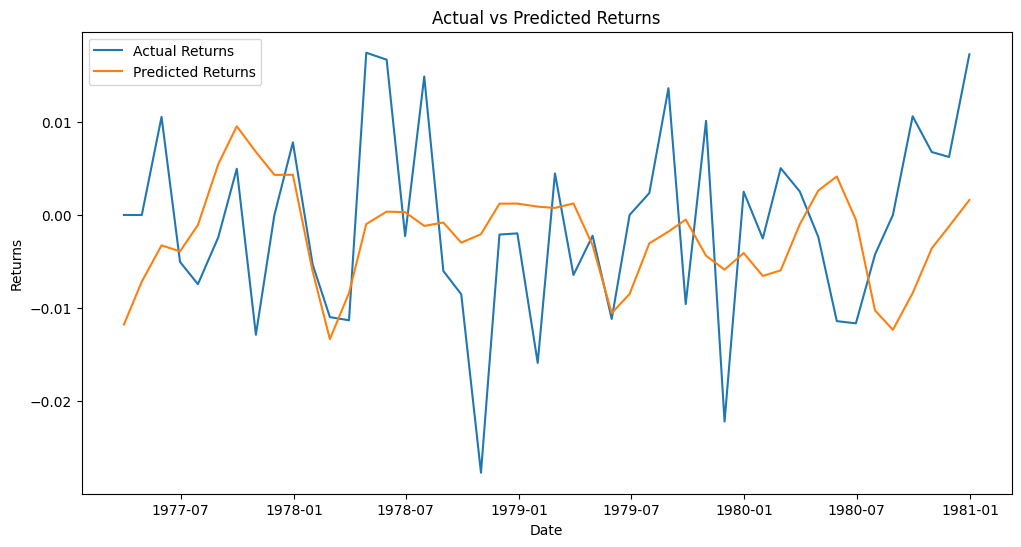

In [ ]:
#graph the results time(dates) on x axis and predicted and actual returns on the y axis

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
results_df['date'] = pd.to_datetime(results_df['date'])
plt.figure(figsize=(12, 6))
plt.plot(results_df['date'], results_df['actual'], label='Actual Returns')
plt.plot(results_df['date'], results_df['predicted'], label='Predicted Returns')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Date')
plt.ylabel('Returns')
plt.title('Actual vs Predicted Returns')
plt.legend()
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

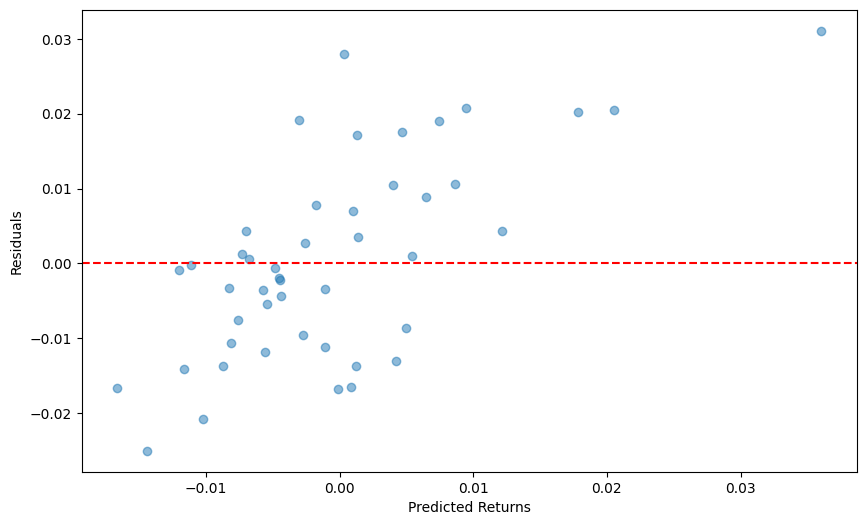

In [ ]:
# graph the residuals against predicted values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, y_pred - y_test, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Returns')
plt.ylabel('Residuals')
plt






Text(0.5, 1.0, 'Actual vs Predicted Returns')

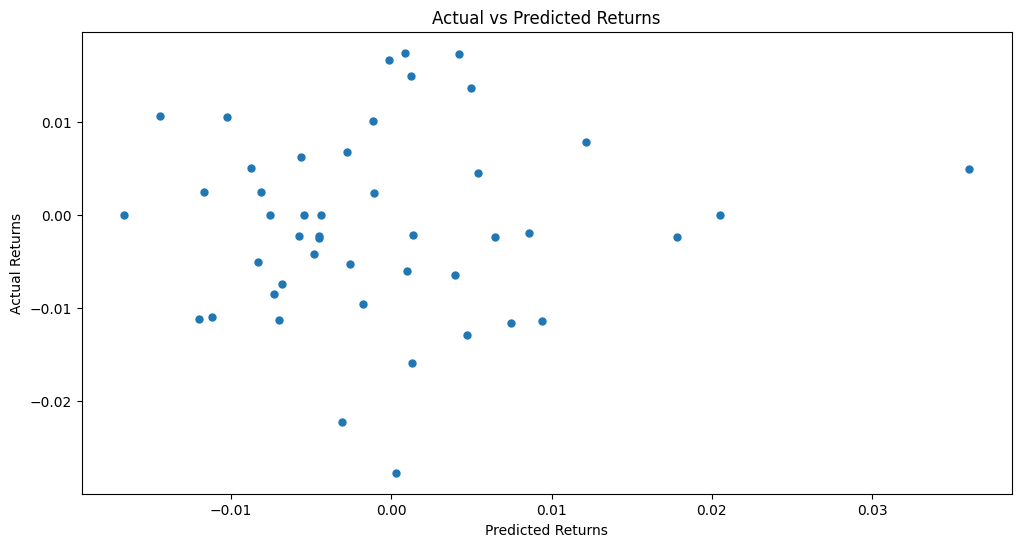

In [ ]:
# grah the actual returns on the y axis and predicted on the x
plt.figure(figsize=(12, 6))
plt.plot(results_df['predicted'], results_df['actual'], marker='o', linestyle='', markersize=5)
plt.ylabel('Actual Returns')
plt.xlabel('Predicted Returns')
plt.title('Actual vs Predicted Returns')

In [19]:
# fit a linear model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X_train_last = X_train[:, -1, :]
X_test_last  = X_test[:, -1, :]

linear_model = LinearRegression()
linear_model.fit(X_train_last, y_train)
y_pred_linear = linear_model.predict(X_test_last)



In [ ]:
# metric measures
mse = mean_squared_error(y_test, y_pred_linear)
mae = mean_absolute_error(y_test, y_pred_linear)
r2 = r2_score(y_test, y_pred_linear)
print(f"MSE: {mse}, MAE: {mae}, R2: {r2}")

MSE: 0.00012780183169525117, MAE: 0.008841232396662235, R2: -0.30537569522857666


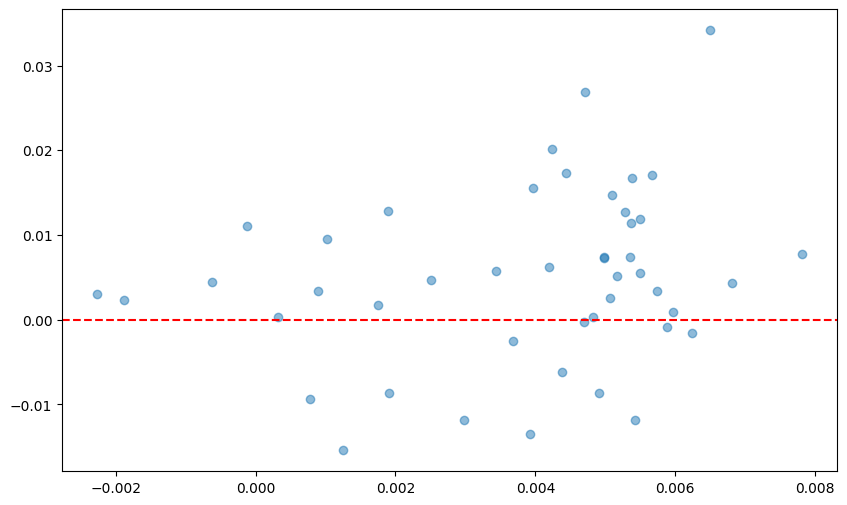

In [ ]:
# graph the residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_linear, y_pred_linear - y_test, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')


Text(0.5, 0, 'Predicted Returns')

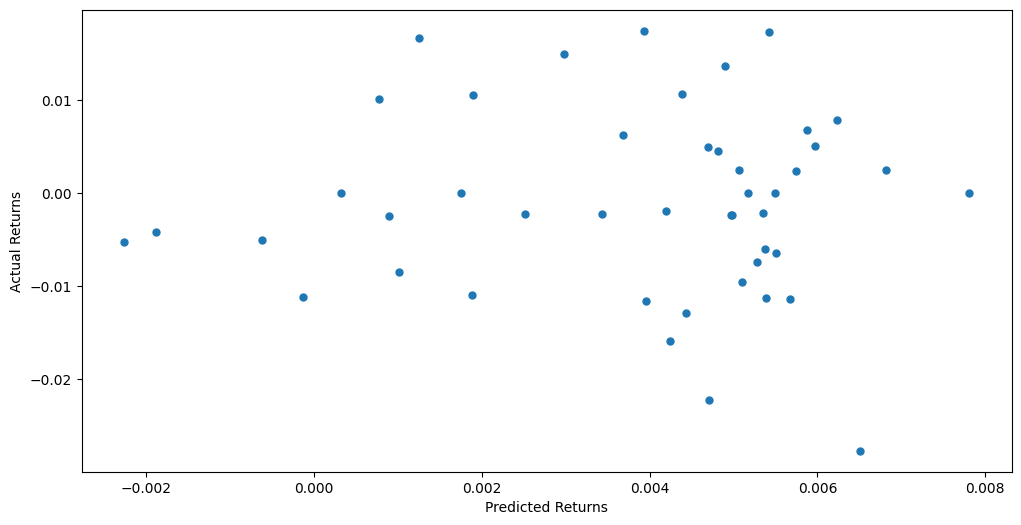

In [ ]:
# plot actual vs predited
plt.figure(figsize=(12, 6))
plt.plot(y_pred_linear,y_test, marker='o', linestyle='', markersize=5)
plt.ylabel('Actual Returns')
plt.xlabel('Predicted Returns')

In [ ]:
#


# Historical Attention Layer
This layer is supposed to take the output from the LSTM and apply the attention formula so that we can output r

$$r = ∑^K_{k=1 } ATT(h_K, h_k)h_k$$

where
$$ATT(h_K, h_k) = \frac {exp(α_k)} {∑^K_{k'=1 }exp(\alpha_k')}$$

# Reinforcement Learning
- Remember to compute te finegrained volatility for the months
- 57 companies throughout since there has to be alignment in trading periods
- Used Tensorflow because it has a keras integration which is useful for model training and processing
- Will use tensorflow RL because it would integrate well with the tensor flow

In [16]:
import tensorflow as tf
class PortfolioGenerator(tf.keras.layers.Layer):
  def __init__(self, num_assets, temperature = 1.0, **kwargs):
    super().__init__(**kwargs)
    self.temperature = temperature
    self.num_assets = num_assets

  def call(self, scores):                 # scores: [B,T,I]
    scores = tf.convert_to_tensor(scores)
    rank = scores.shape.rank # number of dimensions
    if rank == 2:
      scores = scores[:, tf.newaxis, :]
    B = tf.shape(scores)[0]
    T = tf.shape(scores)[1]
    I = tf.shape(scores)[2]

    scores_flat = tf.reshape(scores, [-1,I])
    sorted_indices = tf.argsort(scores_flat, direction='DESCENDING', axis=-1)
    sorted_scores = tf.gather(scores_flat, sorted_indices, batch_dims=1)  # [N, I]

    K = self.num_assets

    long_indices_flat = sorted_indices[:, :K]
    long_scores_flat  = sorted_scores[:, :K]
    long_weights_flat = tf.nn.softmax(
        long_scores_flat / self.temperature, axis=-1
    )

    short_indices_flat = sorted_indices[:, -K:]
    short_scores_flat  = sorted_scores[:, -K:]
    short_weights_flat = tf.nn.softmax(
        short_scores_flat / self.temperature, axis=-1
    )

    long_indices = tf.reshape(long_indices_flat, [B, T, K])
    long_weights = tf.reshape(long_weights_flat, [B, T, K])
    short_indices = tf.reshape(short_indices_flat, [B, T, K])
    short_weights = tf.reshape(short_weights_flat, [B, T, K])

    if rank == 2:
        long_indices = tf.squeeze(long_indices, axis=1)
        long_weights = tf.squeeze(long_weights, axis=1)
        short_indices = tf.squeeze(short_indices, axis=1)
        short_weights = tf.squeeze(short_weights, axis=1)

    return (long_indices, long_weights), (short_indices, short_weights)

  def get_config(self):
        config = super().get_config()
        config.update({
            "num_assets": self.num_assets,
            "temperature": self.temperature,
        })
        return config

In [20]:
import tensorflow as tf
class EndToEndPolicy(tf.keras.Model):
  def __init__(self, num_assets, feature_dim, lstm_units=128, attention_units=128, d_k = 64, d_v = 64, temperature = 1.0, **kwargs):
    super().__init__(**kwargs)
    self.num_assets = num_assets
    self.feature_dim = feature_dim
    self.lstm_units = lstm_units
    self.attention_units = attention_units
    self.d_k = d_k
    self.d_v = d_v
    self.temperature = temperature

    # Backbone with all the layers
    self.lstm_layer = LSTMLayer(lstm_units)
    self.attention_layer = HistoricalAttention(attention_units)
    self.cross_attn_layer = CrossAssetAttention(d_k, d_v)

    self.proj = tf.keras.layers.Dense(d_v, activation = "gelu")

    # Determines the stock for shorting and long
    self.weights_head = PortfolioGenerator(num_assets, temperature)

  def build(self, input_shape):
    # input_shape for policy will be (None, T, I, F)
    _, T, I, F = input_shape

    # Explicitly build sub-layers with appropriate input shapes
    lstm_input_shape = (None, T, F)
    self.lstm_layer.build(lstm_input_shape)

    # HistoricalAttention takes (output_seq, h_K) from LSTM
    # output_seq shape: (None, T, lstm_units), h_K shape: (None, lstm_units)
    self.attention_layer.build(((None, T, self.lstm_units), (None, self.lstm_units)))

    # Proj layer input: combined, which is (None, T, I, 2*lstm_units)
    self.proj.build((None, T, I, 2 * self.lstm_units))

    # CrossAssetAttention input: combined_for_caan, which is (None, I, d_v)
    self.cross_attn_layer.build((None, I, self.d_v))

    # PortfolioGenerator input: s_t, which is (None, T, I)
    self.weights_head.build((None, T, I))

    super().build(input_shape) # Mark the EndToEndPolicy model as built

  def compute_scores(self, X): # Helper method to compute scores s_t
    B = tf.shape(X)[0]; T = tf.shape(X)[1]; I = tf.shape(X)[2]; F = tf.shape(X)[3]
    Xi = tf.reshape(X, [B*I, T, F])
    out_seq, h_K, c_K = self.lstm_layer(Xi)
    U = tf.shape(out_seq)[-1] # lstm_units
    # Historical Summary per asset, summarizing the window history
    hist_ctx = self.attention_layer(out_seq, h_K)     # [B*I, U]
    hist_ctx_reshaped = tf.reshape(hist_ctx, [B, I, U]) # [B, I, U]

    # Reshape LSTM output for cross-asset attention per timestep and per asset
    out_seq_reshaped = tf.reshape(out_seq, [B, T, I, U])     # [B, T, I, U]

    # Tile the historical context to match the time dimension for concatenation
    hist_ctx_tiled   = tf.tile(hist_ctx_reshaped[:, tf.newaxis, :, :], [1, T, 1, 1]) # [B, T, I, U]

    # Combine LSTM output for current timestep and historical context
    combined = tf.concat([out_seq_reshaped, hist_ctx_tiled], axis=-1)  # [B, T, I, 2U]
    combined = self.proj(combined) # [B, T, I, d_v]

    # Apply CrossAssetAttention in a vectorized manner across B and T
    # Reshape from [B, T, I, d_v] to [(B*T), I, d_v]
    combined_for_caan = tf.reshape(combined, [B * T, I, combined.shape[-1]])

    # Apply CrossAssetAttention, which takes [Batch, N, Features] and returns [Batch, N]
    s_t_flat_time = self.cross_attn_layer(combined_for_caan) # [(B*T), I]

    # Reshape back to [B, T, I]
    s_t = tf.reshape(s_t_flat_time, [B, T, I])
    return s_t

  # This is the main call method for training and direct probability inference
  def call(self, X, training=False):
    s_t = self.compute_scores(X)
    p = tf.nn.sigmoid(s_t) # [B, T, I]
    return p, s_t

  # obtain the portfolio for actual investment
  def build_portfolio(self, X):
    s_t = self.compute_scores(X)
    (long_idx, long_w), (short_idx, short_w) = self.weights_head(s_t) # s_t is [B, T, I], weights_head expects [B,T,I]
    return (long_idx, long_w), (short_idx, short_w), s_t

  def get_config(self):
        config = super().get_config()
        config.update({
            "num_assets": self.num_assets,
            "feature_dim": self.feature_dim,
            "lstm_units": self.lstm_units,
            "attention_units": self.attention_units,
            "d_k": self.d_k,
            "d_v": self.d_v,
            "temperature": self.temperature,
        })
        return config

In [21]:
# Sharpe cost, remember to add the risk-free rate
@tf.function
def sharpe_loss_from_weights(weights, returns, cost=5e-4, ann_factor=12.0, l2_reg=0.0, eps=1e-8):
    """
    weights: [B,T,I]  predicted b_t
    returns: [B,T,I]  realized simple returns for each asset at t (aligned)
    """
    # Use previous weights to earn period t returns
    w_prev = tf.concat([weights[:, :1, :], weights[:, :-1, :]], axis=1)  # [B,T,I]
    # compute the returns and losses from the weights in the previous period
    pnl = tf.reduce_sum(w_prev * returns, axis=-1)                       # [B,T]
    # how have the weights changed
    turnover = tf.reduce_sum(tf.abs(weights - w_prev), axis=-1)          # [B,T]
    # Find the actual profits, accounting for transaction cost
    r_t = pnl - cost * turnover                                          # [B,T]

    # average returns
    r_mean = tf.reduce_mean(r_t, axis=1)            # [B]
    # standard deviation of the returns
    r_std  = tf.math.reduce_std(r_t, axis=1) + eps  # [B]
    # compute sharpe ratio
    sharpe = tf.reduce_mean(r_mean / r_std) * tf.sqrt(ann_factor)  # scalar

    reg = l2_reg * tf.reduce_mean(tf.reduce_sum(tf.square(weights), axis=-1))
    loss = -sharpe + reg
    return loss, sharpe, tf.reduce_mean(turnover)


In [22]:
class RLSharpeTrainer(tf.keras.Model):
    def __init__(self, policy_model, cost=5e-4, ann_factor=12.0, H0 = 0.9, action_threshold=0.5, **kwargs):
        super().__init__(**kwargs)
        self.policy = policy_model
        self.cost = cost
        self.ann_factor = ann_factor
        self.H0_value = H0 # Store the float value for get_config
        self.H0 = tf.Variable(H0, trainable=False, dtype=tf.float32)
        self.action_threshold = action_threshold

    def build(self, input_shape):
        # For custom Keras Model subclasses, it's often best to call super().build(input_shape)
        # and let the policy's build method be implicitly called when it's first used in call().
        # The policy will be built when RLSharpeTrainer.call() first calls self.policy().
        super().build(input_shape) # Call parent's build method to finalize

    def call(self, inputs, training=False):
      X_seq, _ = inputs
      p, _ = self.policy(X_seq, training=training)
      return p

    def compute_sharpe_from_actions(self, actions, returns):
       eps = 1e-8
       sel_count = tf.reduce_sum(actions, axis=-1, keepdims=True)
       eq_w = tf.ones_like(actions) / tf.cast(tf.shape(actions)[-1], tf.float32)
       w_t = tf.where(sel_count > 0.0, actions / (sel_count + eps), eq_w)

       w_prev = tf.concat([w_t[:, :1, :], w_t[:, :-1, :]], axis=1)  # [B,T,I]
       pnl = tf.reduce_sum(w_prev * returns, axis=-1)               # [B,T]
       turnover = tf.reduce_sum(tf.abs(w_t - w_prev), axis=-1)      # [B,T]
       r_t = pnl - self.cost * turnover

       r_mean = tf.reduce_mean(r_t, axis=1)                         # [B]
       r_std  = tf.math.reduce_std(r_t, axis=1) + eps               # [B]
       sharpe = (r_mean / r_std) * tf.sqrt(self.ann_factor)         # [B]
       return sharpe, tf.reduce_mean(turnover)

    def train_step(self, data):
        X_seq, R_seq = data[0]
        B = tf.shape(X_seq)[0]
        with tf.GradientTape() as tape:
            p, _ = self.policy(X_seq, training=True)
            eps = 1e-8
            p_clipped = tf.clip_by_value(p, eps, 1.0 - eps)

            u = tf.random.uniform(tf.shape(p_clipped), minval=0.0, maxval=1.0)
            actions = tf.cast(u < p_clipped, tf.float32)
            H_pi, avg_turnover = self.compute_sharpe_from_actions(actions, R_seq)
            advantage = tf.stop_gradient(H_pi - self.H0)
            logp = (actions*tf.math.log(p_clipped)) + ((1-actions)*tf.math.log(1-p_clipped))
            logp_sum = tf.reduce_sum(logp, axis=[1,2])
            loss = -tf.reduce_mean(advantage * logp_sum)

            vars_ = self.policy.trainable_variables
            grads = tape.gradient(loss, vars_)
            self.optimizer.apply_gradients(zip(grads, vars_))

            mean_sharpe = tf.reduce_mean(H_pi)
            loss = - (mean_sharpe - self.H0)
            return {"loss": loss, "sharpe": mean_sharpe, "turnover": avg_turnover}

    def test_step(self, data):
        X_seq, R_seq = data[0]
        p, _ = self.policy(X_seq, training=False)
        actions = tf.cast(p > self.action_threshold, tf.float32)
        H_pi, avg_turnover = self.compute_sharpe_from_actions(actions, R_seq)
        mean_sharpe = tf.reduce_mean(H_pi)
        loss = -(mean_sharpe-self.H0)
        return {"loss": loss, "sharpe": mean_sharpe, "turnover": avg_turnover}

    def get_config(self):
        config = super().get_config()
        config.update({
            "policy_model": tf.keras.utils.serialize_keras_object(self.policy), # Serialize policy
            "cost": self.cost,
            "ann_factor": self.ann_factor,
            "H0": self.H0_value, # Use the stored float value
            "action_threshold": self.action_threshold,
        })
        return config

    @classmethod
    def from_config(cls, config):
        policy_config = config.pop("policy_model")
        policy_model = tf.keras.utils.deserialize_keras_object(policy_config)
        return cls(policy_model=policy_model, **config)

The function below takes the data, groups them by time windows then per company in that time window so then it is able to generate the portfolio.

In [23]:
import numpy as np
import pandas as pd

def make_monthly_sequences(
    df: pd.DataFrame,
    window: int = 12,
    feature_cols=None,
    target_col: str = "return_no_dividends",
    company_col: str = "company_name",
    date_col: str = "date",
):
    """
    Turn a long monthly panel DataFrame into X_seq [B, T, I, F] and R_seq [B, T, I].

    Assumes:
      - df has one row per (date, company)
      - all rows are monthly (you've already aggregated to month-end)
      - each company roughly shares the same monthly grid (missing values are ffilled/bfilled)

    Args
    ----
    df : pd.DataFrame
        Must contain columns: date_col, company_col, target_col, feature_cols.
    window : int
        Number of months per sequence (e.g., 12).
    feature_cols : list[str]
        Feature column names to use as X. If None, all numeric cols except date/company/target are used.
    target_col : str
        Column name for realized monthly returns.
    company_col : str
        Column name for company identifier.
    date_col : str
        Column name for date.

    Returns
    -------
    X_seq : np.ndarray
        Shape [B, T, I, F]: sequences of features.
    R_seq : np.ndarray
        Shape [B, T, I]: sequences of realized returns.
    companies : np.ndarray
        Shape [I], ordered list of company ids used along axis 2.
    dates : np.ndarray
        Shape [T_total], ordered list of dates (before windowing).
    """
    df = df.copy()
    # ensure datetime and sorted
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values([date_col, company_col]).reset_index(drop=True)

    # default feature columns: all numeric except date/company/target
    if feature_cols is None:
        exclude = {date_col, company_col, target_col}
        feature_cols = [
            c for c in df.columns
            if c not in exclude and pd.api.types.is_numeric_dtype(df[c])
        ]

    # build regular panel index
    companies = np.sort(df[company_col].unique())
    dates = np.sort(df[date_col].unique())
    I = len(companies)
    T_total = len(dates)

    panel = df.set_index([date_col, company_col]).sort_index()
    full_index = pd.MultiIndex.from_product([dates, companies],
                                            names=[date_col, company_col])
    panel = panel.reindex(full_index)

    # fill missing within each company
    panel = panel.groupby(level=company_col).ffill().bfill()

    # build feature tensor X_all: [T_total, I, F]
    feat_arrays = []
    for col in feature_cols:
        wide = panel[col].unstack(company_col).loc[dates, companies]  # [T_total, I]
        feat_arrays.append(wide.values[..., None])

    X_all = np.concatenate(feat_arrays, axis=-1).astype(np.float32)   # [T_total, I, F]
    F = X_all.shape[-1]

    # build returns tensor R_all: [T_total, I]
    R_wide = panel[target_col].unstack(company_col).loc[dates, companies]
    R_all = R_wide.values.astype(np.float32)

    # slide window over time to make sequences
    X_seq_list = []
    R_seq_list = []
    for start in range(T_total - window):
        end = start + window       # slice [start, end)
        X_seq_list.append(X_all[start:end, :, :])  # [window, I, F]
        R_seq_list.append(R_all[start:end, :])     # [window, I]

    X_seq = np.stack(X_seq_list, axis=0)   # [B, T, I, F]
    R_seq = np.stack(R_seq_list, axis=0)   # [B, T, I]

    return X_seq, R_seq, companies, dates


In [24]:
# Load data
path = '/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStockAligned/sp500_final_1960_1980.csv'
train_df = pd.read_csv(path)
train_df.head()


,permno,company_name,date,price,return_ex_div,volume,shares_out_thousands,dividend_cash_amount,book_to_market_value,pe_ratio,finegrained_volatility_12m
0,10145,HONEYWELL INTERNATIONAL INC,1960-01-29,51.500,-0.106291,682.0,19906.0,0.00,5.442028e-07,20.205469,2.793221
1,10145,HONEYWELL INTERNATIONAL INC,1960-02-29,52.625,0.021845,1749.0,19906.0,0.45,5.442028e-07,20.205469,2.793221
2,10145,HONEYWELL INTERNATIONAL INC,1960-03-31,49.000,-0.068884,1273.0,19906.0,0.00,5.442028e-07,20.205469,2.793221
3,10145,HONEYWELL INTERNATIONAL INC,1960-04-29,49.375,0.007653,919.0,19906.0,0.00,5.442028e-07,20.205469,2.793221
4,10145,HONEYWELL INTERNATIONAL INC,1960-05-31,51.750,0.048101,1115.0,19906.0,0.45,5.442028e-07,20.205469,2.793221


In [25]:
# Get the sequences
X_seq, R_seq, companies, dates = make_monthly_sequences(
    train_df,
     window=12,
    feature_cols=[
        "volume",
        "dividend_cash_amount",
        "pe_ratio",
        "shares_out_thousands",
        "book_to_market_value",
        "finegrained_volatility_12m",
    ],
    target_col="return_ex_div",
    company_col="company_name",
    date_col="date",
    )


In [26]:
B = X_seq.shape[0] # number of rolling windows
print(B)
I=  X_seq.shape[2] # number of companies
print(I)
F=   X_seq.shape[3] # number of features
print(F)
train_frac = 0.8
cut = int(train_frac * B)

X_train = X_seq[:cut]     # earliest sequences
R_train = R_seq[:cut]

X_val   = X_seq[cut:]     # most recent sequences
R_val   = R_seq[cut:]

240
57
6


In [27]:
# Shapes: X_seq [B,T,I,F], R_seq [B,T,I]
# B - Batch size, T = timestep, I= Number of companies, F = number of features

num_assets, feature_dim = 10, F
E = 20
policy = EndToEndPolicy(num_assets, feature_dim, lstm_units=256, attention_units=128, d_k=128, d_v=32, temperature=0.75)
trainer = RLSharpeTrainer(policy, cost=5e-4, ann_factor=12.0, H0=0.2)
trainer.compile()  # optimizer is inside train_step; ok in Keras 3

history = trainer.fit(x=(X_train, R_train), y=None, epochs=E, validation_data=((X_val, R_val), None))


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'lstm_layer_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'historical_attention_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'cross_asset_attention_1', how

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 661ms/step - loss: -0.3740 - sharpe: 0.5740 - turnover: 0.9193 - val_loss: -0.5262 - val_sharpe: 0.7262 - val_turnover: 0.0000e+00
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 588ms/step - loss: -0.5478 - sharpe: 0.7478 - turnover: 0.8762 - val_loss: -0.5262 - val_sharpe: 0.7262 - val_turnover: 0.0000e+00
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 590ms/step - loss: -0.4331 - sharpe: 0.6331 - turnover: 0.9634 - val_loss: -0.5262 - val_sharpe: 0.7262 - val_turnover: 0.0000e+00
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 582ms/step - loss: -0.3555 - sharpe: 0.5555 - turnover: 0.9550 - val_loss: -0.5262 - val_sharpe: 0.7262 - val_turnover: 0.0000e+00
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 563ms/step - loss: -0.3829 - sharpe: 0.5829 - turnover: 0.9607 - val_loss: -0.5262 - val_sharpe: 0.7262 - val_turnover: 0.0000e+00
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 555ms/step - loss: -0.4680 - sharpe: 0.6680 - turnover: 0.9676 - val_loss: -0.5262 - val_sharpe: 0.7262 - val_turnover: 0.

In [28]:
trainer.evaluate(x=(X_val, R_val), y=None)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: -0.5262 - sharpe: 0.7262 - turnover: 0.0000e+00


[<tf.Tensor: shape=(), dtype=float32, numpy=-0.5262304544448853>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.7262304425239563>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.0>]

In [29]:
# get next month's picks
def get_next_month_picks(agent, X_seq, R_seq, companies, num_assets = 10):
  import numpy as np
  import tensorflow as tf

  # ensure batch dimensions
  X_seq = tf.convert_to_tensor(X_seq)

  if X_seq.shape.rank == 3:
        X_last = X_seq[tf.newaxis, ...]
  else:
        X_last = X_seq[-1:,...]

# call the policy
  (long_idx, long_w), (short_idx, short_w), s_t = agent.policy.build_portfolio(
        X_last
    )
# Use the last timestep
  long_idx_t  = long_idx[0, -1, :].numpy()     # [K]
  long_w_t    = long_w[0, -1, :].numpy()       # [K]
  short_idx_t = short_idx[0, -1, :].numpy()    # [K]
  short_w_t   = short_w[0, -1, :].numpy()      # [K]

  companies = np.asarray(companies)

  long_indices  = long_idx_t.astype(int)
  short_indices = short_idx_t.astype(int)

  long_companies  = companies[long_indices]
  short_companies = companies[short_indices]

  long_weights  = long_w_t          # already softmax-normalized
  short_weights = short_w_t

  return (
      long_companies, long_weights, long_indices,
      short_companies, short_weights, short_indices,
  )

In [30]:
# get the portfolio value increase
import numpy as np
def buy_and_hold_long_short(
    R_all: np.ndarray,
    t0: int,
   long_indices: np.ndarray,
    long_weights: np.ndarray,
    short_indices: np.ndarray | None = None,
    short_weights: np.ndarray | None = None,
     horizon: int = 12,
):
  T, I= R_all.shape
  long_indices  = np.asarray(long_indices,  dtype=int)
  long_weights  = np.asarray(long_weights,  dtype=float)

  if short_indices is not None:
      short_indices = np.asarray(short_indices, dtype=int)
      short_weights = np.asarray(short_weights, dtype=float)

  # Need t0+1 ... t0+horizon within data
  if t0 + horizon >= T:
      return "not enough months ahead"
  R_h = R_all[t0+1 : t0+1+horizon, :]       # [H, I]
  H = R_h.shape[0]
  # full weight vector
  w_full = np.zeros(I, dtype=float)

  # longs: positive weights
  if long_indices.size > 0:
      w_full[long_indices] += long_weights

  # shorts: negative weights
  if short_indices is not None and short_indices.size > 0:
      w_full[short_indices] -= short_weights

   # per-asset growth
  growth_per_asset = np.prod(1.0 + R_h, axis=0)   # [I]
  asset_12m_returns = growth_per_asset - 1.0      # [I]

  # portfolio final value & return
  r_p_t = R_h @ w_full
  portfolio_value_path = np.cumprod(1.0 + r_p_t)
  portfolio_12m_return = portfolio_value_path[-1] - 1.0

  return asset_12m_returns, portfolio_value_path, portfolio_12m_return, w_full





In [31]:
(
      long_companies, long_weights, long_indices,
      short_companies, short_weights, short_indices,
  ) = get_next_month_picks(trainer, X_seq, R_seq, companies, num_assets=10)

print(long_companies, long_weights)
print(short_companies, short_weights)
# long companies and short companies are the same



['HONEYWELL INTERNATIONAL INC' 'INTL BUSINESS MACHINES CORP'
 'ENTERGY CORP' 'CATERPILLAR INC' 'PG&E CORP' 'PPG INDUSTRIES INC'
 'PUBLIC SERVICE ENTRP GRP INC' 'GE AEROSPACE' 'EQT CORP'
 'BRISTOL-MYERS SQUIBB CO'] [0.10000192 0.10000096 0.10000027 0.10000023 0.10000003 0.09999995
 0.09999943 0.0999994  0.09999908 0.09999874]
['ALCOA INC' 'COLGATE-PALMOLIVE CO' 'HALLIBURTON CO'
 'MOTOROLA SOLUTIONS INC' 'TRANE TECHNOLOGIES PLC' 'ONEOK INC'
 'CONOCOPHILLIPS' 'GENERAL MILLS INC' 'TEXAS INSTRUMENTS INC' 'HESS CORP'] [0.10000096 0.10000055 0.10000053 0.10000011 0.09999996 0.09999991
 0.09999982 0.09999965 0.09999933 0.09999919]


In [32]:
import numpy as np
import pandas as pd

# Reconstruct R_all_unwindowed and dates_actual from train_df
df_temp = train_df.copy()
df_temp['date'] = pd.to_datetime(df_temp['date'])
df_temp = df_temp.sort_values(['date', 'company_name']).reset_index(drop=True)

companies_actual = np.sort(df_temp['company_name'].unique())
dates_actual = np.sort(df_temp['date'].unique())

panel = df_temp.set_index(['date', 'company_name']).sort_index()
full_index = pd.MultiIndex.from_product([dates_actual, companies_actual],
                                        names=['date', 'company_name'])
panel = panel.reindex(full_index)
panel = panel.groupby(level='company_name').ffill().bfill() # Handle NaNs within each company

R_all_unwindowed = panel['return_ex_div'].unstack('company_name').loc[dates_actual, companies_actual].values.astype(np.float32)
horizon = 12

# t0 should be the starting month index in R_all_unwindowed for the horizon period
t0 = len(dates_actual) - horizon-1 # Evaluate performance over the last 'horizon' months in the training data
asset_ret_12m, value_path, port_12m, w_full = buy_and_hold_long_short(R_all_unwindowed, t0=t0, long_indices=long_indices, long_weights= long_weights, short_indices = short_indices, short_weights = short_weights,  horizon=horizon)

print("Asset 12-month Returns:", asset_ret_12m)
print("Portfolio Value Path (last horizon months):", value_path)
print("Portfolio 12-month Return:", port_12m)
print("Dates", dates_actual[t0:t0+horizon])
# compute the volatility
volatility = np.std(asset_ret_12m)
print("Volatility:", volatility)
# compute sharpe ratio
sharpe_ratio = port_12m / volatility
print("Sharpe Ratio:", sharpe_ratio)

Asset 12-month Returns: [ 0.17413044  0.37385774  0.0865593   0.2013905  -0.05594182 -0.2257595
  0.30740678  0.36148715  0.03333187  0.0740726   0.76496375 -0.03260833
  0.01739037  0.22395778  0.025774    0.07713211  0.06473029  0.26363897
  0.22683871 -0.12121224  0.04591715 -0.08910835  0.09951293 -0.0909096
  0.46258307 -0.11215043 -0.37499964  0.20987558  0.41322255  0.07999909
  0.9647081  -0.04568619  0.88943315  0.08905935  0.05436862  0.13513613
  0.306749    0.14473796 -0.18356377  3.4904532   0.1730094   0.42787266
  0.57291615  0.0954783   0.36305833 -0.10869598  0.411255   -0.07239234
 -0.11688286  0.41860366  0.62995374  0.87199855  0.0652169   0.37215972
  0.43990242 -0.02732289 -0.03910595]
Portfolio Value Path (last horizon months): [0.94121239 0.90720796 0.94283763 0.97988625 0.92695122 0.92852413
 0.91210632 0.87349306 0.79045724 0.78524498 0.72855588 0.75480248]
Portfolio 12-month Return: -0.24519751699206815
Dates ['1979-12-31T00:00:00.000000000' '1980-01-31T00:00

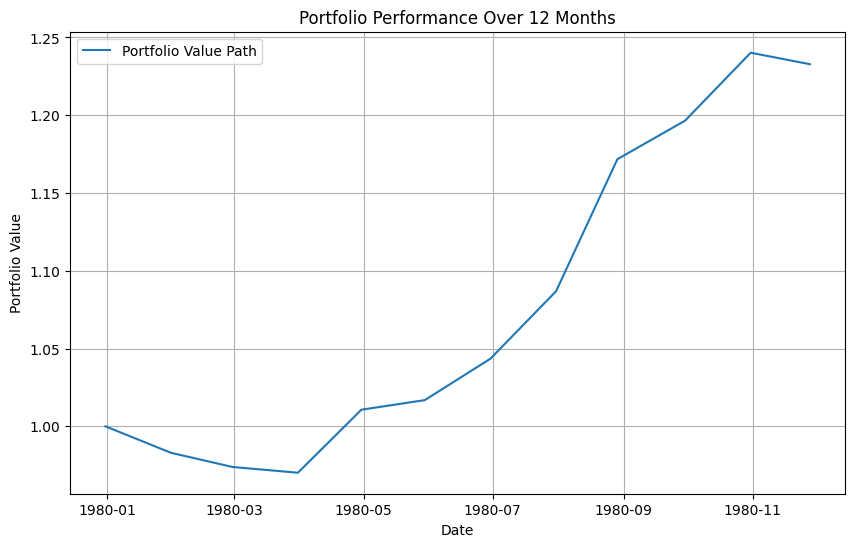

In [73]:
# Graph the performance across the dates
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dates_actual[t0:t0+horizon], value_path, label='Portfolio Value Path')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value')
ax.set_title('Portfolio Performance Over 12 Months')
ax.legend()
plt.grid(True)
plt.show()

In [ ]:
# save the model
policy.save_weights("policy.weights.h5")

In [33]:
# Load data
# Load data
path = '/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStockAligned/sp500_final_1981_2000.csv'
validation_df = pd.read_csv(path)
validation_df.head()
# use validation data 2 year rolling windows

# get monthly sequences

# get monthly picks
# evaluate performance

,permno,company_name,date,price,return_ex_div,volume,shares_out_thousands,dividend_cash_amount,book_to_market_value,pe_ratio,finegrained_volatility_12m
0,10145,HONEYWELL INTERNATIONAL INC,1981-01-30,50.000,-0.065421,16862.0,33489.0,0.00,0.000001,4.784621,4.218171
1,10145,HONEYWELL INTERNATIONAL INC,1981-02-27,53.250,0.065000,15091.0,33489.0,0.55,0.000001,4.784621,4.218171
2,10145,HONEYWELL INTERNATIONAL INC,1981-03-31,52.375,-0.016432,17792.0,33489.0,0.00,0.000001,4.784621,4.218171
3,10145,HONEYWELL INTERNATIONAL INC,1981-04-30,52.500,0.002387,18510.0,33489.0,0.00,0.000001,4.784621,4.218171
4,10145,HONEYWELL INTERNATIONAL INC,1981-05-29,54.250,0.033333,21018.0,33489.0,0.60,0.000001,4.784621,4.218171


In [34]:
df_temp_val = validation_df.copy()
df_temp_val['date'] = pd.to_datetime(df_temp_val['date'])
df_temp_val = df_temp_val.sort_values(['date', 'company_name']).reset_index(drop=True)

companies_actual = np.sort(df_temp_val['company_name'].unique())
dates_actual = np.sort(df_temp_val['date'].unique())

# Make sure they match what make_monthly_sequences used
# (optional sanity check)
# assert np.array_equal(companies_actual, companies_val)
# assert np.array_equal(dates_actual, dates_val)

panel = df_temp_val.set_index(['date', 'company_name']).sort_index()
full_index = pd.MultiIndex.from_product([dates_actual, companies_actual],
                                        names=['date', 'company_name'])
panel = panel.reindex(full_index)
panel = panel.groupby(level='company_name').ffill().bfill()

R_all_unwindowed = (
    panel['return_ex_div']
    .unstack('company_name')
    .loc[dates_actual, companies_actual]
    .values
    .astype(np.float32)
)

T = len(dates_actual)
horizon = 12               # 12-month hold


In [35]:
window = 12
X_val_seq, R_val_seq, companies_val, dates_val = make_monthly_sequences(
    validation_df,
     window=window,
    feature_cols=[
        "volume",
        "dividend_cash_amount",
        "pe_ratio",
        "shares_out_thousands",
        "book_to_market_value",
        "finegrained_volatility_12m",
    ],
    target_col="return_ex_div",
    company_col="company_name",
    date_col="date",)
years_full_range = np.sort(pd.DatetimeIndex(dates_actual).year.unique())
horizon = 12

# split the validation set into two halves
cut = int(0.5 * len(X_val_seq))
X_val_seq_1, X_val_seq_2 = X_val_seq[:cut], X_val_seq[cut:]
R_val_seq_1, R_val_seq_2 = R_val_seq[:cut], R_val_seq[cut:]


In [78]:
# finetuning
import tensorflow as tf
# get the current running rate
# current_learning_rate = float(tf.keras.backend.get_value(trainer.optimizer.learning_rate))
# print("Current learning rate:", current_learning_rate)
# # reduce the learning rate
# new_learning_rate = current_learning_rate * 0.5
# print("New learning rate:", new_learning_rate)

#Fine-tune on validation sequences
trainer.optimizer.learning_rate.assign(5.6604452729077184e-05)

#implement early stopping so the model stops when a good sharpe ratio is reached
Epochs_finetune = 20
# this trainer is from the training stage
history_ft = trainer.fit(
    x=(X_val_seq, R_val_seq),
    y=None,
    epochs=Epochs_finetune,
)
# save the results
policy.save_weights("policy_ft.weights.h5")

AttributeError: 'RLSharpeTrainer' object has no attribute 'optimizer'


=== Segment (1981 → 1982) ===
Decision date: 1981-12-31T00:00:00.000000000
Eval window dates: ['1982-01-29T00:00:00.000000000' '1982-02-26T00:00:00.000000000'
 '1982-03-31T00:00:00.000000000' '1982-04-30T00:00:00.000000000'
 '1982-05-28T00:00:00.000000000' '1982-06-30T00:00:00.000000000'
 '1982-07-30T00:00:00.000000000' '1982-08-31T00:00:00.000000000'
 '1982-09-30T00:00:00.000000000' '1982-10-29T00:00:00.000000000'
 '1982-11-30T00:00:00.000000000' '1982-12-31T00:00:00.000000000']
Portfolio 12m Return: -0.04982950728390323
Volatility: 0.31857118
Sharpe Ratio: -0.15641561571089652


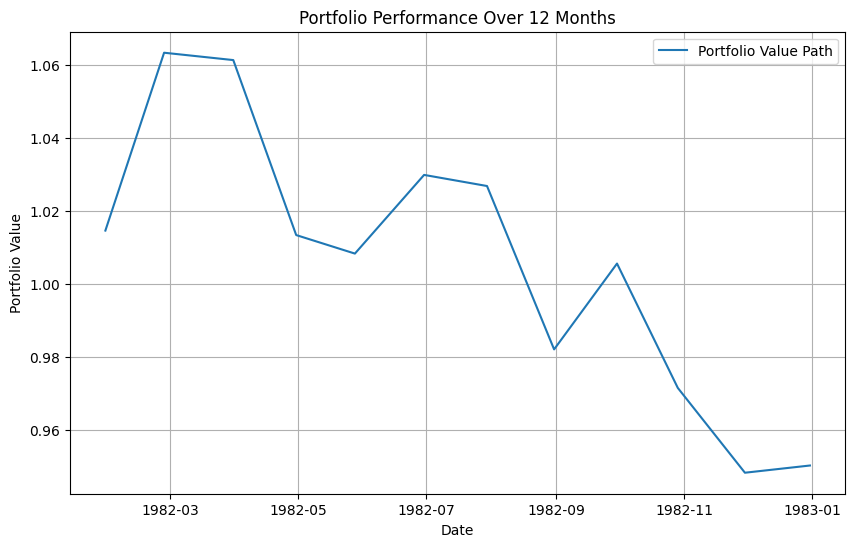


=== Segment 0 ===
Decision date (t0 in R_all_unwindowed): 1981-12-31T00:00:00.000000000
Eval window dates: ['1982-01-29T00:00:00.000000000' '1982-02-26T00:00:00.000000000'
 '1982-03-31T00:00:00.000000000' '1982-04-30T00:00:00.000000000'
 '1982-05-28T00:00:00.000000000' '1982-06-30T00:00:00.000000000'
 '1982-07-30T00:00:00.000000000' '1982-08-31T00:00:00.000000000'
 '1982-09-30T00:00:00.000000000' '1982-10-29T00:00:00.000000000'
 '1982-11-30T00:00:00.000000000' '1982-12-31T00:00:00.000000000']
Portfolio 12-month Return: -0.04982950728390323
Volatility: 0.31857118
Sharpe Ratio: -0.15641561571089652

=== Segment (1982 → 1983) ===
Decision date: 1982-12-31T00:00:00.000000000
Eval window dates: ['1983-01-31T00:00:00.000000000' '1983-02-28T00:00:00.000000000'
 '1983-03-31T00:00:00.000000000' '1983-04-29T00:00:00.000000000'
 '1983-05-31T00:00:00.000000000' '1983-06-30T00:00:00.000000000'
 '1983-07-29T00:00:00.000000000' '1983-08-31T00:00:00.000000000'
 '1983-09-30T00:00:00.000000000' '1983-1

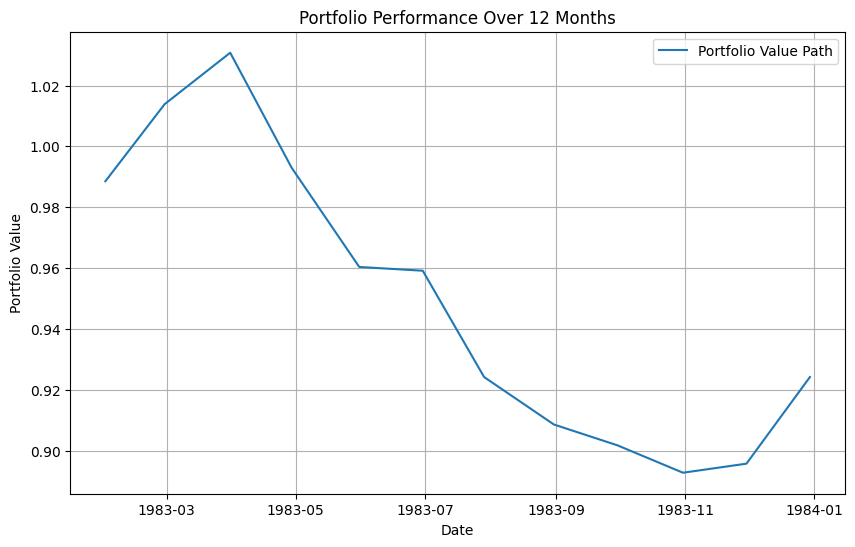


=== Segment 1 ===
Decision date (t0 in R_all_unwindowed): 1982-12-31T00:00:00.000000000
Eval window dates: ['1983-01-31T00:00:00.000000000' '1983-02-28T00:00:00.000000000'
 '1983-03-31T00:00:00.000000000' '1983-04-29T00:00:00.000000000'
 '1983-05-31T00:00:00.000000000' '1983-06-30T00:00:00.000000000'
 '1983-07-29T00:00:00.000000000' '1983-08-31T00:00:00.000000000'
 '1983-09-30T00:00:00.000000000' '1983-10-31T00:00:00.000000000'
 '1983-11-30T00:00:00.000000000' '1983-12-30T00:00:00.000000000']
Portfolio 12-month Return: -0.07583551854315085
Volatility: 0.203126
Sharpe Ratio: -0.3733422562783034

=== Segment (1983 → 1984) ===
Decision date: 1983-12-30T00:00:00.000000000
Eval window dates: ['1984-01-31T00:00:00.000000000' '1984-02-29T00:00:00.000000000'
 '1984-03-30T00:00:00.000000000' '1984-04-30T00:00:00.000000000'
 '1984-05-31T00:00:00.000000000' '1984-06-29T00:00:00.000000000'
 '1984-07-31T00:00:00.000000000' '1984-08-31T00:00:00.000000000'
 '1984-09-28T00:00:00.000000000' '1984-10-3

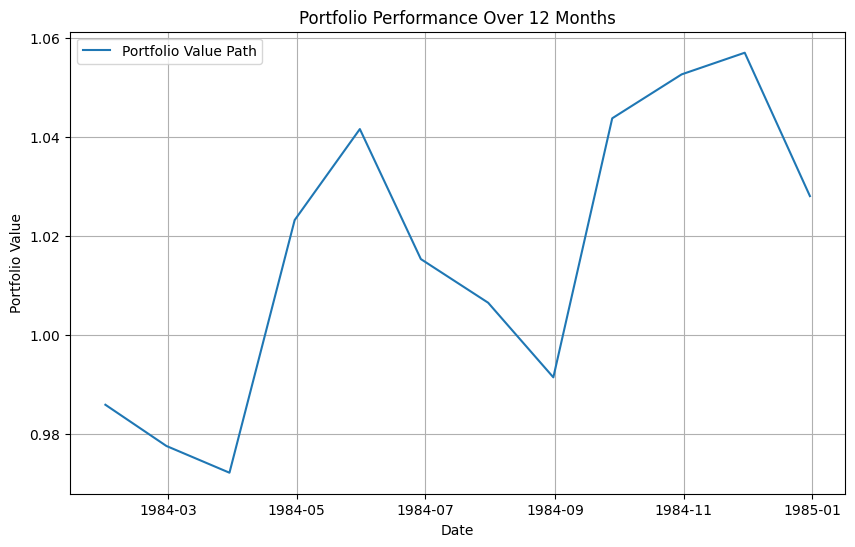


=== Segment 2 ===
Decision date (t0 in R_all_unwindowed): 1983-12-30T00:00:00.000000000
Eval window dates: ['1984-01-31T00:00:00.000000000' '1984-02-29T00:00:00.000000000'
 '1984-03-30T00:00:00.000000000' '1984-04-30T00:00:00.000000000'
 '1984-05-31T00:00:00.000000000' '1984-06-29T00:00:00.000000000'
 '1984-07-31T00:00:00.000000000' '1984-08-31T00:00:00.000000000'
 '1984-09-28T00:00:00.000000000' '1984-10-31T00:00:00.000000000'
 '1984-11-30T00:00:00.000000000' '1984-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.028064668661676118
Volatility: 0.16031872
Sharpe Ratio: 0.17505547152407183

=== Segment (1984 → 1985) ===
Decision date: 1984-12-31T00:00:00.000000000
Eval window dates: ['1985-01-31T00:00:00.000000000' '1985-02-28T00:00:00.000000000'
 '1985-03-29T00:00:00.000000000' '1985-04-30T00:00:00.000000000'
 '1985-05-31T00:00:00.000000000' '1985-06-28T00:00:00.000000000'
 '1985-07-31T00:00:00.000000000' '1985-08-30T00:00:00.000000000'
 '1985-09-30T00:00:00.000000000' '1985-10

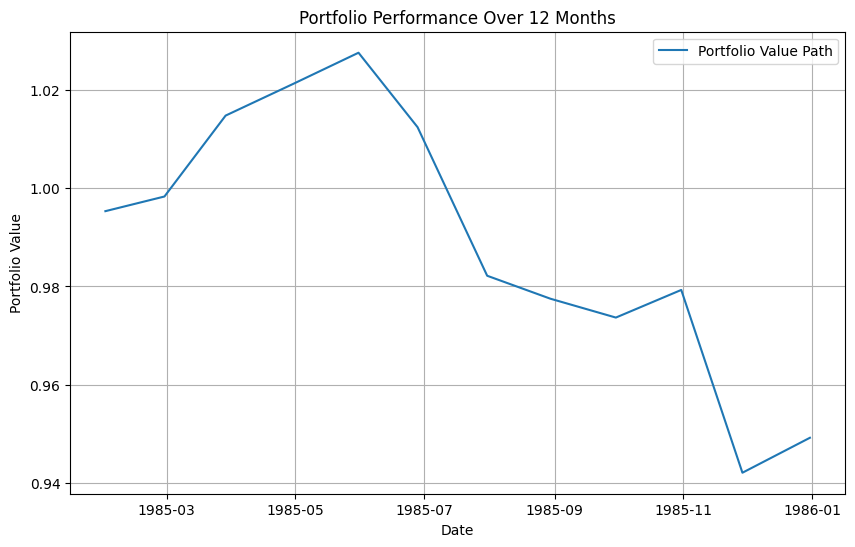


=== Segment 3 ===
Decision date (t0 in R_all_unwindowed): 1984-12-31T00:00:00.000000000
Eval window dates: ['1985-01-31T00:00:00.000000000' '1985-02-28T00:00:00.000000000'
 '1985-03-29T00:00:00.000000000' '1985-04-30T00:00:00.000000000'
 '1985-05-31T00:00:00.000000000' '1985-06-28T00:00:00.000000000'
 '1985-07-31T00:00:00.000000000' '1985-08-30T00:00:00.000000000'
 '1985-09-30T00:00:00.000000000' '1985-10-31T00:00:00.000000000'
 '1985-11-29T00:00:00.000000000' '1985-12-31T00:00:00.000000000']
Portfolio 12-month Return: -0.05082240356903478
Volatility: 0.20110995
Sharpe Ratio: -0.2527095483687681

=== Segment (1985 → 1986) ===
Decision date: 1985-12-31T00:00:00.000000000
Eval window dates: ['1986-01-31T00:00:00.000000000' '1986-02-28T00:00:00.000000000'
 '1986-03-31T00:00:00.000000000' '1986-04-30T00:00:00.000000000'
 '1986-05-30T00:00:00.000000000' '1986-06-30T00:00:00.000000000'
 '1986-07-31T00:00:00.000000000' '1986-08-29T00:00:00.000000000'
 '1986-09-30T00:00:00.000000000' '1986-10

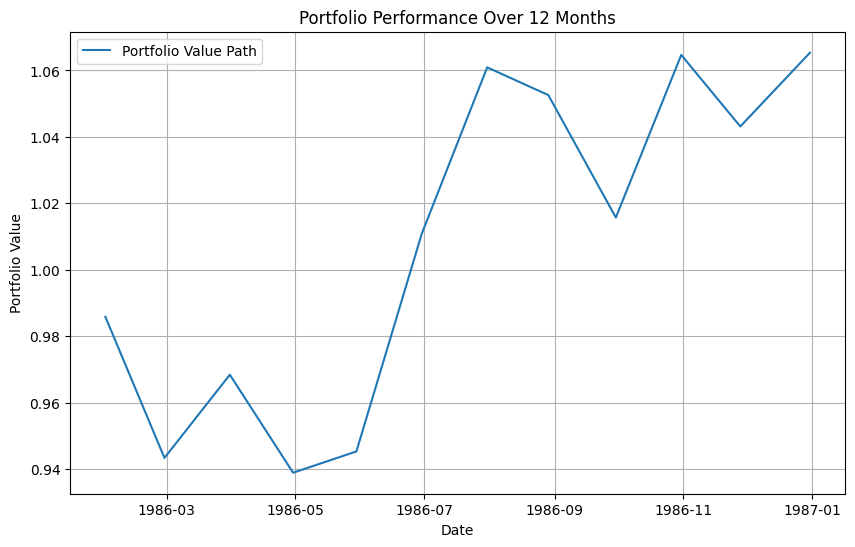


=== Segment 4 ===
Decision date (t0 in R_all_unwindowed): 1985-12-31T00:00:00.000000000
Eval window dates: ['1986-01-31T00:00:00.000000000' '1986-02-28T00:00:00.000000000'
 '1986-03-31T00:00:00.000000000' '1986-04-30T00:00:00.000000000'
 '1986-05-30T00:00:00.000000000' '1986-06-30T00:00:00.000000000'
 '1986-07-31T00:00:00.000000000' '1986-08-29T00:00:00.000000000'
 '1986-09-30T00:00:00.000000000' '1986-10-31T00:00:00.000000000'
 '1986-11-28T00:00:00.000000000' '1986-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.06535027604768606
Volatility: 0.20515493
Sharpe Ratio: 0.3185411018595114

=== Segment (1986 → 1987) ===
Decision date: 1986-12-31T00:00:00.000000000
Eval window dates: ['1987-01-30T00:00:00.000000000' '1987-02-27T00:00:00.000000000'
 '1987-03-31T00:00:00.000000000' '1987-04-30T00:00:00.000000000'
 '1987-05-29T00:00:00.000000000' '1987-06-30T00:00:00.000000000'
 '1987-07-31T00:00:00.000000000' '1987-08-31T00:00:00.000000000'
 '1987-09-30T00:00:00.000000000' '1987-10-3

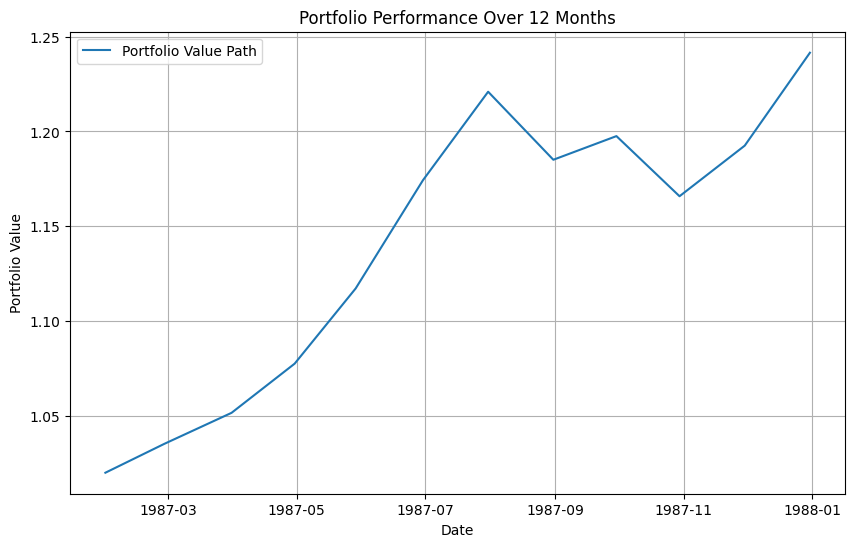


=== Segment 5 ===
Decision date (t0 in R_all_unwindowed): 1986-12-31T00:00:00.000000000
Eval window dates: ['1987-01-30T00:00:00.000000000' '1987-02-27T00:00:00.000000000'
 '1987-03-31T00:00:00.000000000' '1987-04-30T00:00:00.000000000'
 '1987-05-29T00:00:00.000000000' '1987-06-30T00:00:00.000000000'
 '1987-07-31T00:00:00.000000000' '1987-08-31T00:00:00.000000000'
 '1987-09-30T00:00:00.000000000' '1987-10-30T00:00:00.000000000'
 '1987-11-30T00:00:00.000000000' '1987-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.24154501857437416
Volatility: 0.2373118
Sharpe Ratio: 1.0178382335111995

=== Segment (1987 → 1988) ===
Decision date: 1987-12-31T00:00:00.000000000
Eval window dates: ['1988-01-29T00:00:00.000000000' '1988-02-29T00:00:00.000000000'
 '1988-03-31T00:00:00.000000000' '1988-04-29T00:00:00.000000000'
 '1988-05-31T00:00:00.000000000' '1988-06-30T00:00:00.000000000'
 '1988-07-29T00:00:00.000000000' '1988-08-31T00:00:00.000000000'
 '1988-09-30T00:00:00.000000000' '1988-10-31

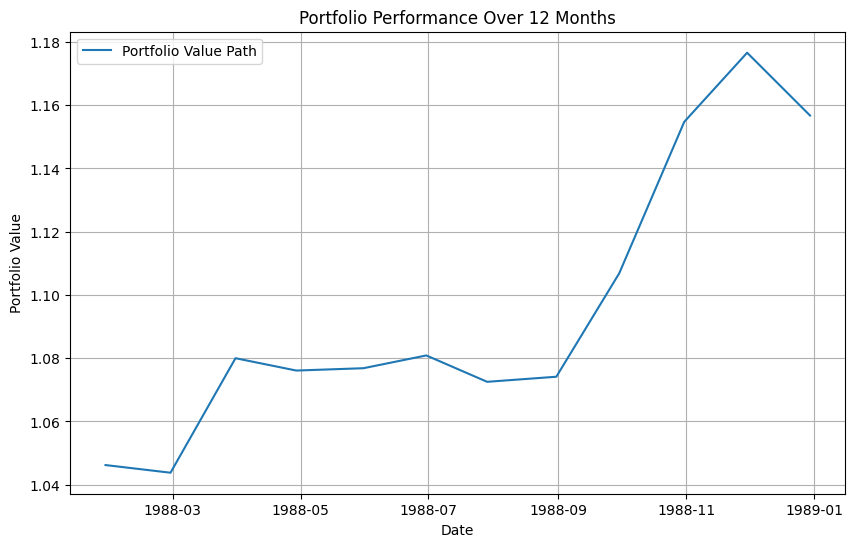


=== Segment 6 ===
Decision date (t0 in R_all_unwindowed): 1987-12-31T00:00:00.000000000
Eval window dates: ['1988-01-29T00:00:00.000000000' '1988-02-29T00:00:00.000000000'
 '1988-03-31T00:00:00.000000000' '1988-04-29T00:00:00.000000000'
 '1988-05-31T00:00:00.000000000' '1988-06-30T00:00:00.000000000'
 '1988-07-29T00:00:00.000000000' '1988-08-31T00:00:00.000000000'
 '1988-09-30T00:00:00.000000000' '1988-10-31T00:00:00.000000000'
 '1988-11-30T00:00:00.000000000' '1988-12-30T00:00:00.000000000']
Portfolio 12-month Return: 0.15672141105650783
Volatility: 0.19576477
Sharpe Ratio: 0.800559850194247

=== Segment (1988 → 1989) ===
Decision date: 1988-12-30T00:00:00.000000000
Eval window dates: ['1989-01-31T00:00:00.000000000' '1989-02-28T00:00:00.000000000'
 '1989-03-31T00:00:00.000000000' '1989-04-28T00:00:00.000000000'
 '1989-05-31T00:00:00.000000000' '1989-06-30T00:00:00.000000000'
 '1989-07-31T00:00:00.000000000' '1989-08-31T00:00:00.000000000'
 '1989-09-29T00:00:00.000000000' '1989-10-31

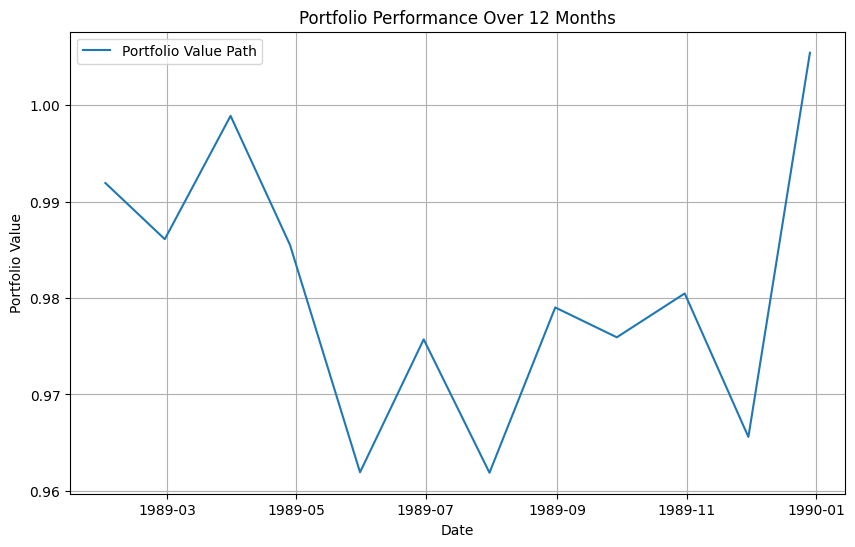


=== Segment 7 ===
Decision date (t0 in R_all_unwindowed): 1988-12-30T00:00:00.000000000
Eval window dates: ['1989-01-31T00:00:00.000000000' '1989-02-28T00:00:00.000000000'
 '1989-03-31T00:00:00.000000000' '1989-04-28T00:00:00.000000000'
 '1989-05-31T00:00:00.000000000' '1989-06-30T00:00:00.000000000'
 '1989-07-31T00:00:00.000000000' '1989-08-31T00:00:00.000000000'
 '1989-09-29T00:00:00.000000000' '1989-10-31T00:00:00.000000000'
 '1989-11-30T00:00:00.000000000' '1989-12-29T00:00:00.000000000']
Portfolio 12-month Return: 0.005447979636061362
Volatility: 0.25079584
Sharpe Ratio: 0.021722767050776692

=== Segment (1989 → 1990) ===
Decision date: 1989-12-29T00:00:00.000000000
Eval window dates: ['1990-01-31T00:00:00.000000000' '1990-02-28T00:00:00.000000000'
 '1990-03-30T00:00:00.000000000' '1990-04-30T00:00:00.000000000'
 '1990-05-31T00:00:00.000000000' '1990-06-29T00:00:00.000000000'
 '1990-07-31T00:00:00.000000000' '1990-08-31T00:00:00.000000000'
 '1990-09-28T00:00:00.000000000' '1990-1

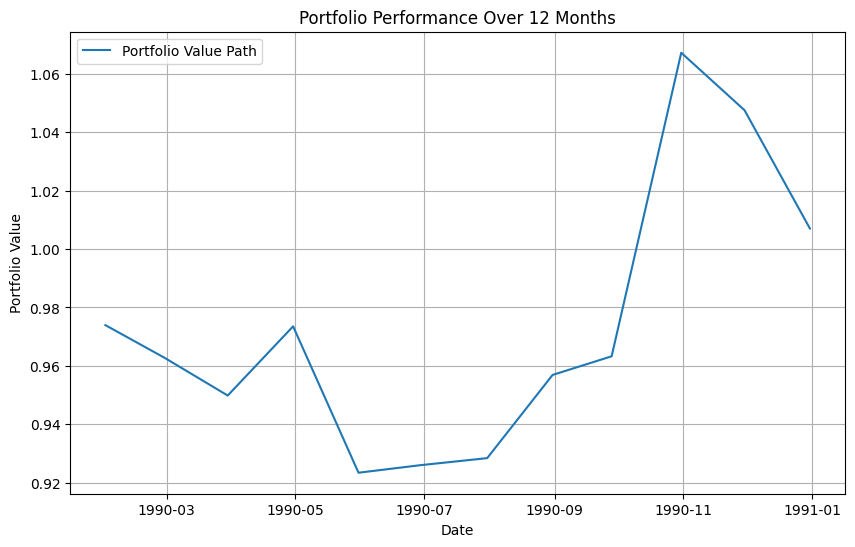


=== Segment 8 ===
Decision date (t0 in R_all_unwindowed): 1989-12-29T00:00:00.000000000
Eval window dates: ['1990-01-31T00:00:00.000000000' '1990-02-28T00:00:00.000000000'
 '1990-03-30T00:00:00.000000000' '1990-04-30T00:00:00.000000000'
 '1990-05-31T00:00:00.000000000' '1990-06-29T00:00:00.000000000'
 '1990-07-31T00:00:00.000000000' '1990-08-31T00:00:00.000000000'
 '1990-09-28T00:00:00.000000000' '1990-10-31T00:00:00.000000000'
 '1990-11-30T00:00:00.000000000' '1990-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.006981353583263905
Volatility: 0.18253371
Sharpe Ratio: 0.0382469273076142

=== Segment (1990 → 1991) ===
Decision date: 1990-12-31T00:00:00.000000000
Eval window dates: ['1991-01-31T00:00:00.000000000' '1991-02-28T00:00:00.000000000'
 '1991-03-28T00:00:00.000000000' '1991-04-30T00:00:00.000000000'
 '1991-05-31T00:00:00.000000000' '1991-06-28T00:00:00.000000000'
 '1991-07-31T00:00:00.000000000' '1991-08-30T00:00:00.000000000'
 '1991-09-30T00:00:00.000000000' '1991-10-

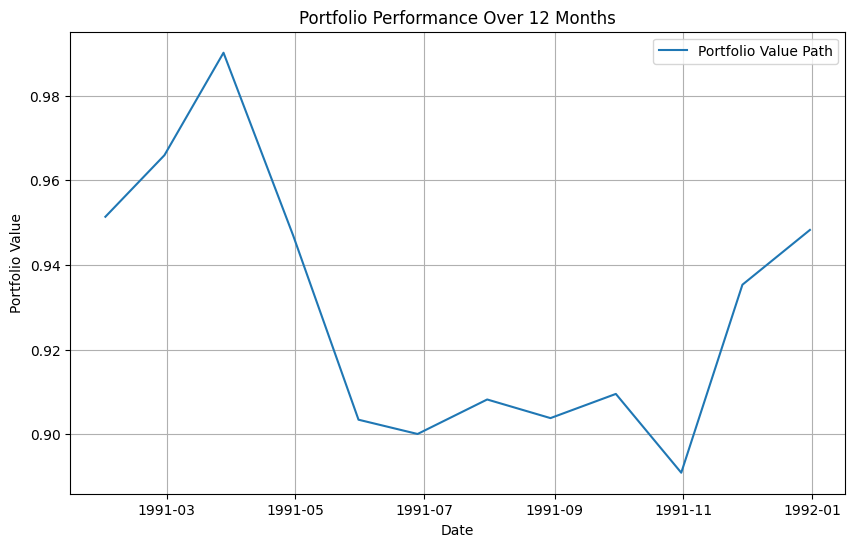


=== Segment 9 ===
Decision date (t0 in R_all_unwindowed): 1990-12-31T00:00:00.000000000
Eval window dates: ['1991-01-31T00:00:00.000000000' '1991-02-28T00:00:00.000000000'
 '1991-03-28T00:00:00.000000000' '1991-04-30T00:00:00.000000000'
 '1991-05-31T00:00:00.000000000' '1991-06-28T00:00:00.000000000'
 '1991-07-31T00:00:00.000000000' '1991-08-30T00:00:00.000000000'
 '1991-09-30T00:00:00.000000000' '1991-10-31T00:00:00.000000000'
 '1991-11-29T00:00:00.000000000' '1991-12-31T00:00:00.000000000']
Portfolio 12-month Return: -0.05173223894955825
Volatility: 0.29169202
Sharpe Ratio: -0.17735226083321112

=== Segment (1991 → 1992) ===
Decision date: 1991-12-31T00:00:00.000000000
Eval window dates: ['1992-01-31T00:00:00.000000000' '1992-02-28T00:00:00.000000000'
 '1992-03-31T00:00:00.000000000' '1992-04-30T00:00:00.000000000'
 '1992-05-29T00:00:00.000000000' '1992-06-30T00:00:00.000000000'
 '1992-07-31T00:00:00.000000000' '1992-08-31T00:00:00.000000000'
 '1992-09-30T00:00:00.000000000' '1992-1

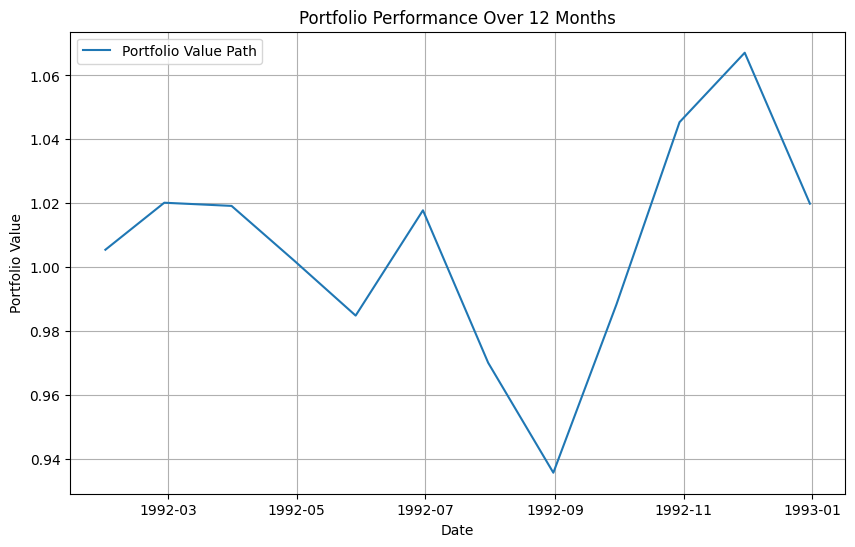


=== Segment 10 ===
Decision date (t0 in R_all_unwindowed): 1991-12-31T00:00:00.000000000
Eval window dates: ['1992-01-31T00:00:00.000000000' '1992-02-28T00:00:00.000000000'
 '1992-03-31T00:00:00.000000000' '1992-04-30T00:00:00.000000000'
 '1992-05-29T00:00:00.000000000' '1992-06-30T00:00:00.000000000'
 '1992-07-31T00:00:00.000000000' '1992-08-31T00:00:00.000000000'
 '1992-09-30T00:00:00.000000000' '1992-10-30T00:00:00.000000000'
 '1992-11-30T00:00:00.000000000' '1992-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.019889238719733582
Volatility: 0.2200926
Sharpe Ratio: 0.09036759620990904

=== Segment (1992 → 1993) ===
Decision date: 1992-12-31T00:00:00.000000000
Eval window dates: ['1993-01-29T00:00:00.000000000' '1993-02-26T00:00:00.000000000'
 '1993-03-31T00:00:00.000000000' '1993-04-30T00:00:00.000000000'
 '1993-05-28T00:00:00.000000000' '1993-06-30T00:00:00.000000000'
 '1993-07-30T00:00:00.000000000' '1993-08-31T00:00:00.000000000'
 '1993-09-30T00:00:00.000000000' '1993-10

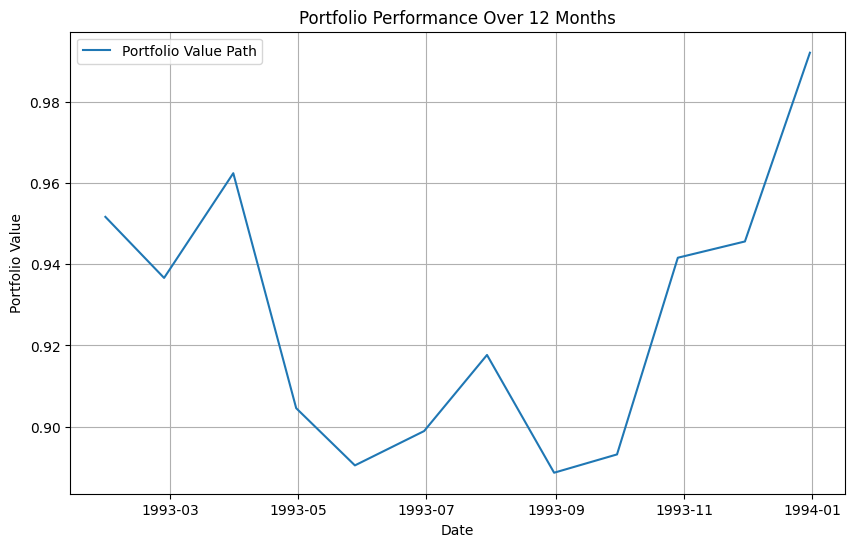


=== Segment 11 ===
Decision date (t0 in R_all_unwindowed): 1992-12-31T00:00:00.000000000
Eval window dates: ['1993-01-29T00:00:00.000000000' '1993-02-26T00:00:00.000000000'
 '1993-03-31T00:00:00.000000000' '1993-04-30T00:00:00.000000000'
 '1993-05-28T00:00:00.000000000' '1993-06-30T00:00:00.000000000'
 '1993-07-30T00:00:00.000000000' '1993-08-31T00:00:00.000000000'
 '1993-09-30T00:00:00.000000000' '1993-10-29T00:00:00.000000000'
 '1993-11-30T00:00:00.000000000' '1993-12-31T00:00:00.000000000']
Portfolio 12-month Return: -0.007884454614747516
Volatility: 0.21772072
Sharpe Ratio: -0.03621361676760188

=== Segment (1993 → 1994) ===
Decision date: 1993-12-31T00:00:00.000000000
Eval window dates: ['1994-01-31T00:00:00.000000000' '1994-02-28T00:00:00.000000000'
 '1994-03-31T00:00:00.000000000' '1994-04-29T00:00:00.000000000'
 '1994-05-31T00:00:00.000000000' '1994-06-30T00:00:00.000000000'
 '1994-07-29T00:00:00.000000000' '1994-08-31T00:00:00.000000000'
 '1994-09-30T00:00:00.000000000' '1994

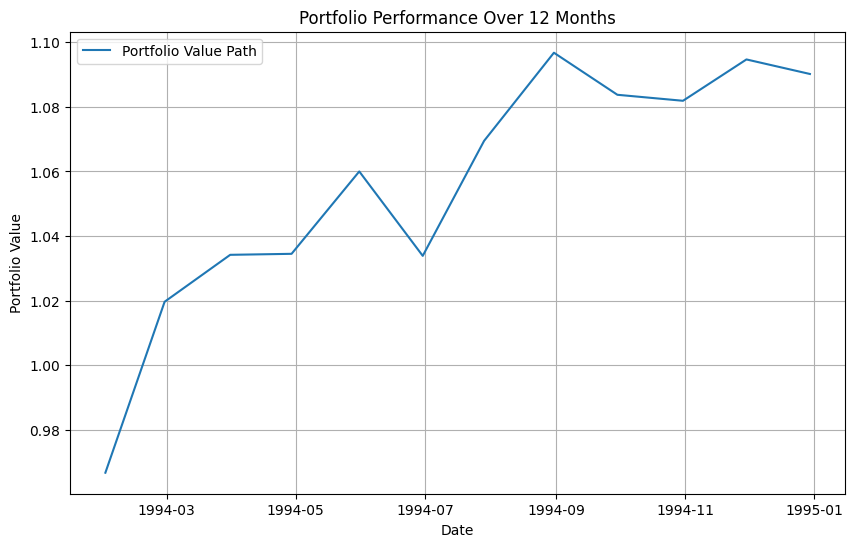


=== Segment 12 ===
Decision date (t0 in R_all_unwindowed): 1993-12-31T00:00:00.000000000
Eval window dates: ['1994-01-31T00:00:00.000000000' '1994-02-28T00:00:00.000000000'
 '1994-03-31T00:00:00.000000000' '1994-04-29T00:00:00.000000000'
 '1994-05-31T00:00:00.000000000' '1994-06-30T00:00:00.000000000'
 '1994-07-29T00:00:00.000000000' '1994-08-31T00:00:00.000000000'
 '1994-09-30T00:00:00.000000000' '1994-10-31T00:00:00.000000000'
 '1994-11-30T00:00:00.000000000' '1994-12-30T00:00:00.000000000']
Portfolio 12-month Return: 0.09016764775730457
Volatility: 0.15653285
Sharpe Ratio: 0.5760301786131309

=== Segment (1994 → 1995) ===
Decision date: 1994-12-30T00:00:00.000000000
Eval window dates: ['1995-01-31T00:00:00.000000000' '1995-02-28T00:00:00.000000000'
 '1995-03-31T00:00:00.000000000' '1995-04-28T00:00:00.000000000'
 '1995-05-31T00:00:00.000000000' '1995-06-30T00:00:00.000000000'
 '1995-07-31T00:00:00.000000000' '1995-08-31T00:00:00.000000000'
 '1995-09-29T00:00:00.000000000' '1995-10-

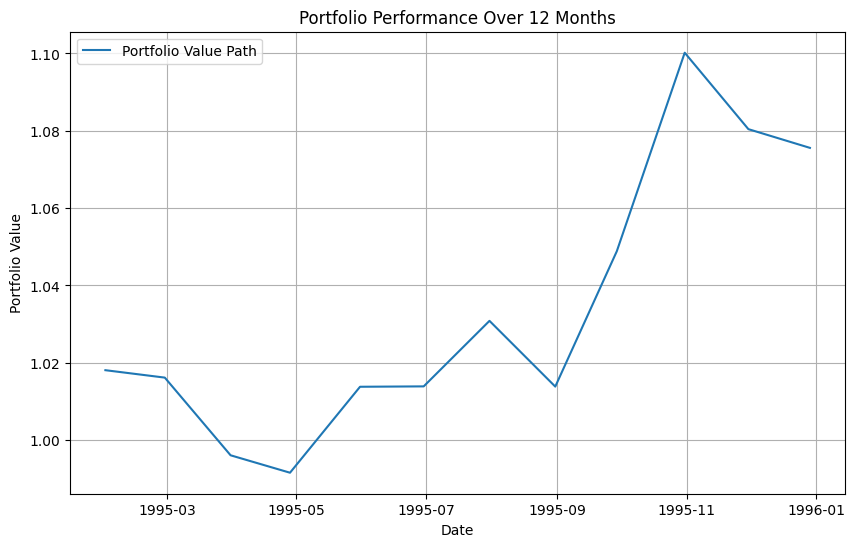


=== Segment 13 ===
Decision date (t0 in R_all_unwindowed): 1994-12-30T00:00:00.000000000
Eval window dates: ['1995-01-31T00:00:00.000000000' '1995-02-28T00:00:00.000000000'
 '1995-03-31T00:00:00.000000000' '1995-04-28T00:00:00.000000000'
 '1995-05-31T00:00:00.000000000' '1995-06-30T00:00:00.000000000'
 '1995-07-31T00:00:00.000000000' '1995-08-31T00:00:00.000000000'
 '1995-09-29T00:00:00.000000000' '1995-10-31T00:00:00.000000000'
 '1995-11-30T00:00:00.000000000' '1995-12-29T00:00:00.000000000']
Portfolio 12-month Return: 0.07558028105991133
Volatility: 0.2052011
Sharpe Ratio: 0.36832297430306876

=== Segment (1995 → 1996) ===
Decision date: 1995-12-29T00:00:00.000000000
Eval window dates: ['1996-01-31T00:00:00.000000000' '1996-02-29T00:00:00.000000000'
 '1996-03-29T00:00:00.000000000' '1996-04-30T00:00:00.000000000'
 '1996-05-31T00:00:00.000000000' '1996-06-28T00:00:00.000000000'
 '1996-07-31T00:00:00.000000000' '1996-08-30T00:00:00.000000000'
 '1996-09-30T00:00:00.000000000' '1996-10-

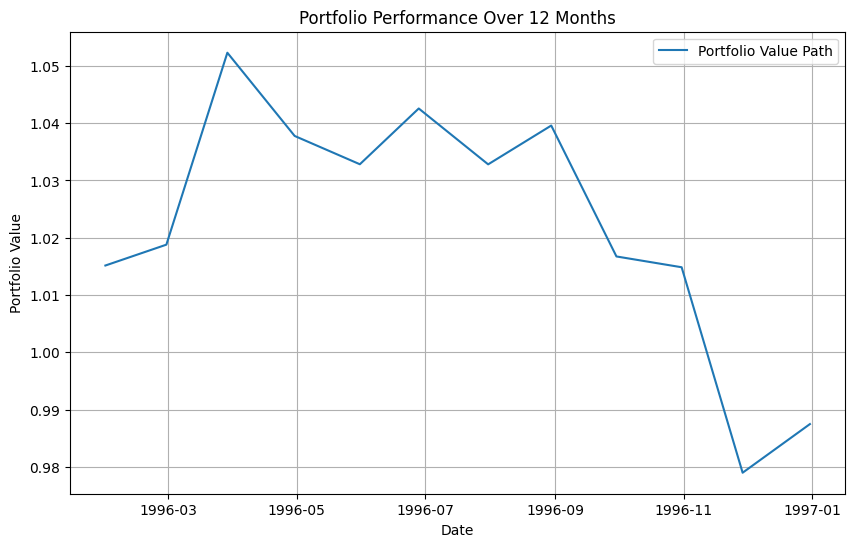


=== Segment 14 ===
Decision date (t0 in R_all_unwindowed): 1995-12-29T00:00:00.000000000
Eval window dates: ['1996-01-31T00:00:00.000000000' '1996-02-29T00:00:00.000000000'
 '1996-03-29T00:00:00.000000000' '1996-04-30T00:00:00.000000000'
 '1996-05-31T00:00:00.000000000' '1996-06-28T00:00:00.000000000'
 '1996-07-31T00:00:00.000000000' '1996-08-30T00:00:00.000000000'
 '1996-09-30T00:00:00.000000000' '1996-10-31T00:00:00.000000000'
 '1996-11-29T00:00:00.000000000' '1996-12-31T00:00:00.000000000']
Portfolio 12-month Return: -0.012509621919759684
Volatility: 0.18566896
Sharpe Ratio: -0.06737594644448948

=== Segment (1996 → 1997) ===
Decision date: 1996-12-31T00:00:00.000000000
Eval window dates: ['1997-01-31T00:00:00.000000000' '1997-02-28T00:00:00.000000000'
 '1997-03-31T00:00:00.000000000' '1997-04-30T00:00:00.000000000'
 '1997-05-30T00:00:00.000000000' '1997-06-30T00:00:00.000000000'
 '1997-07-31T00:00:00.000000000' '1997-08-29T00:00:00.000000000'
 '1997-09-30T00:00:00.000000000' '1997

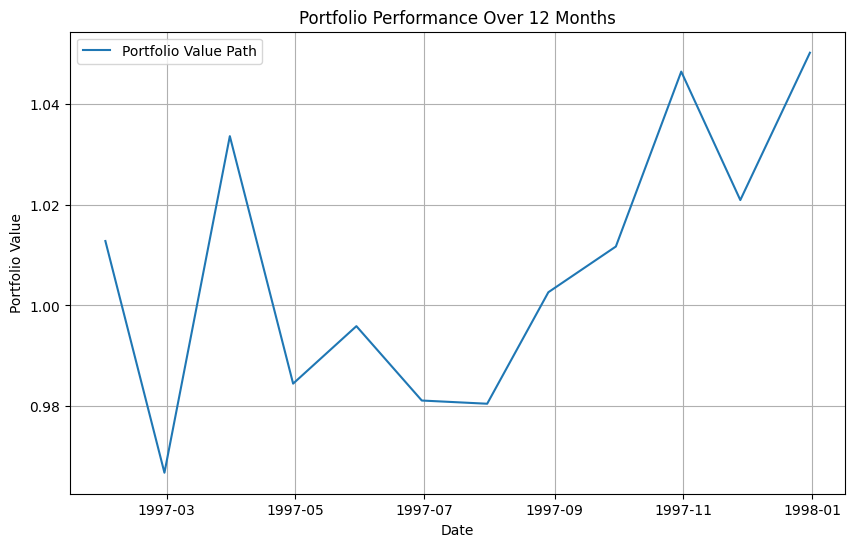


=== Segment 15 ===
Decision date (t0 in R_all_unwindowed): 1996-12-31T00:00:00.000000000
Eval window dates: ['1997-01-31T00:00:00.000000000' '1997-02-28T00:00:00.000000000'
 '1997-03-31T00:00:00.000000000' '1997-04-30T00:00:00.000000000'
 '1997-05-30T00:00:00.000000000' '1997-06-30T00:00:00.000000000'
 '1997-07-31T00:00:00.000000000' '1997-08-29T00:00:00.000000000'
 '1997-09-30T00:00:00.000000000' '1997-10-31T00:00:00.000000000'
 '1997-11-28T00:00:00.000000000' '1997-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.05012526917462834
Volatility: 0.22327279
Sharpe Ratio: 0.2245023684924711

=== Segment (1997 → 1998) ===
Decision date: 1997-12-31T00:00:00.000000000
Eval window dates: ['1998-01-30T00:00:00.000000000' '1998-02-27T00:00:00.000000000'
 '1998-03-31T00:00:00.000000000' '1998-04-30T00:00:00.000000000'
 '1998-05-29T00:00:00.000000000' '1998-06-30T00:00:00.000000000'
 '1998-07-31T00:00:00.000000000' '1998-08-31T00:00:00.000000000'
 '1998-09-30T00:00:00.000000000' '1998-10-

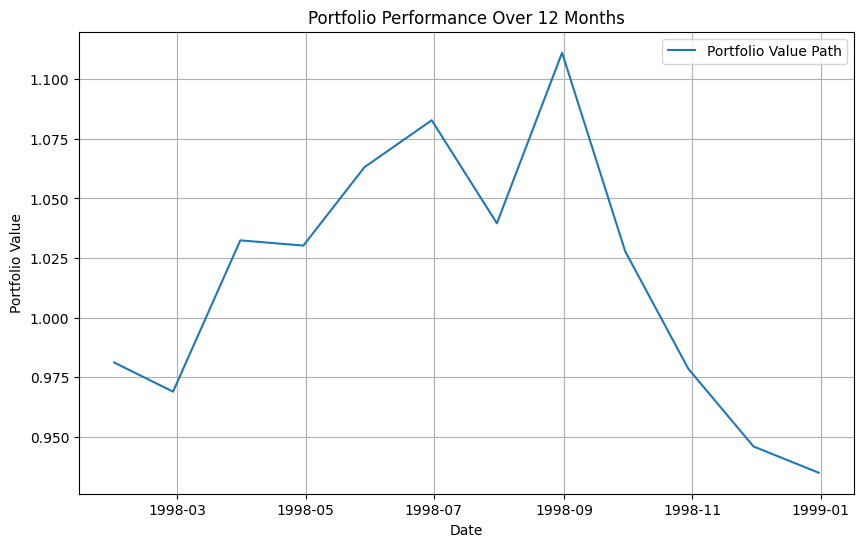


=== Segment 16 ===
Decision date (t0 in R_all_unwindowed): 1997-12-31T00:00:00.000000000
Eval window dates: ['1998-01-30T00:00:00.000000000' '1998-02-27T00:00:00.000000000'
 '1998-03-31T00:00:00.000000000' '1998-04-30T00:00:00.000000000'
 '1998-05-29T00:00:00.000000000' '1998-06-30T00:00:00.000000000'
 '1998-07-31T00:00:00.000000000' '1998-08-31T00:00:00.000000000'
 '1998-09-30T00:00:00.000000000' '1998-10-30T00:00:00.000000000'
 '1998-11-30T00:00:00.000000000' '1998-12-31T00:00:00.000000000']
Portfolio 12-month Return: -0.06508446641692478
Volatility: 0.31011975
Sharpe Ratio: -0.20986882264807152

=== Segment (1998 → 1999) ===
Decision date: 1998-12-31T00:00:00.000000000
Eval window dates: ['1999-01-29T00:00:00.000000000' '1999-02-26T00:00:00.000000000'
 '1999-03-31T00:00:00.000000000' '1999-04-30T00:00:00.000000000'
 '1999-05-28T00:00:00.000000000' '1999-06-30T00:00:00.000000000'
 '1999-07-30T00:00:00.000000000' '1999-08-31T00:00:00.000000000'
 '1999-09-30T00:00:00.000000000' '1999-

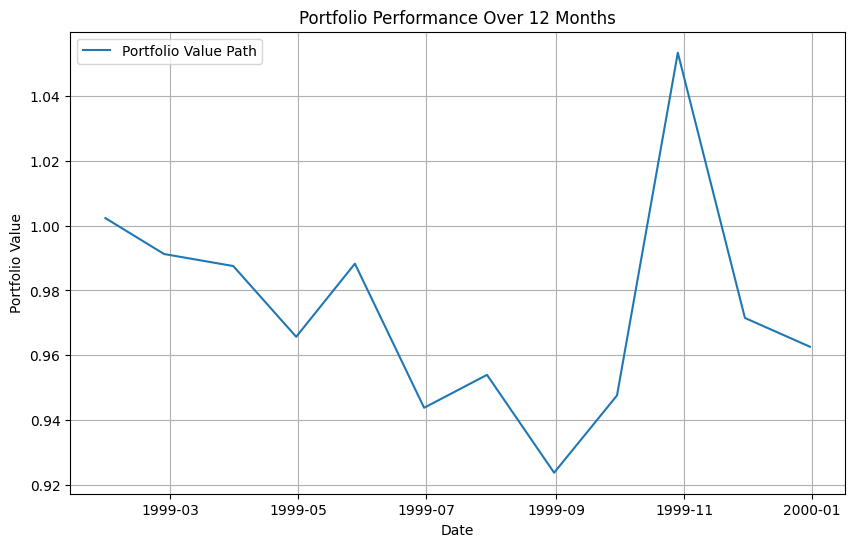


=== Segment 17 ===
Decision date (t0 in R_all_unwindowed): 1998-12-31T00:00:00.000000000
Eval window dates: ['1999-01-29T00:00:00.000000000' '1999-02-26T00:00:00.000000000'
 '1999-03-31T00:00:00.000000000' '1999-04-30T00:00:00.000000000'
 '1999-05-28T00:00:00.000000000' '1999-06-30T00:00:00.000000000'
 '1999-07-30T00:00:00.000000000' '1999-08-31T00:00:00.000000000'
 '1999-09-30T00:00:00.000000000' '1999-10-29T00:00:00.000000000'
 '1999-11-30T00:00:00.000000000' '1999-12-31T00:00:00.000000000']
Portfolio 12-month Return: -0.0373608637277828
Volatility: 0.46737072
Sharpe Ratio: -0.07993839201201519

=== Segment (1999 → 2000) ===
Decision date: 1999-12-31T00:00:00.000000000
Eval window dates: ['2000-01-31T00:00:00.000000000' '2000-02-29T00:00:00.000000000'
 '2000-03-31T00:00:00.000000000' '2000-04-28T00:00:00.000000000'
 '2000-05-31T00:00:00.000000000' '2000-06-30T00:00:00.000000000'
 '2000-07-31T00:00:00.000000000' '2000-08-31T00:00:00.000000000'
 '2000-09-29T00:00:00.000000000' '2000-1

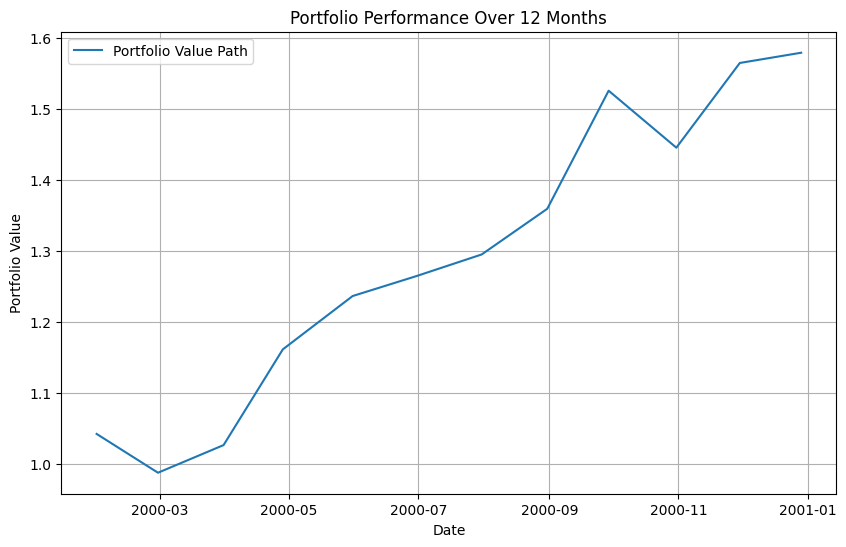


=== Segment 18 ===
Decision date (t0 in R_all_unwindowed): 1999-12-31T00:00:00.000000000
Eval window dates: ['2000-01-31T00:00:00.000000000' '2000-02-29T00:00:00.000000000'
 '2000-03-31T00:00:00.000000000' '2000-04-28T00:00:00.000000000'
 '2000-05-31T00:00:00.000000000' '2000-06-30T00:00:00.000000000'
 '2000-07-31T00:00:00.000000000' '2000-08-31T00:00:00.000000000'
 '2000-09-29T00:00:00.000000000' '2000-10-31T00:00:00.000000000'
 '2000-11-30T00:00:00.000000000' '2000-12-29T00:00:00.000000000']
Portfolio 12-month Return: 0.5794396341346872
Volatility: 0.3606431
Sharpe Ratio: 1.6066844259637323

--- Overall Results ---
Average Portfolio Return: 0.0424031647410561
Average Sharpe Ratio: 0.3466829660105524
Average Volatility: 0.146995169151248


In [36]:
import numpy
# get monthly sequences
# window = 12
# X_val_seq, R_val_seq, companies_val, dates_val = make_monthly_sequences(
#     validation_df,
#      window=window,
#     feature_cols=[
#         "volume",
#         "dividend_cash_amount",
#         "pe_ratio",
#         "shares_out_thousands",
#         "book_to_market_value",
#         "finegrained_volatility_12m",
#     ],
#     target_col="return_ex_div",
#     company_col="company_name",
#     date_col="date",)
# years = np.sort(pd.DatetimeIndex(dates_actual).year.unique())
horizon = 12

results = []
all_portfolio_returns = []
all_portfolio_sharpe_ratios = []

# Re-initialize years for the full validation period for the loop
years = np.sort(pd.DatetimeIndex(dates_actual).year.unique())

# Loop over pairs of years
for i in range(0, len(years) - 1, 1):
    y_hist = years[i]
    y_eval = years[i + 1]

    # --- indices for these years on the global time axis ---
    years_all = pd.DatetimeIndex(dates_actual).year.values

    hist_mask = (years_all == y_hist)
    eval_mask = (years_all == y_eval)

    if hist_mask.sum() < window or eval_mask.sum() < horizon:
        print(f"Skipping pair ({y_hist}, {y_eval}) – not enough months")
        continue

    # index of last month of history year (decision time)
    t0 = np.where(hist_mask)[0][-1]   # decision at end of Year y_hist

    # index of first month of eval year
    eval_start_idx = np.where(eval_mask)[0][0]

    # consistency check: eval starts right after history ends (or close)
    if eval_start_idx != t0 + 1:
        print(f"Warning: eval_start_idx != t0+1 for ({y_hist}, {y_eval})")

    # --- choose the correct sequence window for the policy ---
    # X_val_seq[b] covers months [b, b+window-1]
    # We want the sequence whose *last* month is t0 → b = t0 - (window-1)
    seq_idx_full = t0 - (window - 1)

    # To index into X_val_seq, we need a relative index
    seq_idx_relative = seq_idx_full # 'cut' is from the previous cell, separating X_val_seq_1 and X_val_seq_2

    if seq_idx_relative < 0 or seq_idx_relative >= X_val_seq.shape[0]:
        print(f"Skipping pair ({y_hist}, {y_eval}) – required sequence for evaluation is not in X_val_seq_2 (index {seq_idx_relative} out of range {X_val_seq_2.shape[0]}) ")
        continue

    X_seq_segment = X_val_seq[seq_idx_relative : seq_idx_relative + 1]   # [1, window, I, F]
    R_seq_segment = R_val_seq[seq_idx_relative : seq_idx_relative + 1]

    # --- get long/short picks from the trained policy ---
    (
        long_companies, long_weights, long_indices,
        short_companies, short_weights, short_indices,
    ) = get_next_month_picks(
        trainer,
        X_seq_segment,
        R_seq_segment,
        companies_actual,   # full company list, indices align with R_all_unwindowed
        num_assets=10,
    )

    # --- buy and hold for the *next year* (y_eval) ---
    asset_ret_12m, value_path, port_12m, w_full = buy_and_hold_long_short(
        R_all_unwindowed,
        t0=t0,                           # decision at end of history year
        long_indices=long_indices,
        long_weights=long_weights,
        short_indices=short_indices,
        short_weights=short_weights,
        horizon=horizon,
    )

    # Sharpe etc.
    volatility = np.std(asset_ret_12m)
    sharpe_ratio = port_12m / volatility if volatility > 0 else np.nan

    print(f"\n=== Segment ({y_hist} → {y_eval}) ===")
    print("Decision date:", dates_actual[t0])
    print("Eval window dates:", dates_actual[t0+1 : t0+1+horizon])
    print("Portfolio 12m Return:", port_12m)
    print("Volatility:", volatility)
    print("Sharpe Ratio:", sharpe_ratio)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(dates_actual[t0+1 : t0+1+horizon], value_path, label='Portfolio Value Path') # Corrected x-axis for value_path
    ax.set_xlabel('Date')
    ax.set_ylabel('Portfolio Value')
    ax.set_title('Portfolio Performance Over 12 Months')
    ax.legend()
    plt.grid(True)
    plt.show()

    results.append({
        "hist_year": int(y_hist),
        "eval_year": int(y_eval),
        "port_12m": float(port_12m),
        "vol": float(volatility),
        "sharpe": float(sharpe_ratio),
    })



    print(f"\n=== Segment {i} ===")
    print("Decision date (t0 in R_all_unwindowed):", dates_actual[t0] if t0 < len(dates_actual) else "N/A")
    print("Eval window dates:", dates_actual[t0+1 : t0+1+horizon])
    print("Portfolio 12-month Return:", port_12m)
    all_portfolio_returns.append(port_12m)

    # Only compute volatility if asset_ret_12m is not scalar or None/nan
    if isinstance(asset_ret_12m, np.ndarray) and asset_ret_12m.size > 1 and not np.isnan(asset_ret_12m).all():
        volatility = np.std(asset_ret_12m)
        print("Volatility:", volatility)
        sharpe_ratio = port_12m / volatility if volatility > 0 else np.nan
        print("Sharpe Ratio:", sharpe_ratio)
        all_portfolio_sharpe_ratios.append(sharpe_ratio)
    else:
        print("Volatility: N/A (insufficient asset returns)")
        print("Sharpe Ratio: N/A")
        all_portfolio_sharpe_ratios.append(np.nan)

# Print overall average results
print("\n--- Overall Results ---")
print("Average Portfolio Return:", np.prod((1+numpy.array(all_portfolio_returns)) ** (1 / len(all_portfolio_returns))) - 1)
print("Average Sharpe Ratio:", np.nanmean(numpy.array(all_portfolio_returns))/ numpy.nanstd(numpy.array(all_portfolio_returns)))
print("Average Volatility:", np.nanstd(numpy.array(all_portfolio_returns)))


In [38]:
import numpy as np

def simulate_from_weight_sequence(
    R_all,
    w_seq,
    cost: float = 0.0,
    start_value: float = 1.0,
    start_t: int = 0,
):
    """
    R_all : [T, I]  array of simple returns
    w_seq: [K, I]   weight vectors for each step
    cost  : transaction cost per unit turnover
    start_value: initial portfolio value
    start_t: index in R_all where the first step starts
    """
    R_all = np.asarray(R_all, dtype=float)   # [T, I]
    w_seq = np.asarray(w_seq, dtype=float)   # [K, I]

    T, I = R_all.shape
    K = w_seq.shape[0]

    values = [start_value]
    r_net_list = []
    turnover_list = []

    # start flat (all cash)
    w_prev = np.zeros(I, dtype=float)

    for step in range(K):
        t = start_t + step  # time index in R_all

        if t >= T:
            break

        w_t = w_seq[step]   # weights for this period

        # portfolio return using THESE weights in this period
        r_t = np.dot(w_t, R_all[t, :])

        # turnover cost from w_prev -> w_t (buy/sell)
        turnover_t = np.sum(np.abs(w_t - w_prev))
        r_t_net = r_t - cost * turnover_t

        new_value = values[-1] * (1.0 + r_t_net)

        values.append(new_value)
        r_net_list.append(r_t_net)
        turnover_list.append(turnover_t)

        # new weights become "previous" for next step
        w_prev = w_t

    return np.array(values), np.array(r_net_list), np.array(turnover_list)



=== Segment (1999 → 2000) ===
Decision date: 1999-12-31T00:00:00.000000000
Eval window dates: ['2000-01-31T00:00:00.000000000' '2000-02-29T00:00:00.000000000'
 '2000-03-31T00:00:00.000000000' '2000-04-28T00:00:00.000000000'
 '2000-05-31T00:00:00.000000000' '2000-06-30T00:00:00.000000000'
 '2000-07-31T00:00:00.000000000' '2000-08-31T00:00:00.000000000'
 '2000-09-29T00:00:00.000000000' '2000-10-31T00:00:00.000000000'
 '2000-11-30T00:00:00.000000000' '2000-12-29T00:00:00.000000000']
Portfolio 12m Return: 0.2642326722713515
Sharpe Ratio: 2.531293910096506


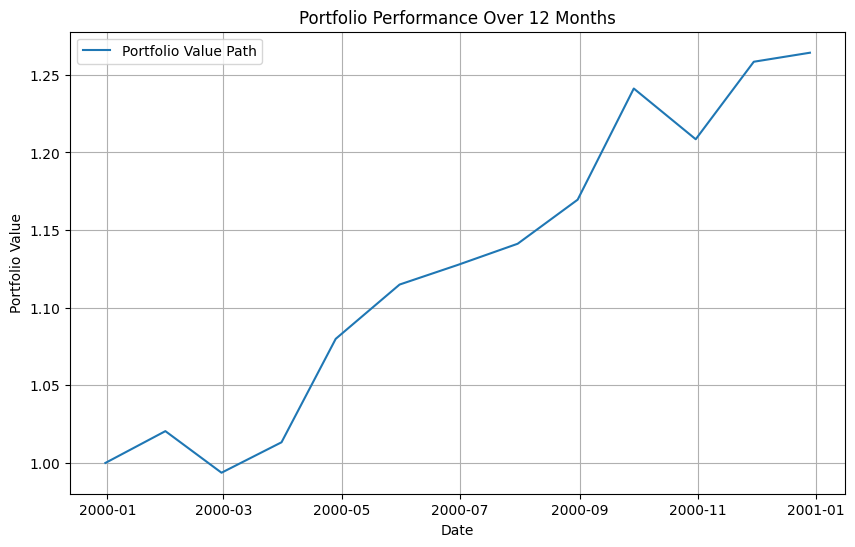

In [39]:
# dynamic weights
(
        long_companies, long_weights, long_indices,
        short_companies, short_weights, short_indices,
    ) = get_next_month_picks(
        trainer,
        X_seq_segment,
        R_seq_segment,
        companies_actual,
        num_assets=10,
    )

I = R_all_unwindowed.shape[1]
w0 = np.zeros(I, dtype=float)

# longs: positive
if long_indices.size > 0:
    w0[long_indices] += long_weights

# shorts: negative
if short_indices.size > 0:
    w0[short_indices] -= short_weights

# optional: normalize gross exposure so sum(|w|)=1
gross = np.sum(np.abs(w0))
if gross > 0:
    w0 = w0 / gross

# build weight sequence over the horizon:
# we rebalance at t0, then hold same weights for 12 months (no further rebal)
K = horizon
w_seq = np.tile(w0[None, :], (K, 1))   # [horizon, I]

# first return month is t0+1 (after decision at end of y_hist)
start_t = t0 + 1

# simulate portfolio over next 12 months
values, r_net, turnover_seq = simulate_from_weight_sequence(
    R_all_unwindowed,
    w_seq=w_seq,
    cost=5e-4,         # or whatever cost you use
    start_value=1.0,
    start_t=start_t,
)

# portfolio 12-month return
port_12m = values[-1] - 1.0
value_path = values  # length horizon+1

# Sharpe using monthly net returns r_net
if r_net.size > 1 and not np.isnan(r_net).all():
    r_mean = np.mean(r_net)
    r_std = np.std(r_net)
    sharpe_ratio = (r_mean / r_std) * np.sqrt(12) if r_std > 0 else np.nan
else:
    sharpe_ratio = np.nan
print(f"\n=== Segment ({y_hist} → {y_eval}) ===")
print("Decision date:", dates_actual[t0])
print("Eval window dates:", dates_actual[start_t : start_t + horizon])
print("Portfolio 12m Return:", port_12m)
print("Sharpe Ratio:", sharpe_ratio)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dates_actual[t0 : t0 + horizon + 1], value_path,
        label='Portfolio Value Path')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value')
ax.set_title('Portfolio Performance Over 12 Months')
ax.legend()
plt.grid(True)
plt.show()

results.append({
    "hist_year": int(y_hist),
    "eval_year": int(y_eval),
    "port_12m": float(port_12m),
    "sharpe": float(sharpe_ratio),
})

all_portfolio_returns.append(port_12m)
all_portfolio_sharpe_ratios.append(sharpe_ratio)


Finetuning the model using the validation set.

Selecting to work with a tensorflow Actor policy since it supports a deterministic choice over a distribution of actions. Policies with neural networks are easier to write in Tensorflow compared to bare python.

There are three policies the Random, Actor and Q-policy

# Automated Hyperparameter Tuning

In [42]:
!pip -q install -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.9 MB/s eta 0:00:00


In [43]:
def build_trainer(hp, num_assets, feature_dim, ann_factor, X_shape, R_shape):
    # policy hparams
    lstm_units = hp.Choice("lstm_units", [64, 128, 256, 384])
    att_units  = hp.Choice("attention_units", [64, 128, 256])
    d_k        = hp.Choice("d_k", [32, 64, 128])
    d_v        = hp.Choice("d_v", [32, 64, 128])
    temp       = hp.Float("temperature", 0.001, 1.0, sampling="log")

    policy = EndToEndPolicy(
        num_assets, feature_dim,
        lstm_units=lstm_units,
        attention_units=att_units,
        d_k=d_k, d_v=d_v,
        temperature=temp
    )

    cost = 0.02
    H0   = hp.Float("H0", 0.0, 2.0, step=0.1)

    trainer = RLSharpeTrainer(policy, cost=cost, ann_factor=ann_factor, H0=H0)

    lr = hp.Float("lr", 1e-5, 3e-3, sampling="log")
    clipnorm = hp.Float("clipnorm", 0.5, 5.0, step=0.5)
    trainer.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm))

    # ✅ Build dummy tensors from SHAPE (ensure correct rank)
    # X_shape should be (N,T,I,F)
    T, I, F = int(X_shape[1]), int(X_shape[2]), int(X_shape[3])
    X_dummy = tf.zeros((1, T, I, F), dtype=tf.float32)

    # R_shape likely (N,T,I) or (N,T,I,1). Handle both.
    if len(R_shape) == 4:
        Rt, Ri, Rk = int(R_shape[1]), int(R_shape[2]), int(R_shape[3])
        R_dummy = tf.zeros((1, Rt, Ri, Rk), dtype=tf.float32)
    else:
        Rt, Ri = int(R_shape[1]), int(R_shape[2])
        R_dummy = tf.zeros((1, Rt, Ri), dtype=tf.float32)

    # ✅ Force-build via call()
    _ = trainer((X_dummy, R_dummy), training=False)

    return trainer

In [44]:
NUM_ASSETS = num_assets
FEATURE_DIM = feature_dim
ANN_FACTOR = 12.0

BATCH_SIZE = 32

# Create TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices(((X_train, R_train),)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices(((X_val, R_val),)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

tuner = kt.Hyperband(
    hypermodel=lambda hp: build_trainer(hp, NUM_ASSETS, FEATURE_DIM, ANN_FACTOR, X_train.shape, R_train.shape),
    objective=kt.Objective("val_sharpe", direction="max"),
    # Increased max_epochs for more thorough search, adjusted factor
    max_epochs=20, # Give more epochs for a trial to converge
    factor=4,      # Balance between exploration and exploitation
    directory="tuning_runs",
    project_name="end_to_end_policy_sharpe_v2", # Changed project name for a fresh run
    overwrite=True, # Ensure a fresh search every time
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_sharpe", mode="max", patience=5, restore_best_weights=True
)

tuner.search(
    train_ds,                 # must yield ((X_seq, R_seq),)
    validation_data=val_ds,   # must yield ((X_seq, R_seq),)
    epochs=30, # Max epochs for tuner.search
    callbacks=[early_stop],
)

best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.get_best_models(1)[0]
print("Best hyperparams:", best_hp.values)

# Evaluate best model
print(best_model.evaluate(val_ds, return_dict=True))

Trial 36 Complete [00h 00m 20s]
val_sharpe: 0.7262304425239563

Best val_sharpe So Far: 0.7262304425239563
Total elapsed time: 00h 09m 44s

Search: Running Trial #37

Value             |Best Value So Far |Hyperparameter
128               |384               |lstm_units
256               |128               |attention_units
64                |64                |d_k
64                |32                |d_v
0.29195           |0.60216           |temperature
1.3               |1.4               |H0
0.00012806        |1.4892e-05        |lr
4                 |2                 |clipnorm
5                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
1                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 482ms/step - loss: 1.9187 - sharpe: -0.6187 - turnover: 0.7012 - val_loss: 0.5738 - val_sharpe: 0.7262 - val_turnover: 0.0000e+00
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

In [45]:
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.get_best_models(1)[0]
print("Best hyperparams:", best_hp.values)

best_model = build_trainer(
    best_hp,
    NUM_ASSETS,
    FEATURE_DIM,
    ANN_FACTOR,
    X_train.shape,
    R_train.shape
)

Best hyperparams: {'lstm_units': 384, 'attention_units': 128, 'd_k': 64, 'd_v': 32, 'temperature': 0.6021623242010081, 'H0': 1.4000000000000001, 'lr': 1.4891776530149971e-05, 'clipnorm': 2.0, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'lstm_layer_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'historical_attention_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'cross_asset_attention_1', how

In [46]:
history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,   # longer training
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_sharpe",
            mode="max",
            patience=8
        )
    ]
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 2.0757 - sharpe: -0.6757 - turnover: 0.7520 - val_loss: 0.6738 - val_sharpe: 0.7262 - val_turnover: 0.0000e+00
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 957ms/step - loss: 2.1412 - sharpe: -0.7412 - turnover: 0.7665 - val_loss: 0.6738 - val_sharpe: 0.7262 - val_turnover: 0.0000e+00
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 969ms/step - loss: 2.1517 - sharpe: -0.7517 - turnover: 0.7688 - val_loss: 0.6738 - val_sharpe: 0.7262 - val_turnover: 0.0000e+00
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 968ms/step - loss: 2.0655 - sharpe: -0.6655 - turnover: 0.7454 - val_loss: 0.6738 - val_sharpe: 0.7262 - val_turnover: 0.0000e+00
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 963ms/step - loss: 2.1051 - sharpe: -0.7051 - turnover: 0.7637 - val_loss: 0.6738 - val_sharpe: 0.7262 - val_turnover: 0.0000e+00
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 932ms/step - loss: 1.9795 - sharpe: -0.5795 - turnover: 0.7332 - val_loss: 0.6738 - val_sharpe: 0.7262 - val_turnover: 

In [47]:
results = best_model.evaluate(val_ds, return_dict=True)
print(results)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 0.6738 - sharpe: 0.7262 - turnover: 0.0000e+00
{'loss': <tf.Tensor: shape=(), dtype=float32, numpy=0.6737695336341858>, 'sharpe': <tf.Tensor: shape=(), dtype=float32, numpy=0.7262304425239563>, 'turnover': <tf.Tensor: shape=(), dtype=float32, numpy=0.0>}


In [ ]:
for trial_id, trial in tuner.oracle.trials.items():
    print(trial_id, trial.hyperparameters.values, trial.score)

0000 {'lstm_units': 256, 'attention_units': 64, 'd_k': 128, 'd_v': 32, 'temperature': 0.7535641680207105, 'H0': 1.6, 'lr': 5.6604452729077184e-05, 'clipnorm': 3.0, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0} 0.7262304425239563
0001 {'lstm_units': 256, 'attention_units': 64, 'd_k': 32, 'd_v': 128, 'temperature': 0.0666633063870438, 'H0': 0.8, 'lr': 5.4357169287463464e-05, 'clipnorm': 3.0, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0} 0.7262304425239563
0002 {'lstm_units': 128, 'attention_units': 128, 'd_k': 64, 'd_v': 64, 'temperature': 0.9274012326163641, 'H0': 0.30000000000000004, 'lr': 0.001475979101959843, 'clipnorm': 3.5, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0} 0.7262304425239563
0003 {'lstm_units': 128, 'attention_units': 64, 'd_k': 64, 'd_v': 128, 'temperature': 0.01935940509370524, 'H0': 1.8, 'lr': 0.0021873149444531633, 'clipnorm': 2.5, 'tuner/epochs': 2, 'tune

In [48]:
p, _ = best_model.policy(X_val, training=False)

# Let's inspect the probabilities to understand the constant turnover
print("Shape of predicted probabilities (p):", p.shape)
print("Min probability:", tf.reduce_min(p).numpy())
print("Max probability:", tf.reduce_max(p).numpy())
print("Mean probability:", tf.reduce_mean(p).numpy())

# Compare with action_threshold from best_hp
# If best_hp.values has 'threshold', use it, otherwise default to 0.5
action_threshold_val = best_hp.values.get('threshold', 0.5)
print(f"Action Threshold from best_hp: {action_threshold_val}")

# Count how many actions are above/below threshold
num_above = tf.reduce_sum(tf.cast(p > action_threshold_val, tf.int32)).numpy()
num_below = tf.reduce_sum(tf.cast(p <= action_threshold_val, tf.int32)).numpy()
print(f"Number of probabilities > threshold: {num_above}")
print(f"Number of probabilities <= threshold: {num_below}")


actions = tf.cast(p > action_threshold_val, tf.float32)

eps = 1e-8
sel_count = tf.reduce_sum(actions, axis=-1, keepdims=True)
eq_w = tf.ones_like(actions) / tf.cast(tf.shape(actions)[-1], tf.float32)

weights = tf.where(
    sel_count > 0.0,
    actions / (sel_count + eps),
    eq_w
)

# Use lagged weights
w_prev = tf.concat([weights[:, :1, :], weights[:, :-1, :]], axis=1)

portfolio_returns = tf.reduce_sum(w_prev * R_val, axis=-1)  # (B,T)

Shape of predicted probabilities (p): (48, 12, 57)
Min probability: 0.6232024
Max probability: 0.6322032
Mean probability: 0.6278402
Action Threshold from best_hp: 0.5
Number of probabilities > threshold: 32832
Number of probabilities <= threshold: 0


In [49]:
r = tf.reshape(portfolio_returns, [-1])
r = r.numpy()

In [50]:
import numpy as np

T = len(r)

total_return = np.prod(1 + r)
cagr = total_return ** (12 / T) - 1

print("APR (CAGR):", cagr)

APR (CAGR): 0.057302594


In [51]:
vol = np.std(r) * np.sqrt(12)
print("Annualized Volatility:", vol)

Annualized Volatility: 0.11419282175470924


In [52]:
sharpe = (np.mean(r) / np.std(r)) * np.sqrt(12)
print("Sharpe:", sharpe)

Sharpe: 0.5461362461378922


In [62]:
# Define the hyperparameters used when 'policy_ft.weights.h5' was saved
loaded_lstm_units = 256
loaded_attention_units = 128
loaded_d_k = 128
loaded_d_v = 32
loaded_temperature = 0.75 # Assuming this was used when training the original 'policy'

# Instantiate a new policy model with these exact hyperparameters
loaded_policy_model = EndToEndPolicy(
    num_assets,
    FEATURE_DIM,
    lstm_units=loaded_lstm_units,
    attention_units=loaded_attention_units,
    d_k=loaded_d_k,
    d_v=loaded_d_v,
    temperature=loaded_temperature
)

# Instantiate an RLSharpeTrainer to wrap the loaded policy
# You'll need to provide cost, ann_factor, and H0 as used during the fine-tuning that saved 'policy_ft.weights.h5'
# These values can be extracted from the history of your fine-tuning step or defined explicitly.
# For example, let's assume H0=0.2, cost=5e-4, ann_factor=12.0 were used, matching your previous trainer setup.
loaded_trainer = RLSharpeTrainer(
    loaded_policy_model,
    cost=5e-4,
    ann_factor=12.0,
    H0=0.2 # Use the H0 value from when policy_ft.weights.h5 was saved
)

# Build the policy model by calling it with dummy input to create its weights
# The input shape should match your X_val_seq or X_seq_segment (e.g., [1, window, I, F])
dummy_input_shape = (1, window, I, F) # Example: (Batch=1, Timesteps=12, Companies=57, Features=6)
dummy_X = tf.zeros(dummy_input_shape, dtype=tf.float32)
dummy_R = tf.zeros((1, window, I), dtype=tf.float32)
loaded_trainer((dummy_X, dummy_R), training=False)

# Now, load the weights onto the policy model within the trainer
loaded_trainer.policy.load_weights("alpha_policy.weights.h5")

print("Model weights loaded successfully into 'loaded_trainer'!")

Model weights loaded successfully into 'loaded_trainer'!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'lstm_layer_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'historical_attention_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'cross_asset_attention_5', how

# Running the Model on Test Data

In [54]:
#Load Data
test_path = '/content/drive/MyDrive/Senior Year Projects/Thesis/Data/AlphaStockAligned/sp500_final_2001_2024.csv'
test_df = pd.read_csv(test_path)

In [55]:
df_temp_test = test_df.copy()
df_temp_test['date'] = pd.to_datetime(df_temp_test['date'])
df_temp_test = df_temp_test.sort_values(['date', 'company_name']).reset_index(drop=True)

companies_actual_test = np.sort(df_temp_test['company_name'].unique())
dates_actual_test = np.sort(df_temp_test['date'].unique())

# Make sure they match what make_monthly_sequences used
# (optional sanity check)
# assert np.array_equal(companies_actual, companies_val)
# assert np.array_equal(dates_actual, dates_val)

panel_test = df_temp_test.set_index(['date', 'company_name']).sort_index()
full_index_test = pd.MultiIndex.from_product([dates_actual_test, companies_actual_test],
                                        names=['date', 'company_name'])
# Corrected: Use full_index_test for reindexing the test panel
panel_test = panel_test.reindex(full_index_test)
panel_test = panel_test.groupby(level='company_name').ffill().bfill()

unstacked_returns = panel_test['return_ex_div'].unstack('company_name')

R_all_unwindowed_test = (
    unstacked_returns.loc[dates_actual_test, companies_actual_test]
    .values
    .astype(np.float32)
)

T_test = len(dates_actual_test)
horizon = 12

In [56]:
window = 12
X_test_seq, R_test_seq, companies_test, dates_test = make_monthly_sequences(
    test_df,
     window=window,
    feature_cols=[
        "volume",
        "dividend_cash_amount",
        "pe_ratio",
        "shares_out_thousands",
        "book_to_market_value",
        "finegrained_volatility_12m",
    ],
    target_col="return_ex_div",
    company_col="company_name",
    date_col="date",)
years_full_range_test = np.sort(pd.DatetimeIndex(dates_actual_test).year.unique())
horizon = 12



=== Segment (2001 → 2002) ===
Decision date: 2001-12-31T00:00:00.000000000
Eval window dates: ['2002-01-31T00:00:00.000000000' '2002-02-28T00:00:00.000000000'
 '2002-03-28T00:00:00.000000000' '2002-04-30T00:00:00.000000000'
 '2002-05-31T00:00:00.000000000' '2002-06-28T00:00:00.000000000'
 '2002-07-31T00:00:00.000000000' '2002-08-30T00:00:00.000000000'
 '2002-09-30T00:00:00.000000000' '2002-10-31T00:00:00.000000000'
 '2002-11-29T00:00:00.000000000' '2002-12-31T00:00:00.000000000']
Portfolio 12m Return: -0.15824575697017484
Volatility: 0.23286428
Sharpe Ratio: -0.6795621895185134


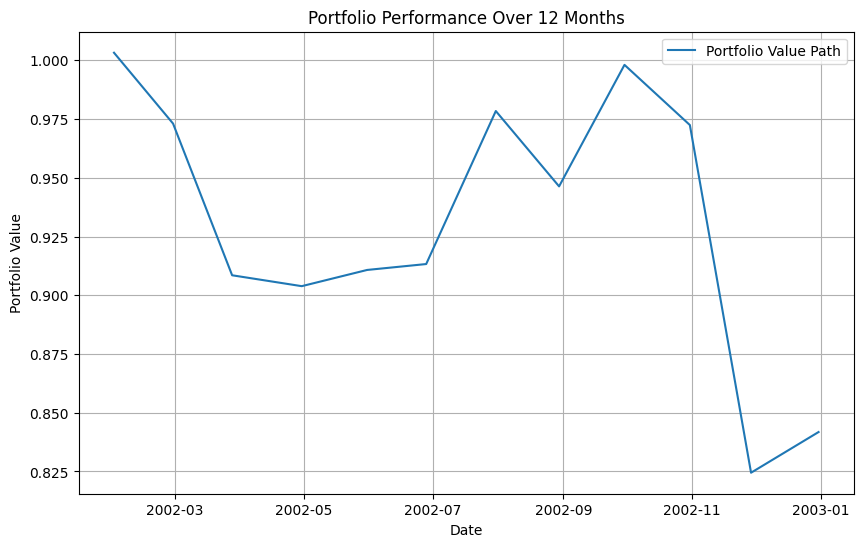


=== Segment 0 ===
Decision date (t0 in R_all_unwindowed): 2001-12-31T00:00:00.000000000
Eval window dates: ['2002-01-31T00:00:00.000000000' '2002-02-28T00:00:00.000000000'
 '2002-03-28T00:00:00.000000000' '2002-04-30T00:00:00.000000000'
 '2002-05-31T00:00:00.000000000' '2002-06-28T00:00:00.000000000'
 '2002-07-31T00:00:00.000000000' '2002-08-30T00:00:00.000000000'
 '2002-09-30T00:00:00.000000000' '2002-10-31T00:00:00.000000000'
 '2002-11-29T00:00:00.000000000' '2002-12-31T00:00:00.000000000']
Portfolio 12-month Return: -0.15824575697017484
Volatility: 0.23286428
Sharpe Ratio: -0.6795621895185134

=== Segment (2002 → 2003) ===
Decision date: 2002-12-31T00:00:00.000000000
Eval window dates: ['2003-01-31T00:00:00.000000000' '2003-02-28T00:00:00.000000000'
 '2003-03-31T00:00:00.000000000' '2003-04-30T00:00:00.000000000'
 '2003-05-30T00:00:00.000000000' '2003-06-30T00:00:00.000000000'
 '2003-07-31T00:00:00.000000000' '2003-08-29T00:00:00.000000000'
 '2003-09-30T00:00:00.000000000' '2003-10

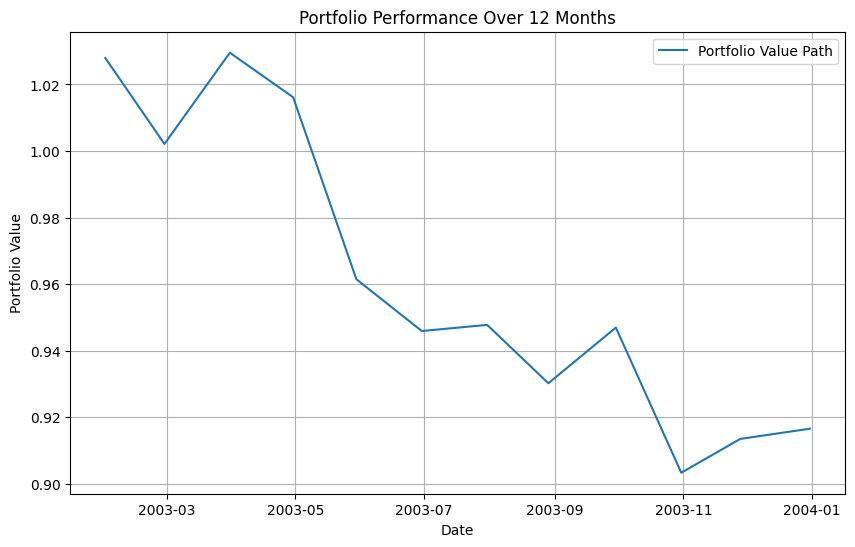


=== Segment 1 ===
Decision date (t0 in R_all_unwindowed): 2002-12-31T00:00:00.000000000
Eval window dates: ['2003-01-31T00:00:00.000000000' '2003-02-28T00:00:00.000000000'
 '2003-03-31T00:00:00.000000000' '2003-04-30T00:00:00.000000000'
 '2003-05-30T00:00:00.000000000' '2003-06-30T00:00:00.000000000'
 '2003-07-31T00:00:00.000000000' '2003-08-29T00:00:00.000000000'
 '2003-09-30T00:00:00.000000000' '2003-10-31T00:00:00.000000000'
 '2003-11-28T00:00:00.000000000' '2003-12-31T00:00:00.000000000']
Portfolio 12-month Return: -0.08340543169576853
Volatility: 0.37657055
Sharpe Ratio: -0.22148686646544513

=== Segment (2003 → 2004) ===
Decision date: 2003-12-31T00:00:00.000000000
Eval window dates: ['2004-01-30T00:00:00.000000000' '2004-02-27T00:00:00.000000000'
 '2004-03-31T00:00:00.000000000' '2004-04-30T00:00:00.000000000'
 '2004-05-28T00:00:00.000000000' '2004-06-30T00:00:00.000000000'
 '2004-07-30T00:00:00.000000000' '2004-08-31T00:00:00.000000000'
 '2004-09-30T00:00:00.000000000' '2004-1

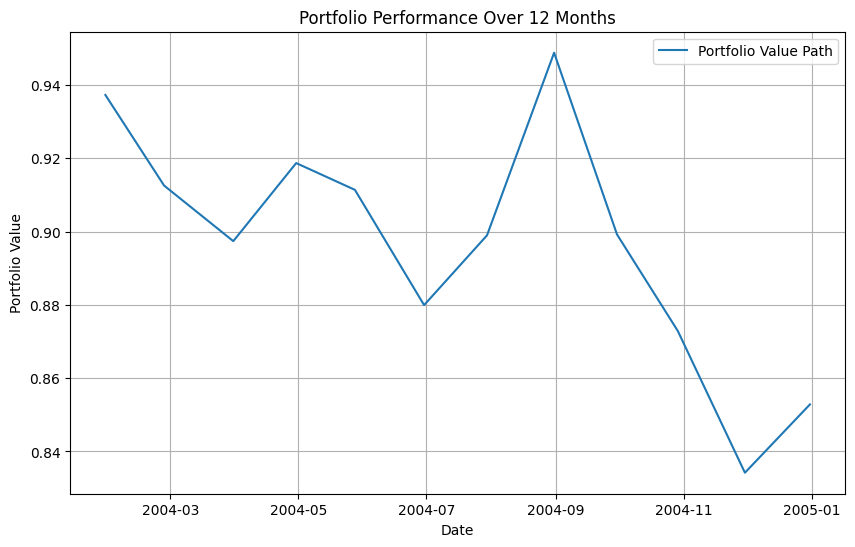


=== Segment 2 ===
Decision date (t0 in R_all_unwindowed): 2003-12-31T00:00:00.000000000
Eval window dates: ['2004-01-30T00:00:00.000000000' '2004-02-27T00:00:00.000000000'
 '2004-03-31T00:00:00.000000000' '2004-04-30T00:00:00.000000000'
 '2004-05-28T00:00:00.000000000' '2004-06-30T00:00:00.000000000'
 '2004-07-30T00:00:00.000000000' '2004-08-31T00:00:00.000000000'
 '2004-09-30T00:00:00.000000000' '2004-10-29T00:00:00.000000000'
 '2004-11-30T00:00:00.000000000' '2004-12-31T00:00:00.000000000']
Portfolio 12-month Return: -0.14718142782826316
Volatility: 0.19999516
Sharpe Ratio: -0.7359249481466327

=== Segment (2004 → 2005) ===
Decision date: 2004-12-31T00:00:00.000000000
Eval window dates: ['2005-01-31T00:00:00.000000000' '2005-02-28T00:00:00.000000000'
 '2005-03-31T00:00:00.000000000' '2005-04-29T00:00:00.000000000'
 '2005-05-31T00:00:00.000000000' '2005-06-30T00:00:00.000000000'
 '2005-07-29T00:00:00.000000000' '2005-08-31T00:00:00.000000000'
 '2005-09-30T00:00:00.000000000' '2005-10

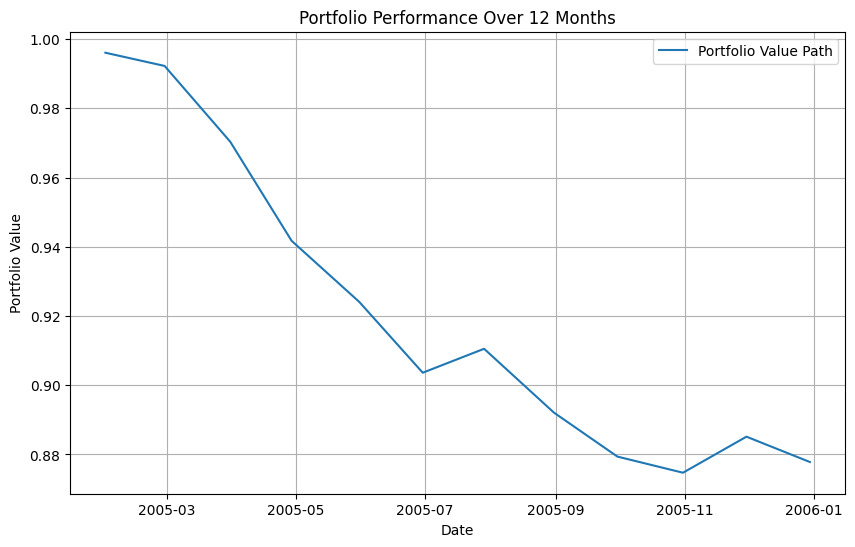


=== Segment 3 ===
Decision date (t0 in R_all_unwindowed): 2004-12-31T00:00:00.000000000
Eval window dates: ['2005-01-31T00:00:00.000000000' '2005-02-28T00:00:00.000000000'
 '2005-03-31T00:00:00.000000000' '2005-04-29T00:00:00.000000000'
 '2005-05-31T00:00:00.000000000' '2005-06-30T00:00:00.000000000'
 '2005-07-29T00:00:00.000000000' '2005-08-31T00:00:00.000000000'
 '2005-09-30T00:00:00.000000000' '2005-10-31T00:00:00.000000000'
 '2005-11-30T00:00:00.000000000' '2005-12-30T00:00:00.000000000']
Portfolio 12-month Return: -0.12219140326462752
Volatility: 0.22228731
Sharpe Ratio: -0.5497003049016654

=== Segment (2005 → 2006) ===
Decision date: 2005-12-30T00:00:00.000000000
Eval window dates: ['2006-01-31T00:00:00.000000000' '2006-02-28T00:00:00.000000000'
 '2006-03-31T00:00:00.000000000' '2006-04-28T00:00:00.000000000'
 '2006-05-31T00:00:00.000000000' '2006-06-30T00:00:00.000000000'
 '2006-07-31T00:00:00.000000000' '2006-08-31T00:00:00.000000000'
 '2006-09-29T00:00:00.000000000' '2006-10

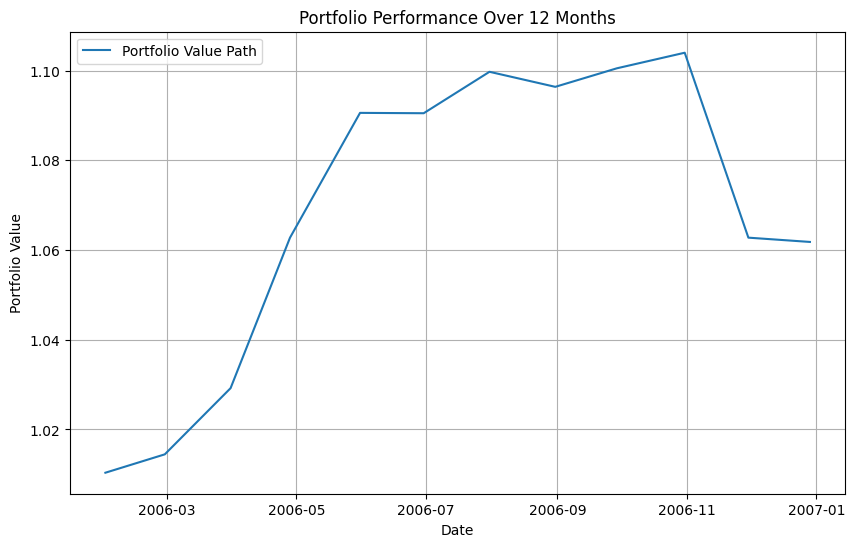


=== Segment 4 ===
Decision date (t0 in R_all_unwindowed): 2005-12-30T00:00:00.000000000
Eval window dates: ['2006-01-31T00:00:00.000000000' '2006-02-28T00:00:00.000000000'
 '2006-03-31T00:00:00.000000000' '2006-04-28T00:00:00.000000000'
 '2006-05-31T00:00:00.000000000' '2006-06-30T00:00:00.000000000'
 '2006-07-31T00:00:00.000000000' '2006-08-31T00:00:00.000000000'
 '2006-09-29T00:00:00.000000000' '2006-10-31T00:00:00.000000000'
 '2006-11-30T00:00:00.000000000' '2006-12-29T00:00:00.000000000']
Portfolio 12-month Return: 0.06180264847784245
Volatility: 0.1673041
Sharpe Ratio: 0.36940307495602226

=== Segment (2006 → 2007) ===
Decision date: 2006-12-29T00:00:00.000000000
Eval window dates: ['2007-01-31T00:00:00.000000000' '2007-02-28T00:00:00.000000000'
 '2007-03-30T00:00:00.000000000' '2007-04-30T00:00:00.000000000'
 '2007-05-31T00:00:00.000000000' '2007-06-29T00:00:00.000000000'
 '2007-07-31T00:00:00.000000000' '2007-08-31T00:00:00.000000000'
 '2007-09-28T00:00:00.000000000' '2007-10-3

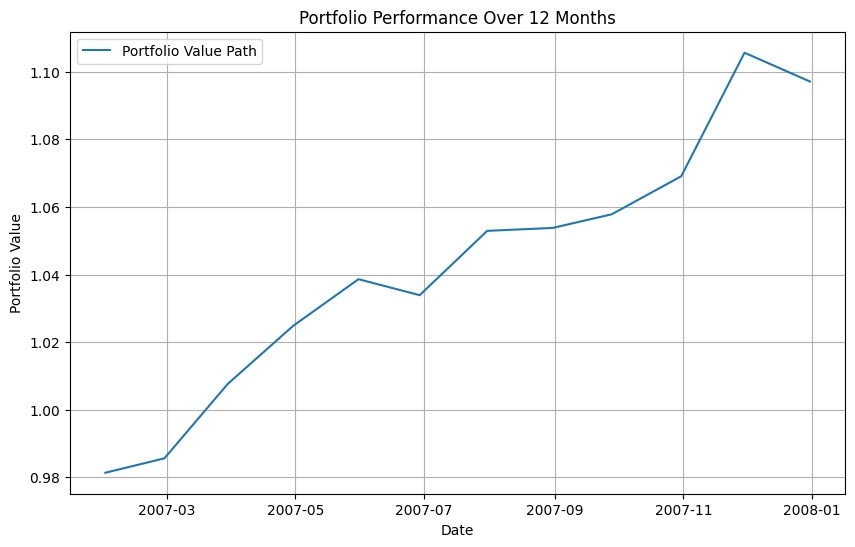


=== Segment 5 ===
Decision date (t0 in R_all_unwindowed): 2006-12-29T00:00:00.000000000
Eval window dates: ['2007-01-31T00:00:00.000000000' '2007-02-28T00:00:00.000000000'
 '2007-03-30T00:00:00.000000000' '2007-04-30T00:00:00.000000000'
 '2007-05-31T00:00:00.000000000' '2007-06-29T00:00:00.000000000'
 '2007-07-31T00:00:00.000000000' '2007-08-31T00:00:00.000000000'
 '2007-09-28T00:00:00.000000000' '2007-10-31T00:00:00.000000000'
 '2007-11-30T00:00:00.000000000' '2007-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.09711935564572793
Volatility: 0.25399148
Sharpe Ratio: 0.3823724869461914

=== Segment (2007 → 2008) ===
Decision date: 2007-12-31T00:00:00.000000000
Eval window dates: ['2008-01-31T00:00:00.000000000' '2008-02-29T00:00:00.000000000'
 '2008-03-31T00:00:00.000000000' '2008-04-30T00:00:00.000000000'
 '2008-05-30T00:00:00.000000000' '2008-06-30T00:00:00.000000000'
 '2008-07-31T00:00:00.000000000' '2008-08-29T00:00:00.000000000'
 '2008-09-30T00:00:00.000000000' '2008-10-3

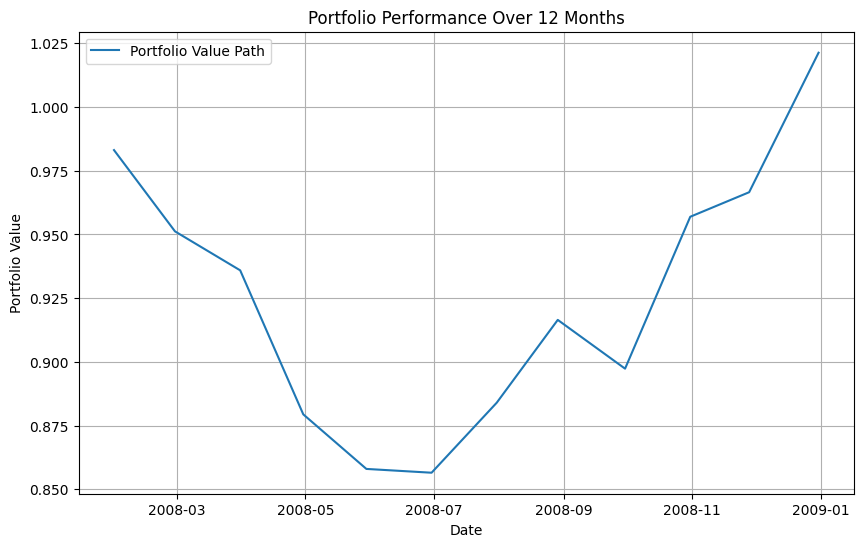


=== Segment 6 ===
Decision date (t0 in R_all_unwindowed): 2007-12-31T00:00:00.000000000
Eval window dates: ['2008-01-31T00:00:00.000000000' '2008-02-29T00:00:00.000000000'
 '2008-03-31T00:00:00.000000000' '2008-04-30T00:00:00.000000000'
 '2008-05-30T00:00:00.000000000' '2008-06-30T00:00:00.000000000'
 '2008-07-31T00:00:00.000000000' '2008-08-29T00:00:00.000000000'
 '2008-09-30T00:00:00.000000000' '2008-10-31T00:00:00.000000000'
 '2008-11-28T00:00:00.000000000' '2008-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.021290092291686324
Volatility: 0.18659565
Sharpe Ratio: 0.11409747472535033

=== Segment (2008 → 2009) ===
Decision date: 2008-12-31T00:00:00.000000000
Eval window dates: ['2009-01-30T00:00:00.000000000' '2009-02-27T00:00:00.000000000'
 '2009-03-31T00:00:00.000000000' '2009-04-30T00:00:00.000000000'
 '2009-05-29T00:00:00.000000000' '2009-06-30T00:00:00.000000000'
 '2009-07-31T00:00:00.000000000' '2009-08-31T00:00:00.000000000'
 '2009-09-30T00:00:00.000000000' '2009-10

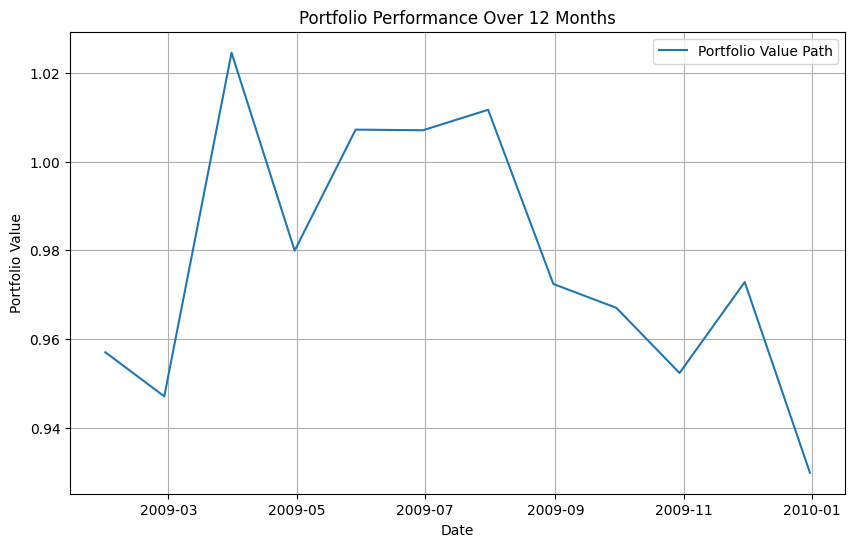


=== Segment 7 ===
Decision date (t0 in R_all_unwindowed): 2008-12-31T00:00:00.000000000
Eval window dates: ['2009-01-30T00:00:00.000000000' '2009-02-27T00:00:00.000000000'
 '2009-03-31T00:00:00.000000000' '2009-04-30T00:00:00.000000000'
 '2009-05-29T00:00:00.000000000' '2009-06-30T00:00:00.000000000'
 '2009-07-31T00:00:00.000000000' '2009-08-31T00:00:00.000000000'
 '2009-09-30T00:00:00.000000000' '2009-10-30T00:00:00.000000000'
 '2009-11-30T00:00:00.000000000' '2009-12-31T00:00:00.000000000']
Portfolio 12-month Return: -0.07020203130143399
Volatility: 0.5058544
Sharpe Ratio: -0.1387791179465168

=== Segment (2009 → 2010) ===
Decision date: 2009-12-31T00:00:00.000000000
Eval window dates: ['2010-01-29T00:00:00.000000000' '2010-02-26T00:00:00.000000000'
 '2010-03-31T00:00:00.000000000' '2010-04-30T00:00:00.000000000'
 '2010-05-28T00:00:00.000000000' '2010-06-30T00:00:00.000000000'
 '2010-07-30T00:00:00.000000000' '2010-08-31T00:00:00.000000000'
 '2010-09-30T00:00:00.000000000' '2010-10-

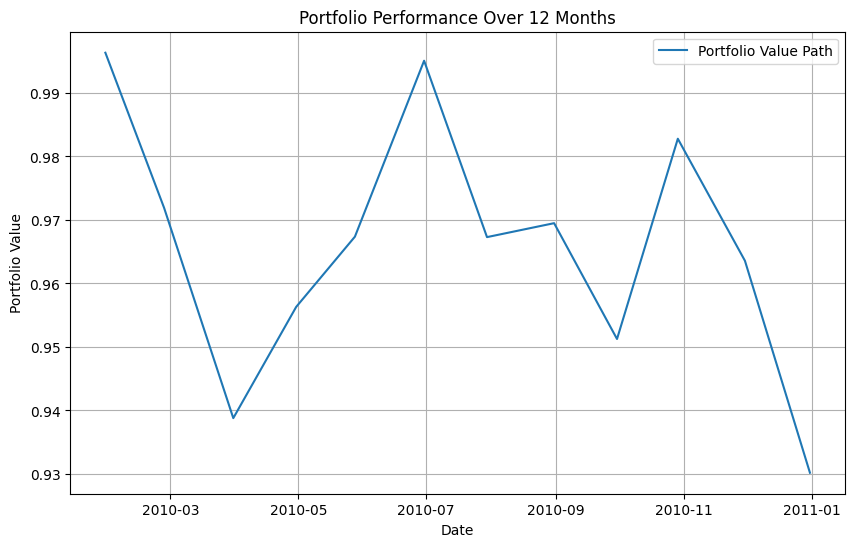


=== Segment 8 ===
Decision date (t0 in R_all_unwindowed): 2009-12-31T00:00:00.000000000
Eval window dates: ['2010-01-29T00:00:00.000000000' '2010-02-26T00:00:00.000000000'
 '2010-03-31T00:00:00.000000000' '2010-04-30T00:00:00.000000000'
 '2010-05-28T00:00:00.000000000' '2010-06-30T00:00:00.000000000'
 '2010-07-30T00:00:00.000000000' '2010-08-31T00:00:00.000000000'
 '2010-09-30T00:00:00.000000000' '2010-10-29T00:00:00.000000000'
 '2010-11-30T00:00:00.000000000' '2010-12-31T00:00:00.000000000']
Portfolio 12-month Return: -0.0698032174840223
Volatility: 0.18937987
Sharpe Ratio: -0.36858836768342684

=== Segment (2010 → 2011) ===
Decision date: 2010-12-31T00:00:00.000000000
Eval window dates: ['2011-01-31T00:00:00.000000000' '2011-02-28T00:00:00.000000000'
 '2011-03-31T00:00:00.000000000' '2011-04-29T00:00:00.000000000'
 '2011-05-31T00:00:00.000000000' '2011-06-30T00:00:00.000000000'
 '2011-07-29T00:00:00.000000000' '2011-08-31T00:00:00.000000000'
 '2011-09-30T00:00:00.000000000' '2011-10

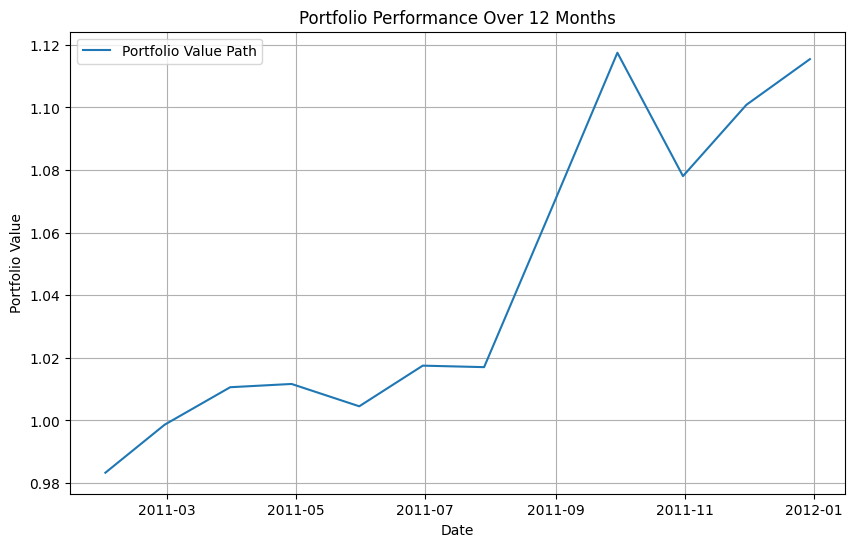


=== Segment 9 ===
Decision date (t0 in R_all_unwindowed): 2010-12-31T00:00:00.000000000
Eval window dates: ['2011-01-31T00:00:00.000000000' '2011-02-28T00:00:00.000000000'
 '2011-03-31T00:00:00.000000000' '2011-04-29T00:00:00.000000000'
 '2011-05-31T00:00:00.000000000' '2011-06-30T00:00:00.000000000'
 '2011-07-29T00:00:00.000000000' '2011-08-31T00:00:00.000000000'
 '2011-09-30T00:00:00.000000000' '2011-10-31T00:00:00.000000000'
 '2011-11-30T00:00:00.000000000' '2011-12-30T00:00:00.000000000']
Portfolio 12-month Return: 0.1154364534369221
Volatility: 0.18786481
Sharpe Ratio: 0.6144655473082493

=== Segment (2011 → 2012) ===
Decision date: 2011-12-30T00:00:00.000000000
Eval window dates: ['2012-01-31T00:00:00.000000000' '2012-02-29T00:00:00.000000000'
 '2012-03-30T00:00:00.000000000' '2012-04-30T00:00:00.000000000'
 '2012-05-31T00:00:00.000000000' '2012-06-29T00:00:00.000000000'
 '2012-07-31T00:00:00.000000000' '2012-08-31T00:00:00.000000000'
 '2012-09-28T00:00:00.000000000' '2012-10-31

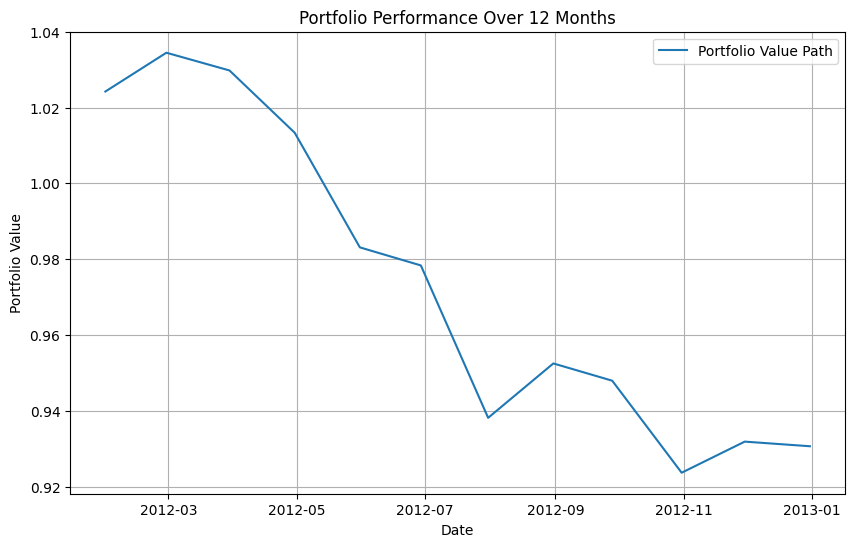


=== Segment 10 ===
Decision date (t0 in R_all_unwindowed): 2011-12-30T00:00:00.000000000
Eval window dates: ['2012-01-31T00:00:00.000000000' '2012-02-29T00:00:00.000000000'
 '2012-03-30T00:00:00.000000000' '2012-04-30T00:00:00.000000000'
 '2012-05-31T00:00:00.000000000' '2012-06-29T00:00:00.000000000'
 '2012-07-31T00:00:00.000000000' '2012-08-31T00:00:00.000000000'
 '2012-09-28T00:00:00.000000000' '2012-10-31T00:00:00.000000000'
 '2012-11-30T00:00:00.000000000' '2012-12-31T00:00:00.000000000']
Portfolio 12-month Return: -0.06934391943699836
Volatility: 0.14767428
Sharpe Ratio: -0.4695734466844065

=== Segment (2012 → 2013) ===
Decision date: 2012-12-31T00:00:00.000000000
Eval window dates: ['2013-01-31T00:00:00.000000000' '2013-02-28T00:00:00.000000000'
 '2013-03-28T00:00:00.000000000' '2013-04-30T00:00:00.000000000'
 '2013-05-31T00:00:00.000000000' '2013-06-28T00:00:00.000000000'
 '2013-07-31T00:00:00.000000000' '2013-08-30T00:00:00.000000000'
 '2013-09-30T00:00:00.000000000' '2013-1

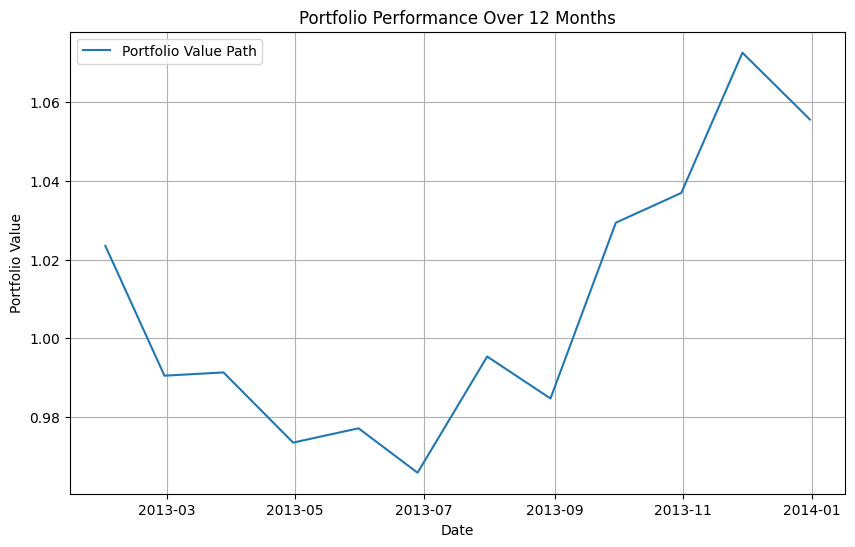


=== Segment 11 ===
Decision date (t0 in R_all_unwindowed): 2012-12-31T00:00:00.000000000
Eval window dates: ['2013-01-31T00:00:00.000000000' '2013-02-28T00:00:00.000000000'
 '2013-03-28T00:00:00.000000000' '2013-04-30T00:00:00.000000000'
 '2013-05-31T00:00:00.000000000' '2013-06-28T00:00:00.000000000'
 '2013-07-31T00:00:00.000000000' '2013-08-30T00:00:00.000000000'
 '2013-09-30T00:00:00.000000000' '2013-10-31T00:00:00.000000000'
 '2013-11-29T00:00:00.000000000' '2013-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.05562422054802263
Volatility: 0.21268132
Sharpe Ratio: 0.26153787125073663

=== Segment (2013 → 2014) ===
Decision date: 2013-12-31T00:00:00.000000000
Eval window dates: ['2014-01-31T00:00:00.000000000' '2014-02-28T00:00:00.000000000'
 '2014-03-31T00:00:00.000000000' '2014-04-30T00:00:00.000000000'
 '2014-05-30T00:00:00.000000000' '2014-06-30T00:00:00.000000000'
 '2014-07-31T00:00:00.000000000' '2014-08-29T00:00:00.000000000'
 '2014-09-30T00:00:00.000000000' '2014-10

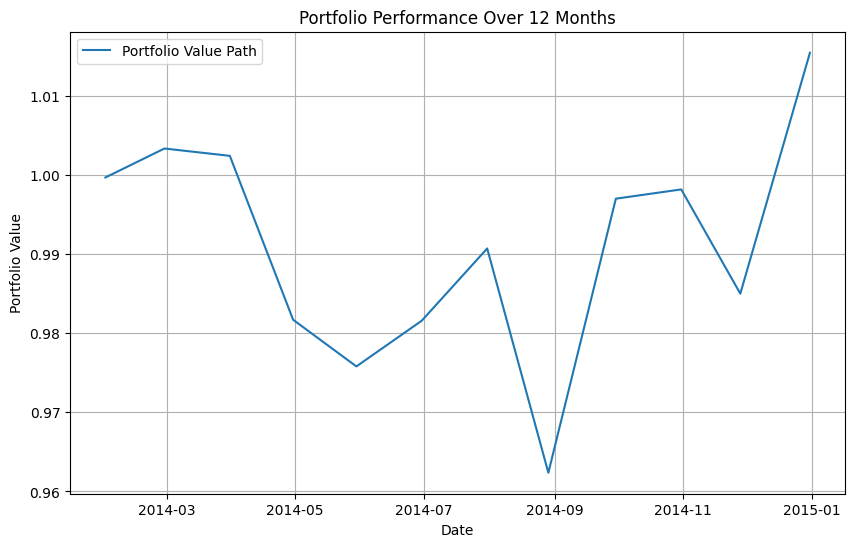


=== Segment 12 ===
Decision date (t0 in R_all_unwindowed): 2013-12-31T00:00:00.000000000
Eval window dates: ['2014-01-31T00:00:00.000000000' '2014-02-28T00:00:00.000000000'
 '2014-03-31T00:00:00.000000000' '2014-04-30T00:00:00.000000000'
 '2014-05-30T00:00:00.000000000' '2014-06-30T00:00:00.000000000'
 '2014-07-31T00:00:00.000000000' '2014-08-29T00:00:00.000000000'
 '2014-09-30T00:00:00.000000000' '2014-10-31T00:00:00.000000000'
 '2014-11-28T00:00:00.000000000' '2014-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.015469722825659726
Volatility: 0.17999476
Sharpe Ratio: 0.08594540562512805

=== Segment (2014 → 2015) ===
Decision date: 2014-12-31T00:00:00.000000000
Eval window dates: ['2015-01-30T00:00:00.000000000' '2015-02-27T00:00:00.000000000'
 '2015-03-31T00:00:00.000000000' '2015-04-30T00:00:00.000000000'
 '2015-05-29T00:00:00.000000000' '2015-06-30T00:00:00.000000000'
 '2015-07-31T00:00:00.000000000' '2015-08-31T00:00:00.000000000'
 '2015-09-30T00:00:00.000000000' '2015-1

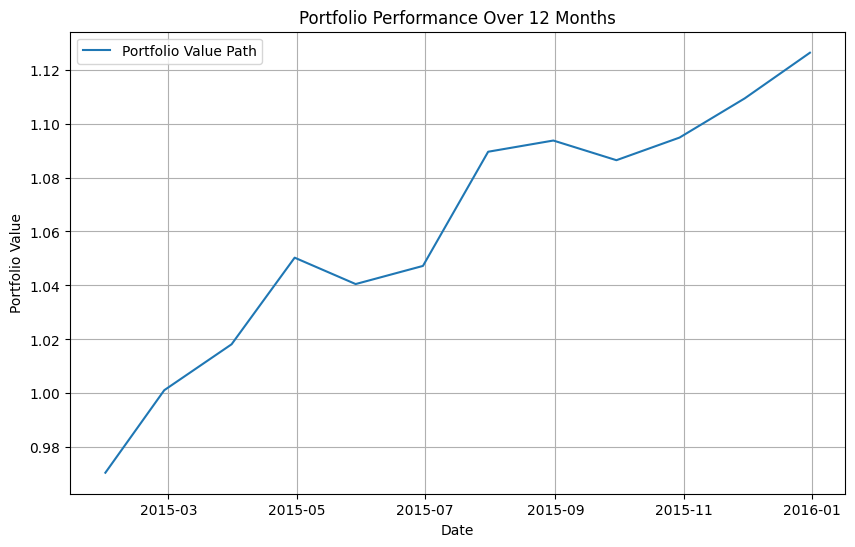


=== Segment 13 ===
Decision date (t0 in R_all_unwindowed): 2014-12-31T00:00:00.000000000
Eval window dates: ['2015-01-30T00:00:00.000000000' '2015-02-27T00:00:00.000000000'
 '2015-03-31T00:00:00.000000000' '2015-04-30T00:00:00.000000000'
 '2015-05-29T00:00:00.000000000' '2015-06-30T00:00:00.000000000'
 '2015-07-31T00:00:00.000000000' '2015-08-31T00:00:00.000000000'
 '2015-09-30T00:00:00.000000000' '2015-10-30T00:00:00.000000000'
 '2015-11-30T00:00:00.000000000' '2015-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.12626227463694928
Volatility: 0.16332811
Sharpe Ratio: 0.7730590510790742

=== Segment (2015 → 2016) ===
Decision date: 2015-12-31T00:00:00.000000000
Eval window dates: ['2016-01-29T00:00:00.000000000' '2016-02-29T00:00:00.000000000'
 '2016-03-31T00:00:00.000000000' '2016-04-29T00:00:00.000000000'
 '2016-05-31T00:00:00.000000000' '2016-06-30T00:00:00.000000000'
 '2016-07-29T00:00:00.000000000' '2016-08-31T00:00:00.000000000'
 '2016-09-30T00:00:00.000000000' '2016-10-

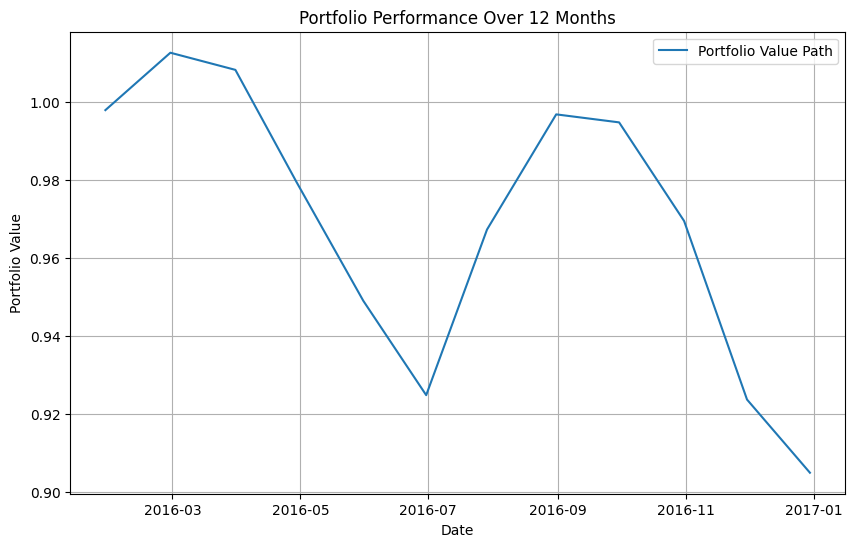


=== Segment 14 ===
Decision date (t0 in R_all_unwindowed): 2015-12-31T00:00:00.000000000
Eval window dates: ['2016-01-29T00:00:00.000000000' '2016-02-29T00:00:00.000000000'
 '2016-03-31T00:00:00.000000000' '2016-04-29T00:00:00.000000000'
 '2016-05-31T00:00:00.000000000' '2016-06-30T00:00:00.000000000'
 '2016-07-29T00:00:00.000000000' '2016-08-31T00:00:00.000000000'
 '2016-09-30T00:00:00.000000000' '2016-10-31T00:00:00.000000000'
 '2016-11-30T00:00:00.000000000' '2016-12-30T00:00:00.000000000']
Portfolio 12-month Return: -0.09514802681036394
Volatility: 0.22167295
Sharpe Ratio: -0.42922704766970826

=== Segment (2016 → 2017) ===
Decision date: 2016-12-30T00:00:00.000000000
Eval window dates: ['2017-01-31T00:00:00.000000000' '2017-02-28T00:00:00.000000000'
 '2017-03-31T00:00:00.000000000' '2017-04-28T00:00:00.000000000'
 '2017-05-31T00:00:00.000000000' '2017-06-30T00:00:00.000000000'
 '2017-07-31T00:00:00.000000000' '2017-08-31T00:00:00.000000000'
 '2017-09-29T00:00:00.000000000' '2017-

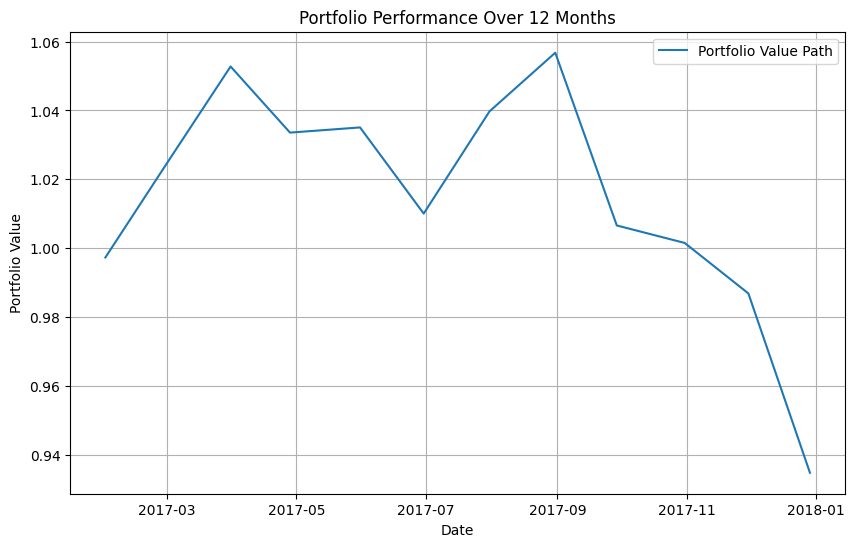


=== Segment 15 ===
Decision date (t0 in R_all_unwindowed): 2016-12-30T00:00:00.000000000
Eval window dates: ['2017-01-31T00:00:00.000000000' '2017-02-28T00:00:00.000000000'
 '2017-03-31T00:00:00.000000000' '2017-04-28T00:00:00.000000000'
 '2017-05-31T00:00:00.000000000' '2017-06-30T00:00:00.000000000'
 '2017-07-31T00:00:00.000000000' '2017-08-31T00:00:00.000000000'
 '2017-09-29T00:00:00.000000000' '2017-10-31T00:00:00.000000000'
 '2017-11-30T00:00:00.000000000' '2017-12-29T00:00:00.000000000']
Portfolio 12-month Return: -0.06525405449892008
Volatility: 0.25182256
Sharpe Ratio: -0.2591271180515131

=== Segment (2017 → 2018) ===
Decision date: 2017-12-29T00:00:00.000000000
Eval window dates: ['2018-01-31T00:00:00.000000000' '2018-02-28T00:00:00.000000000'
 '2018-03-29T00:00:00.000000000' '2018-04-30T00:00:00.000000000'
 '2018-05-31T00:00:00.000000000' '2018-06-29T00:00:00.000000000'
 '2018-07-31T00:00:00.000000000' '2018-08-31T00:00:00.000000000'
 '2018-09-28T00:00:00.000000000' '2018-1

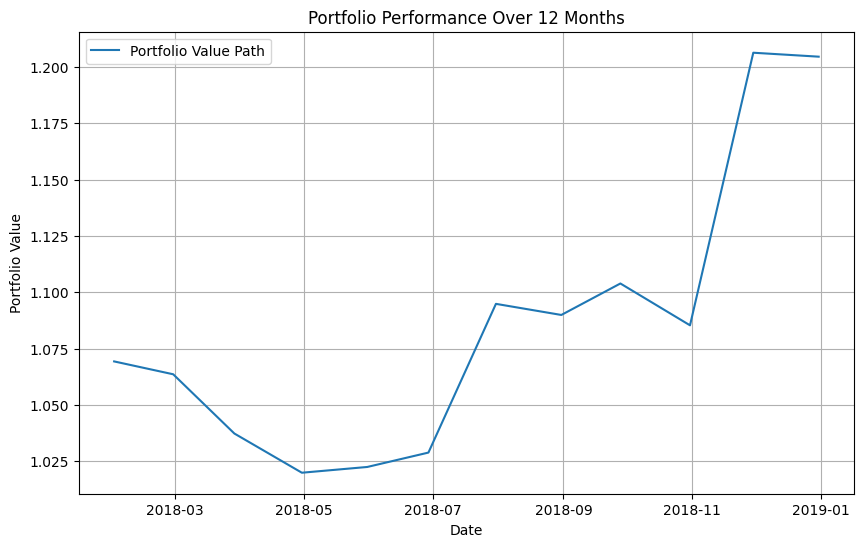


=== Segment 16 ===
Decision date (t0 in R_all_unwindowed): 2017-12-29T00:00:00.000000000
Eval window dates: ['2018-01-31T00:00:00.000000000' '2018-02-28T00:00:00.000000000'
 '2018-03-29T00:00:00.000000000' '2018-04-30T00:00:00.000000000'
 '2018-05-31T00:00:00.000000000' '2018-06-29T00:00:00.000000000'
 '2018-07-31T00:00:00.000000000' '2018-08-31T00:00:00.000000000'
 '2018-09-28T00:00:00.000000000' '2018-10-31T00:00:00.000000000'
 '2018-11-30T00:00:00.000000000' '2018-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.20460712815438198
Volatility: 0.21077295
Sharpe Ratio: 0.9707466331632412

=== Segment (2018 → 2019) ===
Decision date: 2018-12-31T00:00:00.000000000
Eval window dates: ['2019-01-31T00:00:00.000000000' '2019-02-28T00:00:00.000000000'
 '2019-03-29T00:00:00.000000000' '2019-04-30T00:00:00.000000000'
 '2019-05-31T00:00:00.000000000' '2019-06-28T00:00:00.000000000'
 '2019-07-31T00:00:00.000000000' '2019-08-30T00:00:00.000000000'
 '2019-09-30T00:00:00.000000000' '2019-10-

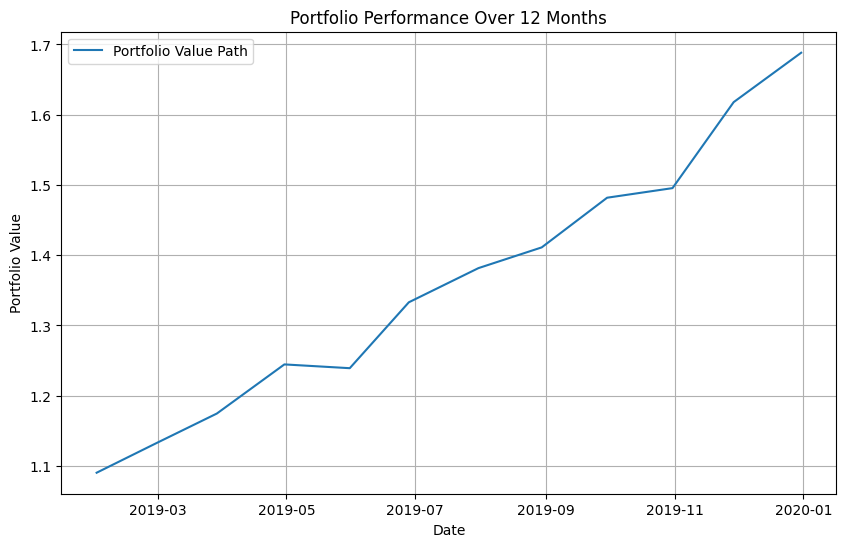


=== Segment 17 ===
Decision date (t0 in R_all_unwindowed): 2018-12-31T00:00:00.000000000
Eval window dates: ['2019-01-31T00:00:00.000000000' '2019-02-28T00:00:00.000000000'
 '2019-03-29T00:00:00.000000000' '2019-04-30T00:00:00.000000000'
 '2019-05-31T00:00:00.000000000' '2019-06-28T00:00:00.000000000'
 '2019-07-31T00:00:00.000000000' '2019-08-30T00:00:00.000000000'
 '2019-09-30T00:00:00.000000000' '2019-10-31T00:00:00.000000000'
 '2019-11-29T00:00:00.000000000' '2019-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.6882469156782047
Volatility: 0.28777638
Sharpe Ratio: 2.391603208779923

=== Segment (2019 → 2020) ===
Decision date: 2019-12-31T00:00:00.000000000
Eval window dates: ['2020-01-31T00:00:00.000000000' '2020-02-28T00:00:00.000000000'
 '2020-03-31T00:00:00.000000000' '2020-04-30T00:00:00.000000000'
 '2020-05-29T00:00:00.000000000' '2020-06-30T00:00:00.000000000'
 '2020-07-31T00:00:00.000000000' '2020-08-31T00:00:00.000000000'
 '2020-09-30T00:00:00.000000000' '2020-10-30

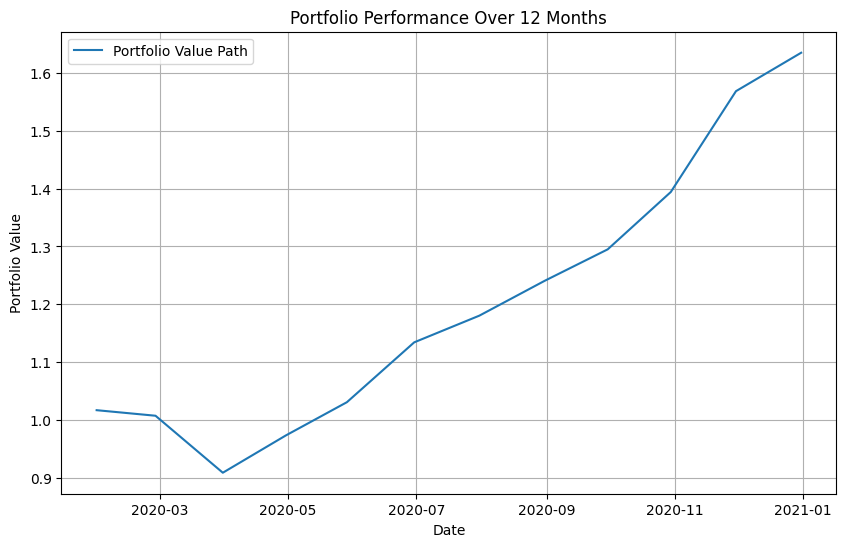


=== Segment 18 ===
Decision date (t0 in R_all_unwindowed): 2019-12-31T00:00:00.000000000
Eval window dates: ['2020-01-31T00:00:00.000000000' '2020-02-28T00:00:00.000000000'
 '2020-03-31T00:00:00.000000000' '2020-04-30T00:00:00.000000000'
 '2020-05-29T00:00:00.000000000' '2020-06-30T00:00:00.000000000'
 '2020-07-31T00:00:00.000000000' '2020-08-31T00:00:00.000000000'
 '2020-09-30T00:00:00.000000000' '2020-10-30T00:00:00.000000000'
 '2020-11-30T00:00:00.000000000' '2020-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.6354786135131636
Volatility: 0.25564522
Sharpe Ratio: 2.485783323744698

=== Segment (2020 → 2021) ===
Decision date: 2020-12-31T00:00:00.000000000
Eval window dates: ['2021-01-29T00:00:00.000000000' '2021-02-26T00:00:00.000000000'
 '2021-03-31T00:00:00.000000000' '2021-04-30T00:00:00.000000000'
 '2021-05-28T00:00:00.000000000' '2021-06-30T00:00:00.000000000'
 '2021-07-30T00:00:00.000000000' '2021-08-31T00:00:00.000000000'
 '2021-09-30T00:00:00.000000000' '2021-10-29

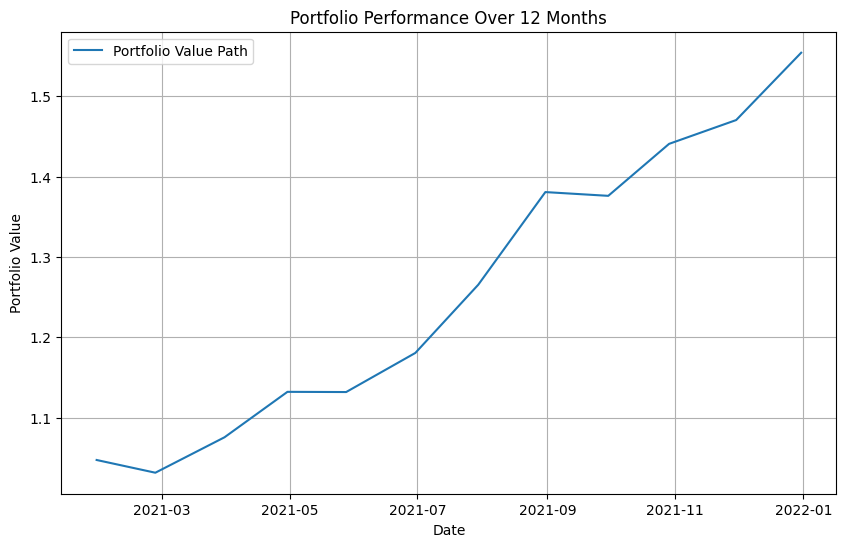


=== Segment 19 ===
Decision date (t0 in R_all_unwindowed): 2020-12-31T00:00:00.000000000
Eval window dates: ['2021-01-29T00:00:00.000000000' '2021-02-26T00:00:00.000000000'
 '2021-03-31T00:00:00.000000000' '2021-04-30T00:00:00.000000000'
 '2021-05-28T00:00:00.000000000' '2021-06-30T00:00:00.000000000'
 '2021-07-30T00:00:00.000000000' '2021-08-31T00:00:00.000000000'
 '2021-09-30T00:00:00.000000000' '2021-10-29T00:00:00.000000000'
 '2021-11-30T00:00:00.000000000' '2021-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.5541681714469187
Volatility: 0.32231802
Sharpe Ratio: 1.7193211095515748

=== Segment (2021 → 2022) ===
Decision date: 2021-12-31T00:00:00.000000000
Eval window dates: ['2022-01-31T00:00:00.000000000' '2022-02-28T00:00:00.000000000'
 '2022-03-31T00:00:00.000000000' '2022-04-29T00:00:00.000000000'
 '2022-05-31T00:00:00.000000000' '2022-06-30T00:00:00.000000000'
 '2022-07-29T00:00:00.000000000' '2022-08-31T00:00:00.000000000'
 '2022-09-30T00:00:00.000000000' '2022-10-3

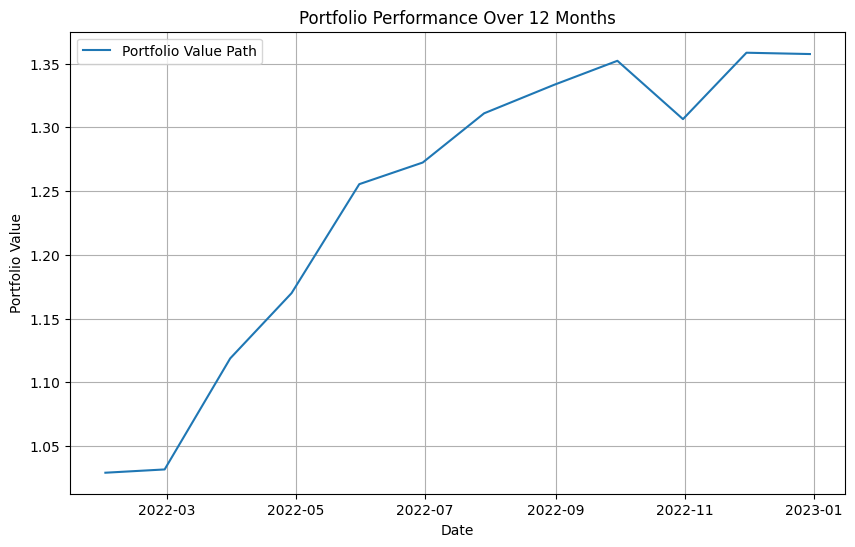


=== Segment 20 ===
Decision date (t0 in R_all_unwindowed): 2021-12-31T00:00:00.000000000
Eval window dates: ['2022-01-31T00:00:00.000000000' '2022-02-28T00:00:00.000000000'
 '2022-03-31T00:00:00.000000000' '2022-04-29T00:00:00.000000000'
 '2022-05-31T00:00:00.000000000' '2022-06-30T00:00:00.000000000'
 '2022-07-29T00:00:00.000000000' '2022-08-31T00:00:00.000000000'
 '2022-09-30T00:00:00.000000000' '2022-10-31T00:00:00.000000000'
 '2022-11-30T00:00:00.000000000' '2022-12-30T00:00:00.000000000']
Portfolio 12-month Return: 0.3574868834188165
Volatility: 0.32569954
Sharpe Ratio: 1.0975971461988174

=== Segment (2022 → 2023) ===
Decision date: 2022-12-30T00:00:00.000000000
Eval window dates: ['2023-01-31T00:00:00.000000000' '2023-02-28T00:00:00.000000000'
 '2023-03-31T00:00:00.000000000' '2023-04-28T00:00:00.000000000'
 '2023-05-31T00:00:00.000000000' '2023-06-30T00:00:00.000000000'
 '2023-07-31T00:00:00.000000000' '2023-08-31T00:00:00.000000000'
 '2023-09-29T00:00:00.000000000' '2023-10-3

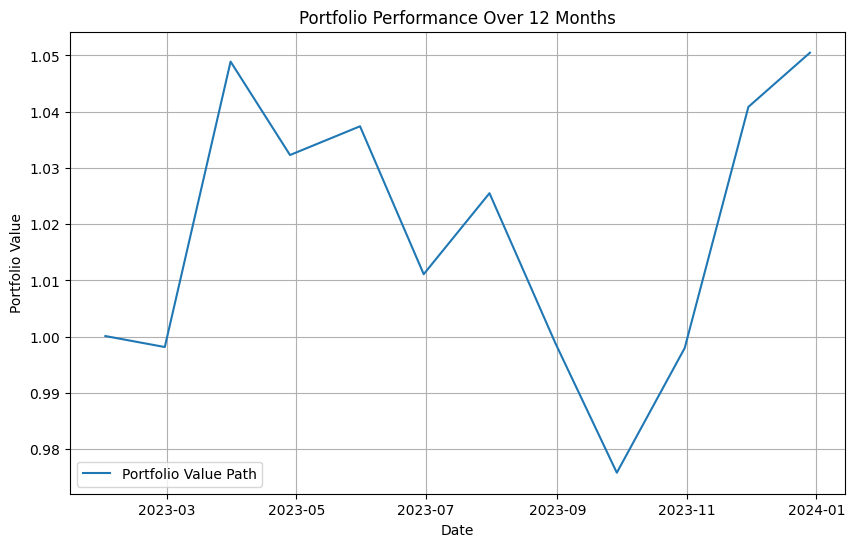


=== Segment 21 ===
Decision date (t0 in R_all_unwindowed): 2022-12-30T00:00:00.000000000
Eval window dates: ['2023-01-31T00:00:00.000000000' '2023-02-28T00:00:00.000000000'
 '2023-03-31T00:00:00.000000000' '2023-04-28T00:00:00.000000000'
 '2023-05-31T00:00:00.000000000' '2023-06-30T00:00:00.000000000'
 '2023-07-31T00:00:00.000000000' '2023-08-31T00:00:00.000000000'
 '2023-09-29T00:00:00.000000000' '2023-10-31T00:00:00.000000000'
 '2023-11-30T00:00:00.000000000' '2023-12-29T00:00:00.000000000']
Portfolio 12-month Return: 0.05048797511876324
Volatility: 0.21575274
Sharpe Ratio: 0.2340085049072694

=== Segment (2023 → 2024) ===
Decision date: 2023-12-29T00:00:00.000000000
Eval window dates: ['2024-01-31T00:00:00.000000000' '2024-02-29T00:00:00.000000000'
 '2024-03-28T00:00:00.000000000' '2024-04-30T00:00:00.000000000'
 '2024-05-31T00:00:00.000000000' '2024-06-28T00:00:00.000000000'
 '2024-07-31T00:00:00.000000000' '2024-08-30T00:00:00.000000000'
 '2024-09-30T00:00:00.000000000' '2024-10-

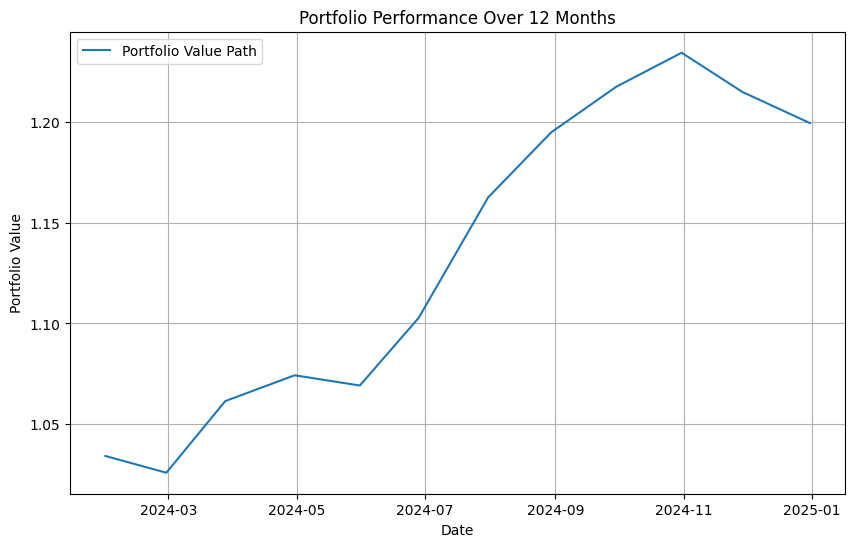


=== Segment 22 ===
Decision date (t0 in R_all_unwindowed): 2023-12-29T00:00:00.000000000
Eval window dates: ['2024-01-31T00:00:00.000000000' '2024-02-29T00:00:00.000000000'
 '2024-03-28T00:00:00.000000000' '2024-04-30T00:00:00.000000000'
 '2024-05-31T00:00:00.000000000' '2024-06-28T00:00:00.000000000'
 '2024-07-31T00:00:00.000000000' '2024-08-30T00:00:00.000000000'
 '2024-09-30T00:00:00.000000000' '2024-10-31T00:00:00.000000000'
 '2024-11-29T00:00:00.000000000' '2024-12-31T00:00:00.000000000']
Portfolio 12-month Return: 0.1996537719751621
Volatility: 0.2709093
Sharpe Ratio: 0.7369764163024743

--- Overall Results ---
Average Portfolio Return: 0.07753881853080058
Average Sharpe Ratio: 0.4195977767189777
Average Volatility: 0.23856790702927777


In [63]:
# Get data ready for running on the trained model
horizon = 12

test_results = []
test_all_portfolio_returns = []
test_all_portfolio_sharpe_ratios = []

# Re-initialize years for the full validation period for the loop
test_years = np.sort(pd.DatetimeIndex(dates_actual_test).year.unique())

# Loop over pairs of years
for i in range(0, len(test_years) - 1, 1):
    y_hist_test = test_years[i]
    y_eval_test = test_years[i + 1]

    # --- indices for these years on the global time axis ---
    years_all_test = pd.DatetimeIndex(dates_actual_test).year.values

    hist_mask_test = (years_all_test == y_hist_test)
    eval_mask_test = (years_all_test == y_eval_test)

    if hist_mask_test.sum() < window or eval_mask_test.sum() < horizon:
        print(f"Skipping pair ({y_hist_test}, {y_eval_test}) – not enough months")
        continue

    # index of last month of history year (decision time)
    t0_test = np.where(hist_mask_test)[0][-1]   # decision at end of Year y_hist

    # index of first month of eval year
    eval_start_idx_test = np.where(eval_mask_test)[0][0]

    # consistency check: eval starts right after history ends (or close)
    if eval_start_idx_test != t0_test+ 1:
        print(f"Warning: eval_start_idx != t0+1 for ({y_hist_test}, {y_eval_test})") # Corrected warning message

    # --- choose the correct sequence window for the policy ---
    # X_val_seq[b] covers months [b, b+window-1]
    # We want the sequence whose last month is t0 → b = t0 - (window-1)
    seq_idx_full_test = t0_test - (window - 1)

     # To index into X_val_seq, we need a relative index
    seq_idx_relative_test = seq_idx_full_test # 'cut' is from the previous cell, separating X_val_seq_1 and X_val_seq_2
    if seq_idx_relative_test < 0 or seq_idx_relative_test >= X_test_seq.shape[0]:
        print(f"Skipping pair ({y_hist_test}, {y_eval_test}) – required sequence for evaluation is not in X_val_seq_2 (index {seq_idx_relative_test} out of range {X_test_seq.shape[0]}) ")
        continue

    X_seq_segment_test = X_test_seq[seq_idx_relative_test : seq_idx_relative_test + 1]   # [1, window, I, F]
    R_seq_segment_test = R_test_seq[seq_idx_relative_test : seq_idx_relative_test + 1]


    # --- get long/short picks from the trained policy ---
    (
        long_companies_test, long_weights_test, long_indices_test,
        short_companies_test, short_weights_test, short_indices_test,
    ) = get_next_month_picks(
        loaded_trainer,
        X_seq_segment_test,
        R_seq_segment_test,
        companies_actual_test,   # full company list, indices align with R_all_unwindowed
        num_assets=10,
    )


    # --- buy and hold for the *next year* (y_eval) ---
    asset_ret_12m_test, value_path_test, port_12m_test, w_full_test = buy_and_hold_long_short(
        R_all_unwindowed_test, # Corrected: Use R_all_unwindowed_test
        t0=t0_test,                           # decision at end of history year
        long_indices=long_indices_test,
        long_weights=long_weights_test,
        short_indices=short_indices_test,
        short_weights=short_weights_test,
        horizon=horizon,
    )

    # Sharpe etc.
    # Using asset_ret_12m from validation data (bug). Should be asset_ret_12m_test
    # Recalculate volatility and sharpe_ratio using test data's asset_ret_12m_test
    volatility_test = np.std(asset_ret_12m_test) # Corrected
    sharpe_ratio_test = port_12m_test / volatility_test if volatility_test > 0 else np.nan # Corrected

    print(f"\n=== Segment ({y_hist_test} → {y_eval_test}) ===")
    print("Decision date:", dates_actual_test[t0_test])
    # Corrected `t0` to `t0_test` for date indexing consistency
    print("Eval window dates:", dates_actual_test[t0_test+1 : t0_test+1+horizon])
    print("Portfolio 12m Return:", port_12m_test)
    print("Volatility:", volatility_test)
    print("Sharpe Ratio:", sharpe_ratio_test)

    fig, ax = plt.subplots(figsize=(10, 6))
    # Corrected x-axis for value_path_test
    ax.plot(dates_actual_test[t0_test+1 : t0_test+1+horizon], value_path_test, label='Portfolio Value Path')
    ax.set_xlabel('Date')
    ax.set_ylabel('Portfolio Value')
    ax.set_title('Portfolio Performance Over 12 Months')
    ax.legend()
    plt.grid(True)
    plt.show()

    test_results.append({
        "hist_year": int(y_hist_test),
        "eval_year": int(y_eval_test),
        "port_12m": float(port_12m_test),
        "vol": float(volatility_test),
        "sharpe": float(sharpe_ratio_test),
    })



    print(f"\n=== Segment {i} ===")
    print("Decision date (t0 in R_all_unwindowed):", dates_actual_test[t0_test] if t0_test < len(dates_actual_test) else "N/A")
    # Corrected `t0` to `t0_test` for date indexing consistency
    print("Eval window dates:", dates_actual_test[t0_test+1 : t0_test+1+horizon])
    print("Portfolio 12-month Return:", port_12m_test)
    test_all_portfolio_returns.append(port_12m_test) # Append to test_all_portfolio_returns

    # Only compute volatility if asset_ret_12m_test is not scalar or None/nan
    if isinstance(asset_ret_12m_test, np.ndarray) and asset_ret_12m_test.size > 1 and not np.isnan(asset_ret_12m_test).all():
        volatility_test = np.std(asset_ret_12m_test)
        print("Volatility:", volatility_test) # Corrected
        sharpe_ratio_test = port_12m_test / volatility_test if volatility_test > 0 else np.nan
        print("Sharpe Ratio:", sharpe_ratio_test)
        test_all_portfolio_sharpe_ratios.append(sharpe_ratio_test)
    else:
        print("Volatility: N/A (insufficient asset returns)")
        print("Sharpe Ratio: N/A")
        test_all_portfolio_sharpe_ratios.append(np.nan)

# Print overall average results
print("\n--- Overall Results ---")
# Use test_all_portfolio_returns for calculations
print("Average Portfolio Return:", np.prod((1+np.array(test_all_portfolio_returns)) ** (1 / len(test_all_portfolio_returns))) - 1)
print("Average Sharpe Ratio:", np.nanmean(np.array(test_all_portfolio_returns))/ np.nanstd(np.array(test_all_portfolio_returns)))
print("Average Volatility:", np.nanstd(np.array(test_all_portfolio_returns)))

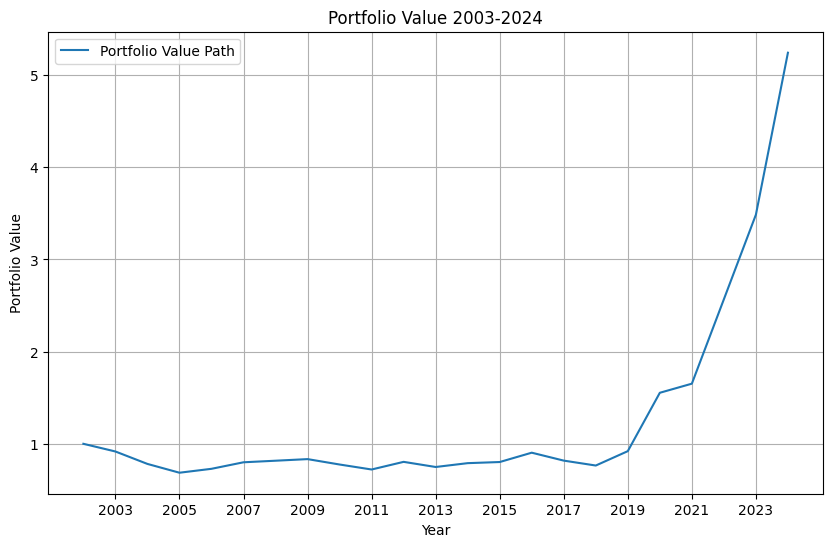

In [7]:
import matplotlib.pyplot as plt
import numpy as np

dates = [2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
annual_performance = [0, -0.0834, -0.1471, -0.1221, 0.0618, 0.09711, 0.02129, 0.02129, -0.0702, -0.0698, 0.115, -0.0693, 0.0556, 0.01546, 0.12626, -0.0951, -0.0652, 0.204, 0.688, 0.06354, 0.5541, 0.3574, 0.504]

# Calculate compounded performance: (1 + r1) * (1 + r2) ...
# We treat the first 0 as a starting point (wealth = 1.0)
compounded_performance = np.cumprod(1 + np.array(annual_performance))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dates, compounded_performance, label='Portfolio Value Path')

ax.set_xlabel('Year')
ax.set_ylabel('Portfolio Value')
ax.set_title('Portfolio Value 2003-2024')
plt.xticks(np.arange(2003, 2024, 2))
ax.legend()
plt.grid(True)
plt.show()

In [58]:
display("Long Companies:", long_companies_test)
display("Long Weights:", long_weights_test)
display("Short Companies:", short_companies_test)
display("Short Weights:", short_weights_test)

'Long Companies:'

array(['EXELON CORP', 'PG&E CORP', 'HERSHEY CO', 'HESS CORP',
       'FORD MOTOR CO', 'EQT CORP', 'BOEING CO',
       'INTL BUSINESS MACHINES CORP', '3M CO', 'BRISTOL-MYERS SQUIBB CO'],
      dtype=object)

'Long Weights:'

array([0.10000369, 0.10000174, 0.1000012 , 0.10000102, 0.09999986,
       0.09999947, 0.09999932, 0.099998  , 0.09999788, 0.09999779],
      dtype=float32)

'Short Companies:'

array(['AMERICAN ELECTRIC POWER CO', 'GENERAL DYNAMICS CORP',
       'ALTRIA GROUP INC', 'TEXAS INSTRUMENTS INC', 'S&P GLOBAL INC',
       'DEERE & CO', 'SLB LTD', 'XCEL ENERGY INC', 'WEC ENERGY GROUP INC',
       'SOUTHERN CO'], dtype=object)

'Short Weights:'

array([0.10000134, 0.1000009 , 0.10000066, 0.10000066, 0.1000004 ,
       0.10000003, 0.09999999, 0.09999997, 0.09999853, 0.09999754],
      dtype=float32)

In [64]:
import numpy as np
import pandas as pd

# 1. Initialize data collection list
january_picks_detailed = []

# 2. Parameters for iteration
test_years = np.sort(pd.DatetimeIndex(dates_actual_test).year.unique())
window = 12
horizon = 12

# 3. Loop through test years to generate picks and performance metrics
for i in range(0, len(test_years) - 1, 1):
    y_hist = test_years[i]
    years_all = pd.DatetimeIndex(dates_actual_test).year.values
    hist_mask = (years_all == y_hist)

    if hist_mask.sum() < window:
        continue

    # Decision point: end of the historical year
    t0 = np.where(hist_mask)[0][-1]
    decision_dt = dates_actual_test[t0]

    # Get the sequence for the model
    seq_idx = t0 - (window - 1)
    if seq_idx < 0 or seq_idx >= X_test_seq.shape[0]:
        continue

    # Generate Picks
    (long_comps, long_w, long_idx,
     short_comps, short_w, short_idx) = get_next_month_picks(
         loaded_trainer, X_test_seq[seq_idx:seq_idx+1], R_test_seq[seq_idx:seq_idx+1],
         companies_actual_test, num_assets=10
    )

    # Compute Portfolio Metrics for this specific period
    asset_ret, value_path, port_12m, w_full = buy_and_hold_long_short(
        R_all_unwindowed_test, t0=t0, long_indices=long_idx,
        long_weights=long_w, short_indices=short_idx,
        short_weights=short_w, horizon=horizon
    )

    v_ann = np.std(asset_ret)
    s_ann = port_12m / v_ann if v_ann > 0 else np.nan
    c_weight = 1.0 - np.sum(w_full) # Cash weight

    # Map company index to permno (using train_df as reference if possible)
    permno_map = train_df.groupby('company_name')['permno'].first().to_dict()

    # Process Long Picks
    for rank, (idx, weight) in enumerate(zip(long_idx, long_w), 1):
        comp_name = companies_actual_test[idx]
        january_picks_detailed.append({
            'decision_date': decision_dt,
            'rank': rank,
            'permno': permno_map.get(comp_name, 'N/A'),
            'company': comp_name,
            'type': 'Long',
            'weight': weight,
            'cash_weight': c_weight,
            'annual_return': port_12m,
            'ann_vol': v_ann,
            'ann_sharpe': s_ann
        })

    # Process Short Picks
    for rank, (idx, weight) in enumerate(zip(short_idx, short_w), 1):
        comp_name = companies_actual_test[idx]
        january_picks_detailed.append({
            'decision_date': decision_dt,
            'rank': rank,
            'permno': permno_map.get(comp_name, 'N/A'),
            'company': comp_name,
            'type': 'Short',
            'weight': -weight,
            'cash_weight': c_weight,
            'annual_return': port_12m,
            'ann_vol': v_ann,
            'ann_sharpe': s_ann
        })

# 4. Create and display the DataFrame
january_picks_df = pd.DataFrame(january_picks_detailed)
display(january_picks_df)

,decision_date,rank,permno,company,type,weight,cash_weight,annual_return,ann_vol,ann_sharpe
0,2001-12-31,1,20482,ABBOTT LABORATORIES,Long,0.100034,1.0,-0.158246,0.232864,-0.679562
1,2001-12-31,2,22592,3M CO,Long,0.100031,1.0,-0.158246,0.232864,-0.679562
2,2001-12-31,3,24109,AMERICAN ELECTRIC POWER CO,Long,0.100009,1.0,-0.158246,0.232864,-0.679562
3,2001-12-31,4,13901,ALTRIA GROUP INC,Long,0.100007,1.0,-0.158246,0.232864,-0.679562
4,2001-12-31,5,19393,BRISTOL-MYERS SQUIBB CO,Long,0.099994,1.0,-0.158246,0.232864,-0.679562
...,...,...,...,...,...,...,...,...,...,...
455,2023-12-29,6,24328,EQT CORP,Short,-0.100004,1.0,0.199654,0.270909,0.736976
456,2023-12-29,7,28484,HESS CORP,Short,-0.100001,1.0,0.199654,0.270909,0.736976
457,2023-12-29,8,13688,PG&E CORP,Short,-0.099997,1.0,0.199654,0.270909,0.736976
458,2023-12-29,9,24643,ALCOA INC,Short,-0.099989,1.0,0.199654,0.270909,0.736976
